# ST456 Deep Learning — Course Project
## Calibrated Probabilistic Forecasting with Multi-Scale Deep Learning Architectures

**Group project | LSE ST456, 2025–26**

---

This notebook is the single source of truth for all data collection, EDA, and modelling in the project. It is structured into four sections:

| Section | Content |
|---|---|
| **1. Setup & Data Collection** | Mount Drive, pull FRED series, build `master_df.csv` and `norm_params.json` |
| **2. Exploratory Data Analysis** | Regime statistics, distribution shift, cross-correlations, stationarity |
| **3. Models** | ARIMA baseline → Standard LSTM → MC Dropout → Ensemble → MS-GLSTM → ARIMA-LSTM Hybrid → Transformer |
| **4. Evaluation** | ECE, CRPS, reliability diagrams, ablation study |

---
## Section 1 — Setup & Data Collection

Mounts Google Drive, pulls seven macroeconomic series from the FRED API, aligns them to a common monthly index, constructs derived features, and persists `master_df.csv` and `norm_params.json` to Drive.

**Run this cell once.** The outputs are cached in `data/fred_raw.parquet` and `data/master_df.csv` — subsequent runs load from disk without hitting the API.

### Series pulled

| FRED Code | Series | Frequency | Role |
|---|---|---|---|
| `CPIAUCSL` | CPI (All Urban Consumers, SA) | Monthly | Primary target π |
| `UNRATE` | Unemployment Rate | Monthly | Output gap proxy x |
| `INDPRO` | Industrial Production Index | Monthly | Secondary real activity |
| `VIXCLS` | VIX Volatility Index | Daily → Monthly | Regime uncertainty signal |
| `T10Y2Y` | 10Y–2Y Treasury Yield Spread | Daily → Monthly | Financial conditions (IS curve) |
| `NROU` | CBO Natural Rate of Unemployment | Quarterly → Monthly | NAIRU for ugap construction |
| `GDPC1` | Real GDP | Quarterly → Monthly | HP-filtered gap (Model 4 Q-stream) |

### Derived features

- **`pi_mom`** — annualised MoM log return of CPI: $\pi_t = 12 \cdot \log(\text{CPI}_t / \text{CPI}_{t-1})$
- **`ugap_cf`** — unemployment gap: UNRATE − NROU (carry-forward)
- **`indpro_ld`** — log first-difference of INDPRO
- **`gdp_gap_cf`** — HP-filtered ($\lambda=1600$) GDP gap, carry-forward to monthly

### Normalisation
Parameters (mean, std) are fit on the **training window only** (2000–2017) to prevent leakage into validation and test sets.

In [ ]:
# Drive mount cell

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ==============================================================================
# Data Collection & Master DataFrame Construction
# ==============================================================================
try:
    import fredapi
except ImportError:
    from IPython import get_ipython
    get_ipython().run_line_magic("pip", "install -q fredapi")
    import fredapi

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from fredapi import Fred
from statsmodels.tsa.filters.hp_filter import hpfilter

warnings.filterwarnings("ignore")

# Configuration
PROJECT_DIR = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR    = PROJECT_DIR / "data"

try:
    from google.colab import drive  # type: ignore
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not PROJECT_DIR.exists():
        raise FileNotFoundError(
            f"Expected project directory not found: {PROJECT_DIR}\n"
            "Check the folder name (case-sensitive) and that Drive mounted."
        )
except ImportError:
    PROJECT_DIR = Path("./ST456_Project")
    DATA_DIR  = PROJECT_DIR / "data"
    print(f"Not in Colab — using local fallback: {PROJECT_DIR.resolve()}")

DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")

# API key is read lazily — only required if we actually need to hit the FRED
# API (i.e. no cached parquet). This means a teammate without their own key
# can still load the cached data and re-run downstream cells.
def get_fred_api_key() -> str:
    """Resolve FRED_API_KEY from Colab Secrets or environment.

    Tried in order: Colab userdata → os.environ. Raises with a clear
    pointer to setup instructions if neither yields a key.
    """
    key = None
    try:
        from google.colab import userdata  # type: ignore
        try:
            key = userdata.get("FRED_API_KEY")
        except Exception:
            # SecretNotFoundError or NotebookAccessError — secret isn't
            # configured for this user/notebook. Fall through to env var.
            pass
    except ImportError:
        pass
    if not key:
        key = os.environ.get("FRED_API_KEY")
    if not key:
        raise RuntimeError(
            "FRED_API_KEY not set. Get a free key from "
            "https://fred.stlouisfed.org/docs/api/api_key.html, then either:\n"
            "  • Colab: add it to Secrets (sidebar 🔑) as FRED_API_KEY and "
            "toggle 'Notebook access' ON for this notebook, or\n"
            "  • Local: `os.environ['FRED_API_KEY'] = '...'` before this cell."
        )
    return key

START_DATE = "2000-01-01"
END_DATE   = "2024-12-31"
TRAIN_END  = "2017-12-31"  # used for fitting normalisation parameters only

OUT_DIR = DATA_DIR
MASTER_CSV  = OUT_DIR / "master_df.csv"
NORM_JSON   = OUT_DIR / "norm_params.json"
RAW_PARQUET = OUT_DIR / "fred_raw.parquet"  # cached raw pulls; safe to delete

# Series catalogue
FRED_SERIES = {
    "CPIAUCSL": ("CPI (All Urban Consumers, SA)",   "M", "primary target (π)"),
    "UNRATE":   ("Unemployment Rate (%)",           "M", "output gap proxy (x)"),
    "INDPRO":   ("Industrial Production Index",     "M", "secondary real activity"),
    "VIXCLS":   ("VIX Volatility Index",            "D", "regime uncertainty signal"),
    "T10Y2Y":   ("10Y-2Y Treasury Yield Spread",    "D", "forward financial conditions"),
    "NROU":     ("Noncyclical Rate of Unemployment", "Q", "NAIRU for ugap construction"),
    "GDPC1":    ("Real GDP",                         "Q", "HP-gap (Model 4 Q-stream)"),
}

REGIME_SPANS = {
    "pre_covid":  ("2015-01-01", "2019-12-31"),
    "covid":      ("2020-01-01", "2021-12-31"),
    "post_covid": ("2022-01-01", "2024-12-31"),
}


# Helpers

def to_month_start(s: pd.Series) -> pd.Series:
    """Normalise any DatetimeIndex to month-start (YYYY-MM-01).

    FRED uses inconsistent timestamp conventions: monthly series anchor at
    month-start, daily at the observation date, quarterly at quarter-end.
    Normalising everything to YYYY-MM-01 before any join eliminates silent
    NaN columns from convention mismatches.
    """
    s = s.copy()
    s.index = s.index.to_period("M").to_timestamp()
    return s


def daily_to_monthly_mean(s: pd.Series) -> pd.Series:
    """Aggregate a daily series to monthly mean.

    Preferred over end-of-month last-value because the mean smooths intra-month
    noise (especially for VIX) while retaining the level information.
    """
    return s.resample("MS").mean()


def quarterly_to_monthly_cf(s: pd.Series) -> pd.Series:
    """Upsample a quarterly series to monthly via carry-forward.

    Conservative: no intra-quarter information is imputed. Each month within
    a quarter receives the value published for that quarter.
    """
    s = to_month_start(s)
    return s.reindex(pd.date_range(s.index.min(), END_DATE, freq="MS")).ffill()


def fetch_fred(fred: Fred, code: str) -> pd.Series:
    """Pull a single series, slice to project window, name it."""
    s = fred.get_series(code, observation_start=START_DATE, observation_end=END_DATE)
    s.name = code
    return s


def assert_no_silent_nans(df: pd.DataFrame, after: str) -> None:
    """Diagnostic check — fail loudly if a join introduced systematic NaNs.

    Designed to catch the frequency-alignment bug class that bit us repeatedly
    during development: a column that is entirely NaN because indices didn't
    line up after a merge.
    """
    fully_null = [c for c in df.columns if df[c].isna().all()]
    if fully_null:
        raise ValueError(f"After {after}: columns are entirely NaN: {fully_null}")
    mostly_null = {c: df[c].isna().mean() for c in df.columns
                   if df[c].isna().mean() > 0.5}
    if mostly_null:
        warnings.warn(f"After {after}: columns >50% NaN: {mostly_null}")


# Pull raw series from FRED

if RAW_PARQUET.exists():
    print(f"Loading cached raw pulls from {RAW_PARQUET.name} "
          f"(delete to re-download).")
    raw_df = pd.read_parquet(RAW_PARQUET)
    raw = {col: raw_df[col].dropna() for col in raw_df.columns}
else:
    fred = Fred(api_key=get_fred_api_key())
    raw = {}
    print(f"{'Code':10s} {'Label':40s} {'Freq':>4s} {'Obs':>6s}")
    print("-" * 64)
    for code, (label, freq, _role) in FRED_SERIES.items():
        s = fetch_fred(fred, code)
        raw[code] = s
        print(f"{code:10s} {label:40s} {freq:>4s} {len(s):>6d}")
    # Cache as a wide DataFrame (each series in its own column with native index union)
    pd.concat(raw.values(), axis=1).to_parquet(RAW_PARQUET)
    print(f"\nCached raw pulls: {RAW_PARQUET.name}")


# Monthly series just normalise the index
cpi    = to_month_start(raw["CPIAUCSL"])
unrate = to_month_start(raw["UNRATE"])
indpro = to_month_start(raw["INDPRO"])

# Daily series monthly mean
vix  = daily_to_monthly_mean(raw["VIXCLS"])
t10y2y = daily_to_monthly_mean(raw["T10Y2Y"])

# Quarterly series monthly carry-forward
nrou_cf  = quarterly_to_monthly_cf(raw["NROU"])
gdpc1_q  = to_month_start(raw["GDPC1"])  # keep at native quarterly for HP filter


# Derived features

# Inflation: annualised month-on-month log return of CPI.
# Captures high-frequency dynamics more cleanly than YoY, which smooths over
# the 2021-22 surge and 2023-24 reversal we explicitly want to evaluate against.
pi_mom = (12 * np.log(cpi / cpi.shift(1))).rename("pi_mom")
pi_yoy = (100 * np.log(cpi / cpi.shift(12))).rename("pi_yoy")  # for plots only

# Industrial production: log first difference (stationary by ADF, see EDA notebook)
indpro_ld = np.log(indpro / indpro.shift(1)).rename("indpro_ld")

# Unemployment gap (Method A — preferred).
# Sign convention: ugap_cf > 0 means slack (UNRATE > NAIRU).
# Below we negate so positive values indicate above-potential output, matching
# the NK convention where x_t > 0 is an inflationary output gap.
ugap_cf = (unrate - nrou_cf).rename("ugap_cf")

# HP-filtered GDP gap (Method B — Model 4 quarterly stream only).
# Filter at native quarterly frequency, then upsample. Reverse order would
# leak monthly-padded zeros into the trend estimate.
gdpc1_log = np.log(gdpc1_q.dropna())
_, gdpc1_trend = hpfilter(gdpc1_log, lamb=1600)  # standard quarterly λ
gdpc1_gap_q = ((gdpc1_log - gdpc1_trend) * 100).rename("gdp_gap_q")
gdp_gap_cf  = quarterly_to_monthly_cf(gdpc1_gap_q).rename("gdp_gap_cf")


# Assemble master DataFrame

df = pd.concat([
    pi_mom, pi_yoy,
    unrate.rename("UNRATE"),
    ugap_cf,
    gdp_gap_cf,
    indpro_ld,
    t10y2y.rename("T10Y2Y"),
    vix.rename("VIX"),
], axis=1)

df = df.loc[START_DATE:END_DATE]
df = df.dropna(subset=["pi_mom", "UNRATE"])  # require both primary signals present

assert_no_silent_nans(df, after="full join")

# Tag each row with its evaluation regime (NaN outside the test windows)
df["regime"] = pd.NA
for name, (s, e) in REGIME_SPANS.items():
    df.loc[s:e, "regime"] = name

print(f"\nMaster DataFrame shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print("\nSummary statistics:")
print(df[["pi_mom", "ugap_cf", "gdp_gap_cf", "VIX", "T10Y2Y", "indpro_ld"]]
      .describe().round(3))


# Normalisation parameters (TRAIN ONLY — no leakage)

FEATURE_COLS = ["pi_mom", "ugap_cf", "VIX", "indpro_ld", "T10Y2Y", "gdp_gap_cf"]
train_window = df.loc[START_DATE:TRAIN_END, FEATURE_COLS].dropna()

norm_params = {
    col: {
        "mean": float(train_window[col].mean()),
        "std":  float(train_window[col].std()),
    }
    for col in FEATURE_COLS
}

# Pre-compute the negated-ugap params used by Model 4 so the modelling
# notebook doesn't have to re-derive them.
norm_params["ugap_cf_neg"] = {
    "mean": -norm_params["ugap_cf"]["mean"],
    "std":   norm_params["ugap_cf"]["std"],
}

print("\nNormalisation parameters (fit on 2000-01 → 2017-12):")
for col, p in norm_params.items():
    print(f"  {col:15s} mean={p['mean']:+8.5f}  std={p['std']:8.5f}")


# Persist outputs

df.to_csv(MASTER_CSV)
with open(NORM_JSON, "w") as f:
    json.dump(norm_params, f, indent=2)

print(f"\nWrote {MASTER_CSV.name}  ({df.shape[0]} rows × {df.shape[1]} cols)")
print(f"Wrote {NORM_JSON.name}")
print(f"{DATA_DIR}")

Project directory: /content/drive/MyDrive/ST456 Project
Data directory:    /content/drive/MyDrive/ST456 Project/data
Loading cached raw pulls from fred_raw.parquet (delete to re-download).

Master DataFrame shape: (299, 9)
Date range: 2000-02-01 → 2024-12-01

Summary statistics:
        pi_mom  ugap_cf  gdp_gap_cf      VIX   T10Y2Y  indpro_ld
count  299.000  299.000     299.000  299.000  299.000    299.000
mean     0.025    0.889      -0.001   19.861    1.089      0.000
std      0.037    1.883       1.372    8.083    0.983      0.012
min     -0.214   -1.311      -8.889   10.125   -0.929     -0.141
25%      0.007   -0.522      -0.450   14.103    0.204     -0.003
50%      0.026    0.316       0.059   17.775    1.162      0.001
75%      0.042    1.749       0.778   23.355    1.896      0.005
max      0.164   10.341       2.344   62.669    2.834      0.063

Normalisation parameters (fit on 2000-01 → 2017-12):
  pi_mom          mean=+0.02126  std= 0.03635
  ugap_cf         mean=+1.17331  st

### What just happened

The cell above produced `master_df.csv` and `norm_params.json` in the project's `data/` folder. A few conventions every downstream cell follows:

- **Regime column.** Each row is tagged `pre_covid`, `covid`, `post_covid`, or `<NA>` according to the evaluation windows defined in the report. Use this column directly rather than re-defining the regime spans.
- **Normalisation parameters are train-only.** `norm_params.json` was fit on 2000-01 → 2017-12 and applied unchanged to validation and test windows. Do not re-fit on a different window.
- **`pi_yoy` is for plotting only.** It is not used as a feature or target by any model. The primary inflation signal is `pi_mom` (annualised month-on-month log return).
- **`ugap_cf` is in the DataFrame; `ugap_cf_neg` is not.** The negation is applied inside each modelling cell to keep `master_df.csv` minimal.

---
## Section 2 — Exploratory Data Analysis

Loads `master_df.csv` from Drive and produces the diagnostic figures and tables described in the report's Data section. All EDA is conducted on the **full sample** (2000–2024), but statistics used to motivate modelling choices are computed on the **training window** (2000–2017) only.

The central thesis of the EDA: the three evaluation regimes (pre-COVID, COVID shock, post-COVID) have genuinely different distributional properties. This is the empirical foundation for regime-split calibration evaluation.

### Structure

| Cell | Content |
|---|---|
| 2.0 Imports & config | Libraries, plot aesthetics, shared constants |
| 2.1 Data loader | Loads `master_df.csv` + `norm_params.json` |
| 2.2 Regime statistics | Mean, std, skew, kurtosis per regime — flags >2× changes |
| 2.3 Volatility clustering | Rolling 12m std of π and x — motivates heteroscedastic head |
| 2.4 Distribution shift | KDE overlays per regime — visualises the shift |
| 2.5 Cross-correlations | Feature–target correlations at lags 0, 1, 3, 6, 12m |
| 2.6 PACF of AR(1) residuals | Serial structure beyond AR(1) — motivates ARIMA baseline |
| 2.7 Cross-frequency info | Adj-R² monthly-only vs monthly+quarterly — justifies dual stream |
| 2.8 NROU upsampling | Carry-forward vs linear interpolation sensitivity |
| 2.9 HP-filter endpoint bias | Full vs truncated sample comparison |
| 2.10 Seasonality check | Monthly-dummy regression on `indpro_ld` |
| 2.11 April 2020 outlier | Z-score characterisation of the COVID INDPRO shock |

### 2.0 — Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis, skew
from statsmodels.tsa.stattools import pacf, acf, grangercausalitytests
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Regime colour palette — used consistently across all EDA plots
REGIME_COLORS = {
    "pre_covid":  "#4C72B0",
    "covid":      "#DD8452",
    "post_covid": "#55A868",
}

FEATURE_COLS = ["pi_mom", "ugap_cf", "VIX", "indpro_ld", "T10Y2Y", "gdp_gap_cf"]
TARGET_COLS  = ["pi_mom", "ugap_cf"]

FIGURES_DIR = Path("/content/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("All imports loaded.")
print(f"Figures will be saved to: {FIGURES_DIR}")

All imports loaded.
Figures will be saved to: /content/figures


### 2.1 — Load Data from Drive

In [ ]:
import pandas as pd
import json
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/ST456 Project/data")

df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

print(df.shape)
print(df.index.min(), "→", df.index.max())
print(df.columns.tolist())
print(df["regime"].value_counts(dropna=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(299, 9)
2000-02-01 00:00:00 → 2024-12-01 00:00:00
['pi_mom', 'pi_yoy', 'UNRATE', 'ugap_cf', 'gdp_gap_cf', 'indpro_ld', 'T10Y2Y', 'VIX', 'regime']
regime
NaN           179
pre_covid      60
post_covid     36
covid          24
Name: count, dtype: int64


### 2.2 — Regime-Conditional Summary Statistics

Computes mean, std, skew, and kurtosis of every feature and target separately for each regime. Flags features where std or skew changes by more than 2× across regimes — these are the variables whose distributional shift most motivates regime-split calibration evaluation.

In [ ]:
REGIME_SPANS = {
    "pre_covid":  ("2015-01-01", "2019-12-31"),
    "covid":   ("2020-01-01", "2021-12-31"),
    "post_covid": ("2022-01-01", "2024-12-31"),
}

# Regime-Conditional Summary Statistics

regimes = ["pre_covid", "covid", "post_covid"]
stats_list = []

for regime in regimes:
    subset = df[df["regime"] == regime][FEATURE_COLS]
    s = subset.agg(["mean", "std", "skew", "kurtosis"]).T
    s.columns = pd.MultiIndex.from_product([[regime], s.columns])
    stats_list.append(s)

regime_stats = pd.concat(stats_list, axis=1).round(3)

# Flag where std or skew changes by more than 2x across regimes
std_vals  = regime_stats.xs("std",  axis=1, level=1)
skew_vals = regime_stats.xs("skew", axis=1, level=1)

std_ratio  = std_vals.max(axis=1)  / std_vals.min(axis=1).replace(0, np.nan)
skew_ratio = skew_vals.abs().max(axis=1) / skew_vals.abs().min(axis=1).replace(0, np.nan)

flags = pd.DataFrame({
    "std_max/min":  std_ratio.round(2),
    "skew_max/min": skew_ratio.round(2),
    "std_flag":  std_ratio  > 2,
    "skew_flag": skew_ratio > 2,
})

print(" Regime-Conditional Summary Statistics \n")
print(regime_stats.to_string())
print("\n Features with >2x change in std or skew across regimes \n")
print(flags[flags["std_flag"] | flags["skew_flag"]])



 Regime-Conditional Summary Statistics 

           pre_covid                          covid                        post_covid                       
                mean    std   skew kurtosis    mean    std   skew kurtosis       mean    std   skew kurtosis
pi_mom         0.018  0.023 -1.293    3.916   0.041  0.048 -1.148    2.147      0.041  0.035  1.544    2.643
ugap_cf       -0.167  0.537  0.238   -1.154   2.272  2.932  1.460    1.814     -0.664  0.245  0.510   -0.986
VIX           15.162  3.688  0.901    0.342  24.401  9.340  2.292    6.588     19.322  5.262  0.512   -0.925
indpro_ld     -0.000  0.005  0.460   -0.383  -0.000  0.036 -2.554   10.341     -0.000  0.006 -0.304    0.121
T10Y2Y         0.789  0.484  0.054   -1.293   0.838  0.397  0.123   -1.153     -0.273  0.401  0.610    0.018
gdp_gap_cf     0.581  0.541  0.505   -0.418  -1.367  3.094 -1.869    2.647      0.189  0.206  0.834   -0.901

 Features with >2x change in std or skew across regimes 

            std_max/min  ske

### 2.3 — Volatility Clustering & Heteroscedasticity

Rolling 12-month standard deviation of π and x, plotted with regime shading. This is the key figure motivating the heteroscedastic output head: if the conditional variance of the targets is non-constant over time, a model that predicts a fixed σ will be systematically miscalibrated during high-volatility periods.

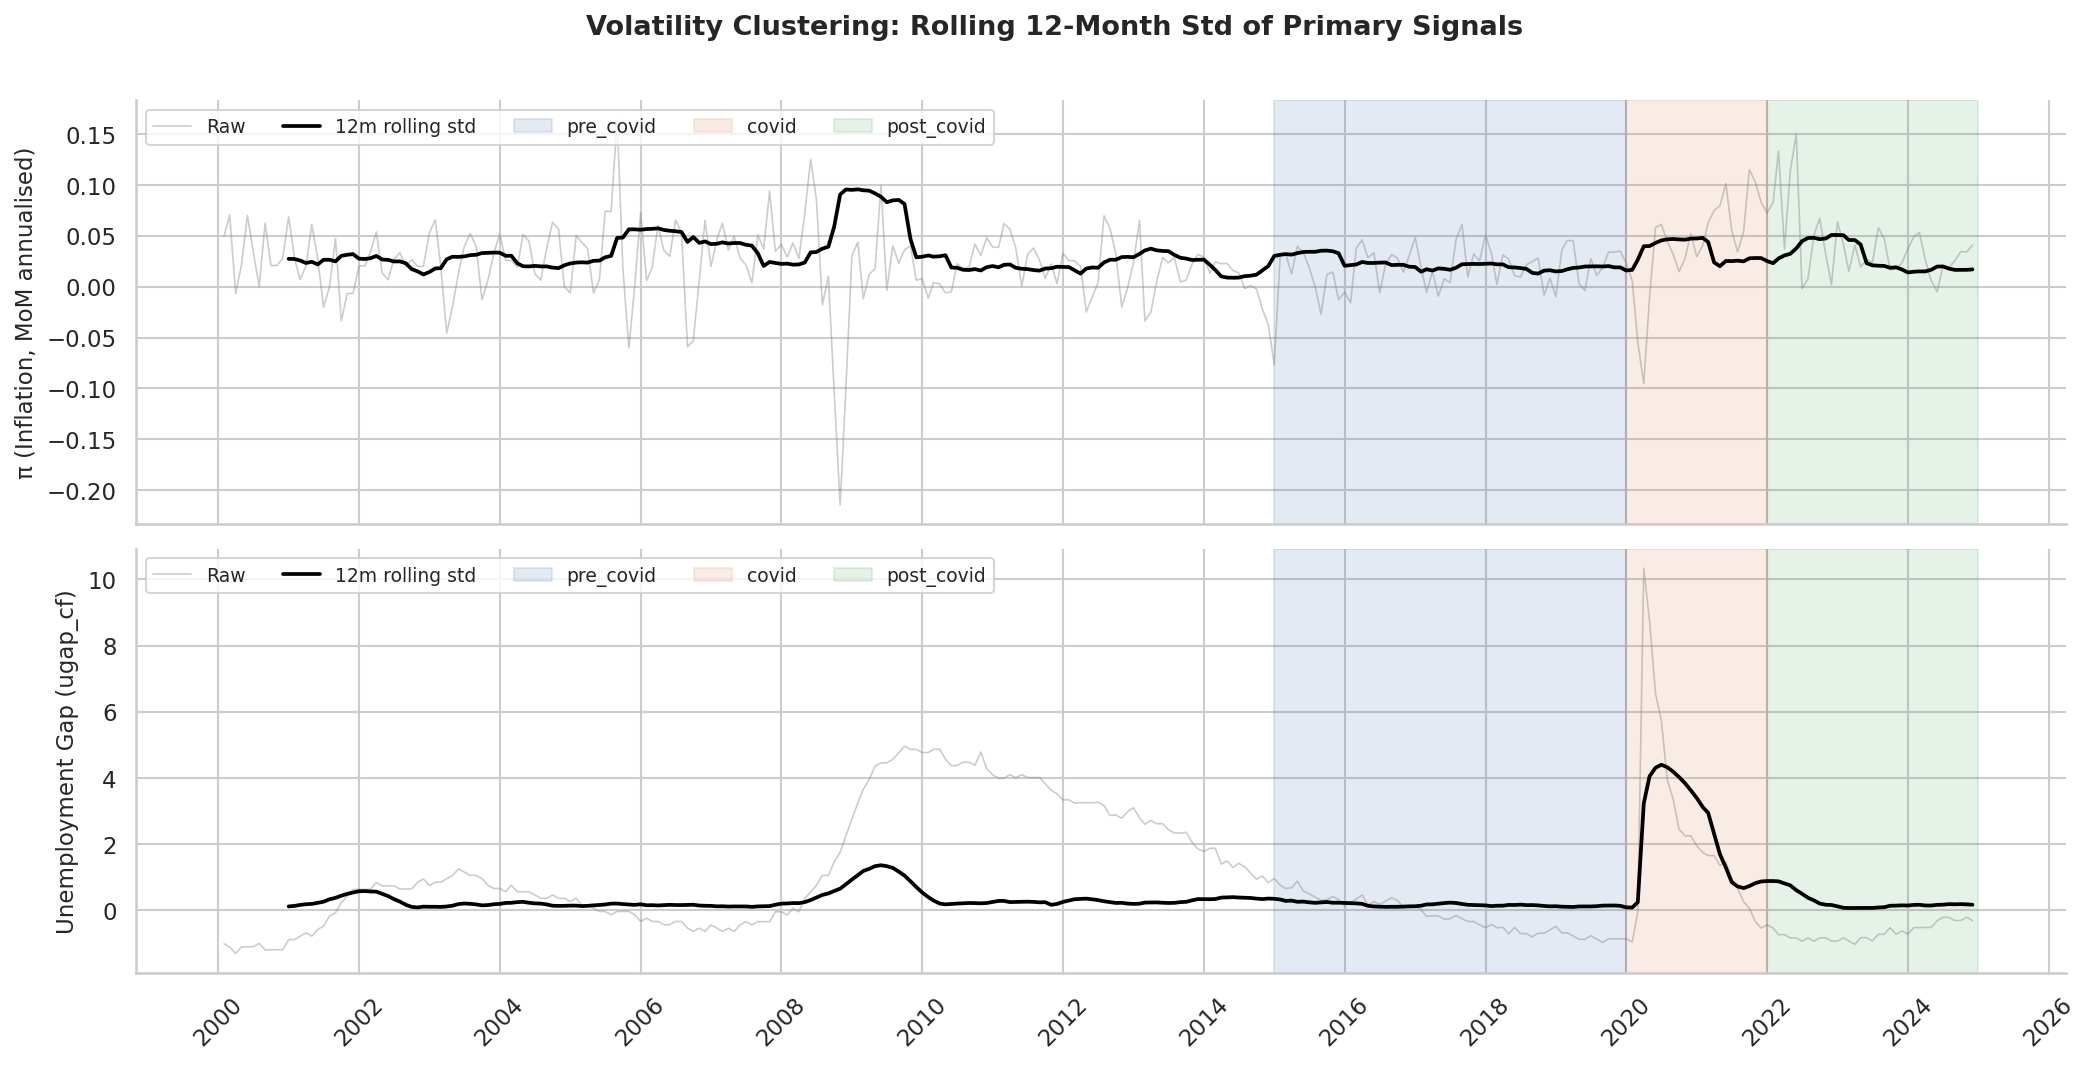

In [ ]:
# Volatility Clustering & Heteroscedasticity

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

series_to_plot = [("pi_mom", "π (Inflation, MoM annualised)"),
                  ("ugap_cf", "Unemployment Gap (ugap_cf)")]

for ax, (col, label) in zip(axes, series_to_plot):
    rolling_std = df[col].rolling(12).std()

    # Raw series (light)
    ax.plot(df.index, df[col], color="grey", alpha=0.4, linewidth=0.8, label="Raw")
    # Rolling std (bold)
    ax.plot(df.index, rolling_std, color="black", linewidth=1.8, label="12m rolling std")

    # Regime shading
    for regime, (start, end) in REGIME_SPANS.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color=REGIME_COLORS[regime], label=regime)

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc="upper left", fontsize=9, ncol=5)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
fig.suptitle("Volatility Clustering: Rolling 12-Month Std of Primary Signals",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2.4 — Distribution Shift Across Regimes (KDE)

KDE plots of each feature overlaid for the three regimes. Makes the distributional shift visual rather than rhetorical: the model is being asked to forecast during COVID from parameters fit on pre-COVID data.

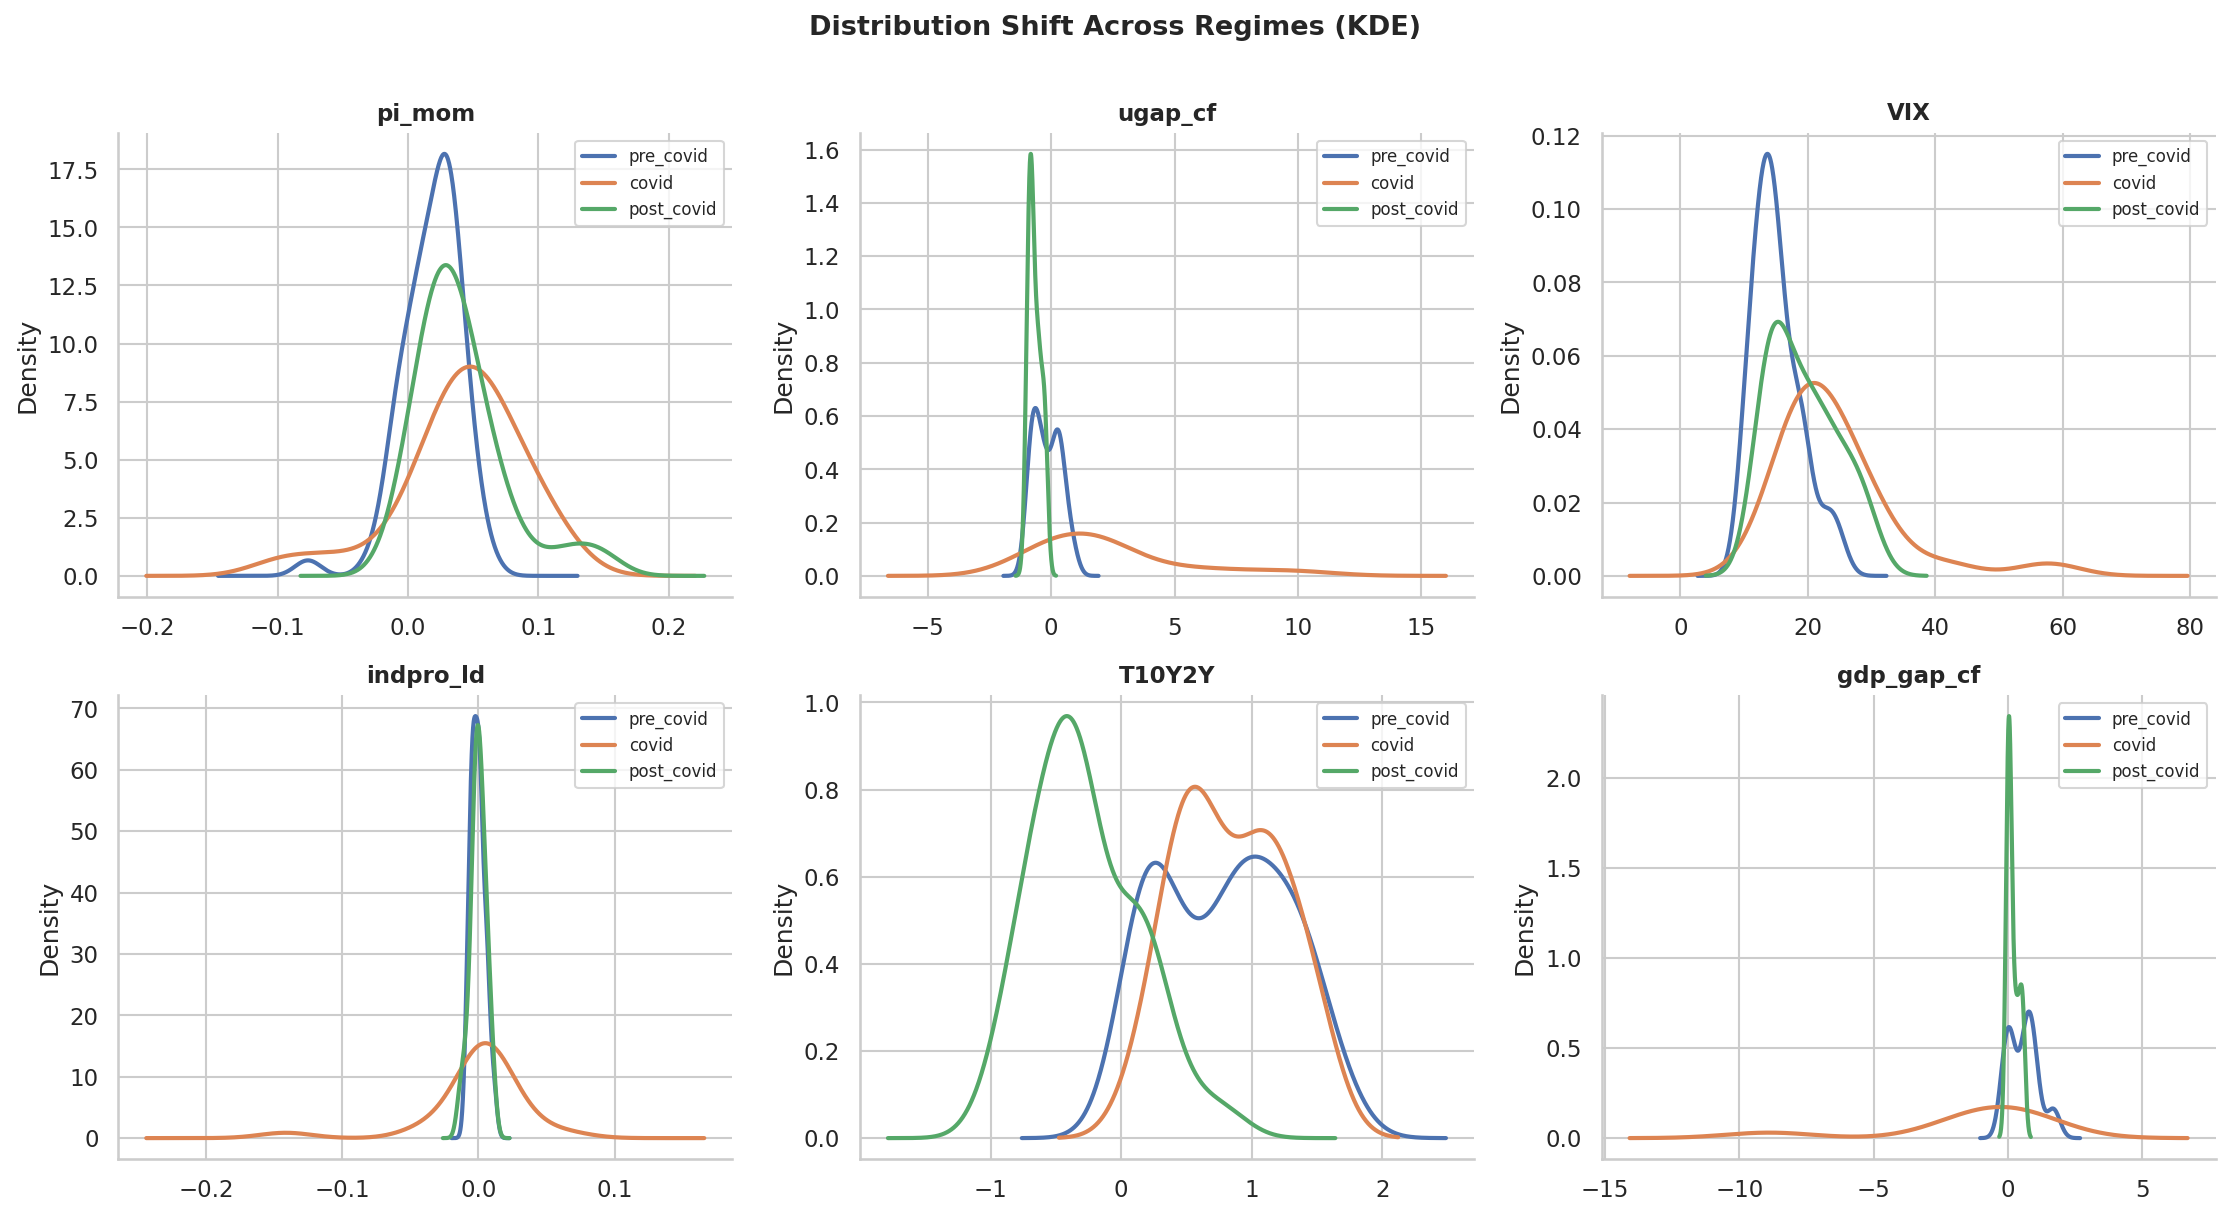

In [ ]:
# Distribution Shift: KDE by Regime

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    for regime in ["pre_covid", "covid", "post_covid"]:
        subset = df[df["regime"] == regime][col].dropna()
        subset.plot.kde(ax=ax, label=regime, color=REGIME_COLORS[regime], linewidth=2)

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

fig.suptitle("Distribution Shift Across Regimes (KDE)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2.5 — Cross-Correlation at Multiple Lags

Heatmap of feature–target Pearson correlations at lags 0, 1, 3, 6, and 12 months. Two things to look for: (a) features whose peak predictive correlation is at a non-zero lag, and (b) features whose lag structure differs between the two targets — which is what makes joint forecasting meaningful.


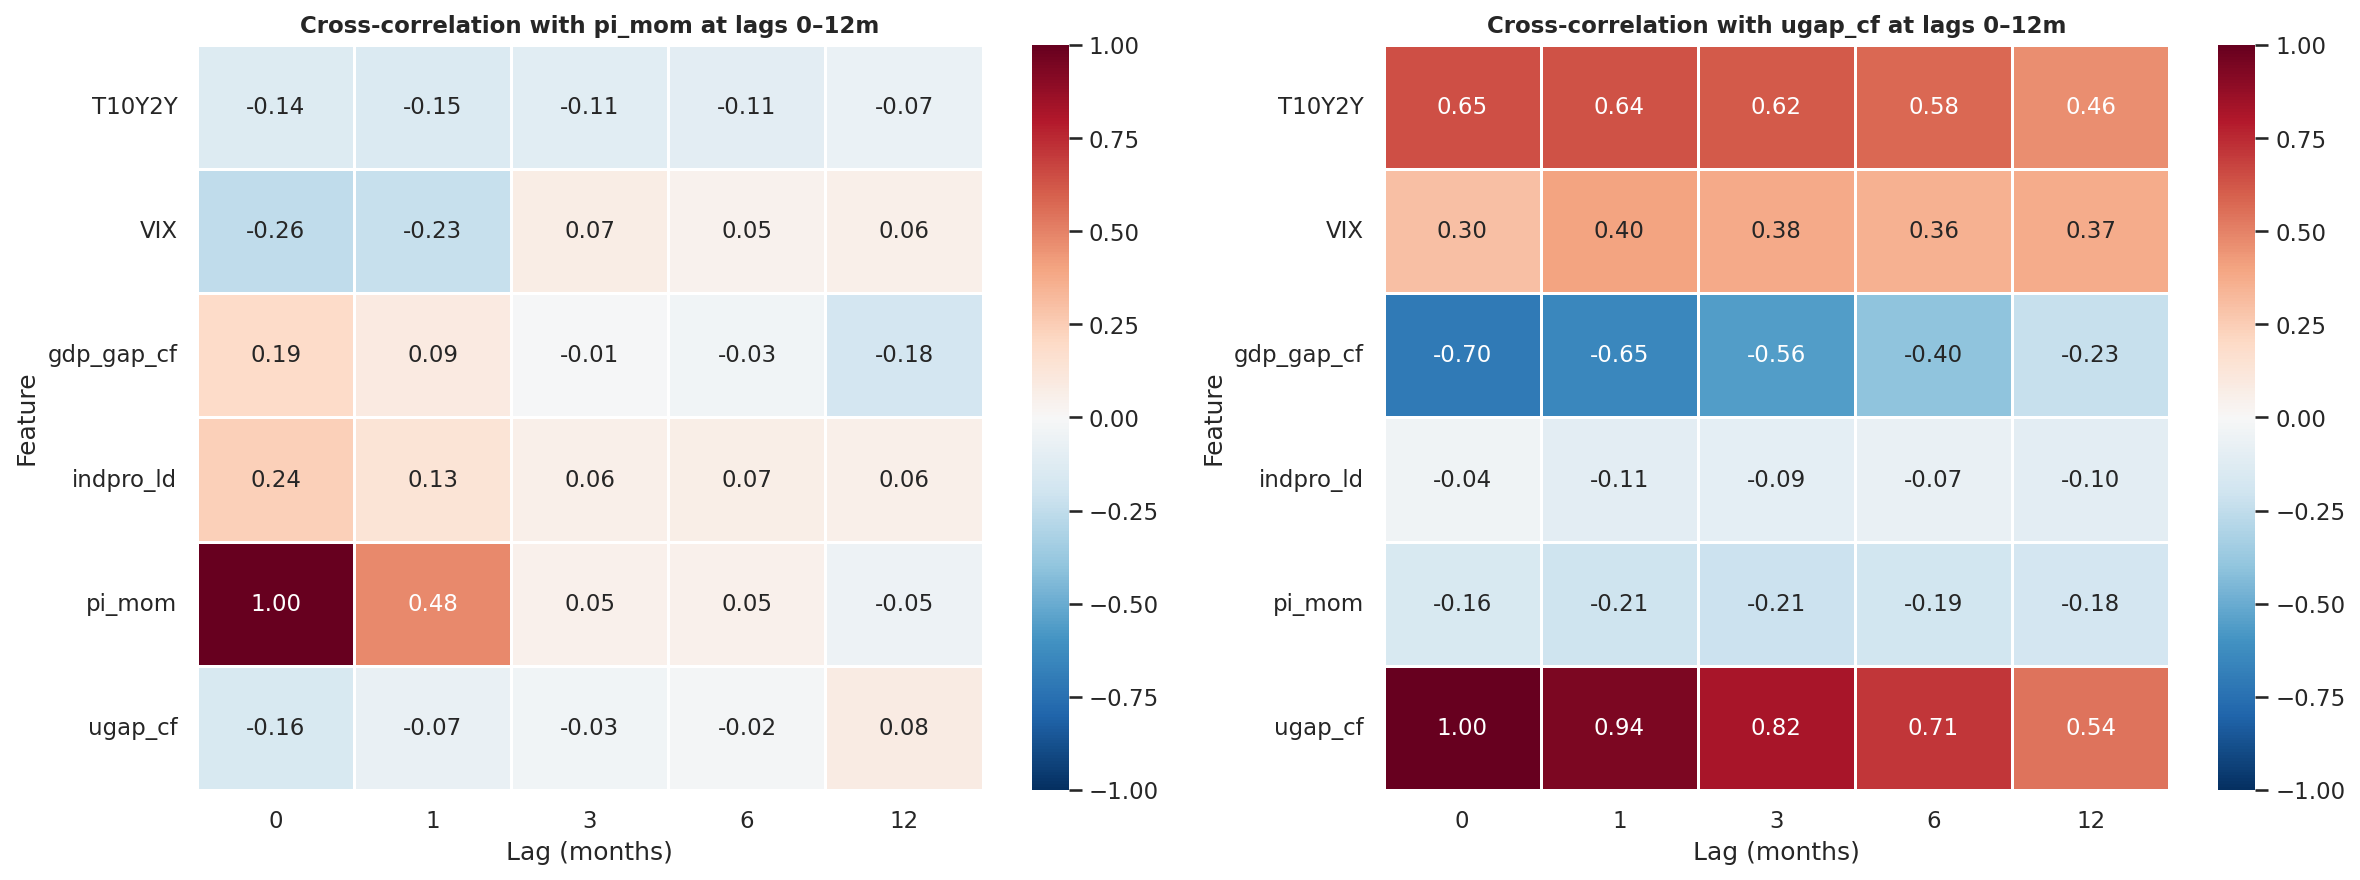

In [ ]:
# Cross-Correlation at Multiple Lags

lags = [0, 1, 3, 6, 12]
results = []

for col in FEATURE_COLS:
    for target in TARGET_COLS:
        for lag in lags:
            shifted = df[col].shift(lag)
            mask = shifted.notna() & df[target].notna()
            r = np.corrcoef(shifted[mask], df[target][mask])[0, 1]
            results.append({"feature": col, "target": target, "lag": lag, "corr": r})

corr_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target in zip(axes, TARGET_COLS):
    pivot = (corr_df[corr_df["target"] == target]
             .pivot(index="feature", columns="lag", values="corr")
             .round(3))

    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f"Cross-correlation with {target} at lags 0–12m",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

### 2.6 — PACF of AR(1) Residuals

Significant PACF values past lag 1 indicate serial structure beyond AR(1) that the LSTM should be picking up — and that motivates both the rolling ARIMA baseline and the ARIMA-LSTM hybrid (Model 5).

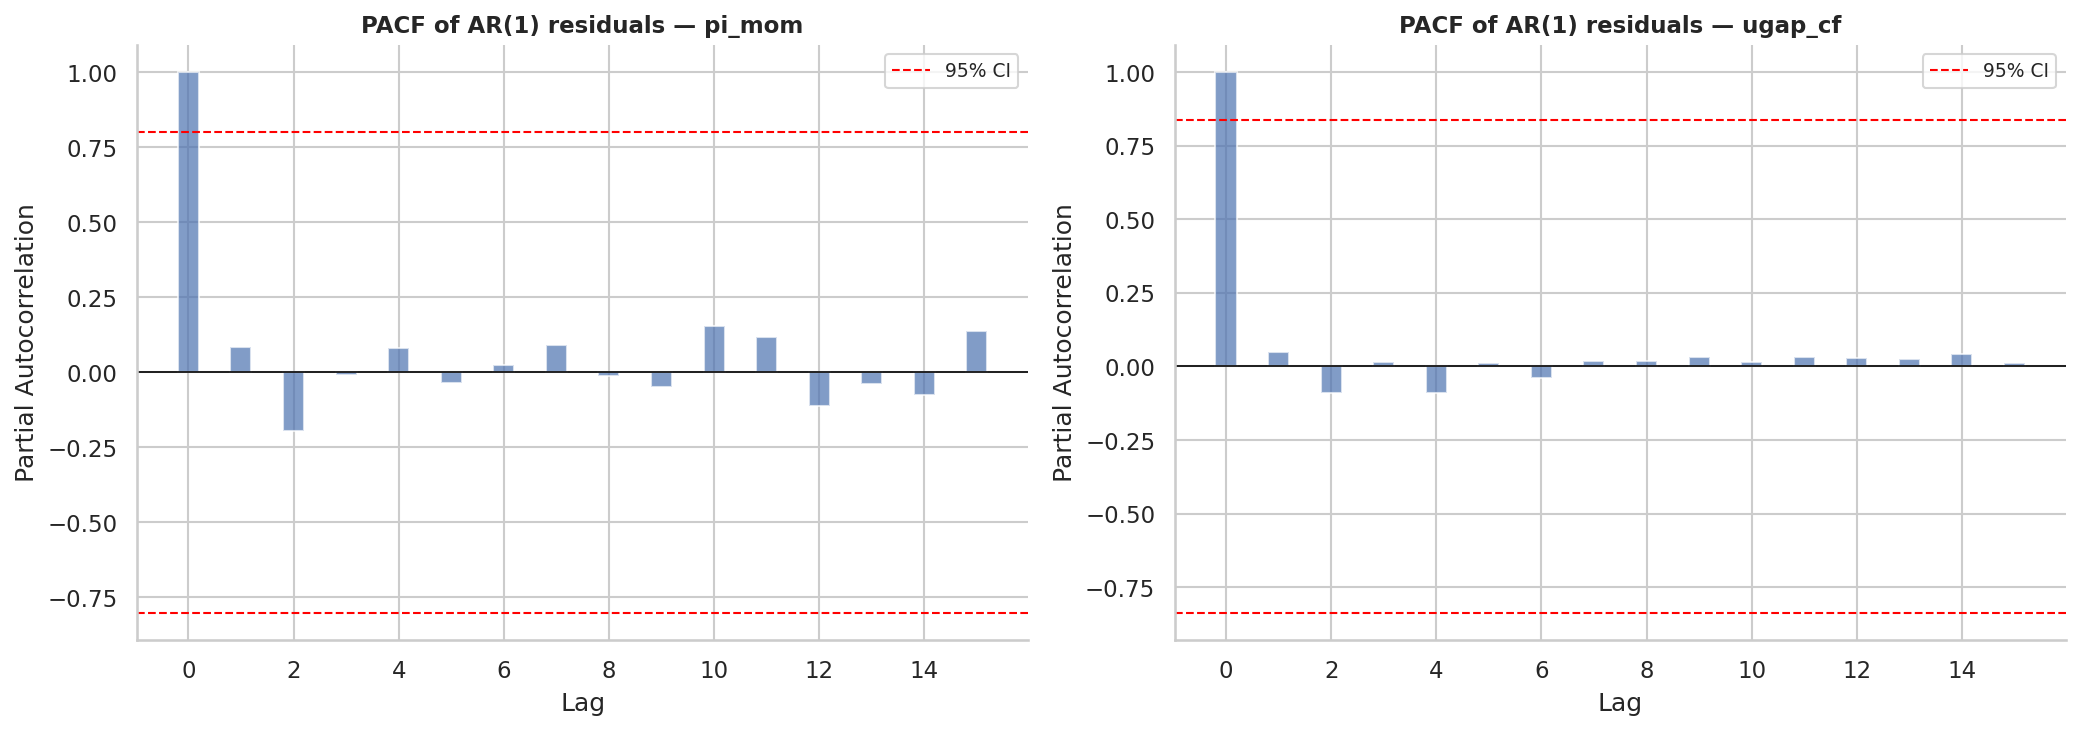

In [ ]:
# PACF of AR(1) Residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, TARGET_COLS):
    # Fit AR(1) and extract residuals
    y = df[col].dropna()
    y_lag = y.shift(1).dropna()
    y_align = y.loc[y_lag.index]

    model = OLS(y_align, add_constant(y_lag)).fit()
    residuals = model.resid

    # PACF
    pacf_vals, confint = pacf(residuals, nlags=15, alpha=0.05)

    lags_range = np.arange(len(pacf_vals))
    ax.bar(lags_range, pacf_vals, color="#4C72B0", alpha=0.7, width=0.4)
    ax.axhline(confint[1, 1] - pacf_vals[0], color="red",
               linestyle="--", linewidth=1, label="95% CI")
    ax.axhline(-(confint[1, 1] - pacf_vals[0]), color="red",
               linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"PACF of AR(1) residuals — {col}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Partial Autocorrelation")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 2.7 — Cross-Frequency Information Content

Compares adjusted R² from a linear regression of each target on monthly-only features vs. monthly + quarterly features, at lags 1, 3, 6, and 12 months. This is the direct empirical justification for the MS-GLSTM's dual-stream design: if the quarterly GDP gap adds no marginal predictive power, the dual-stream story collapses.

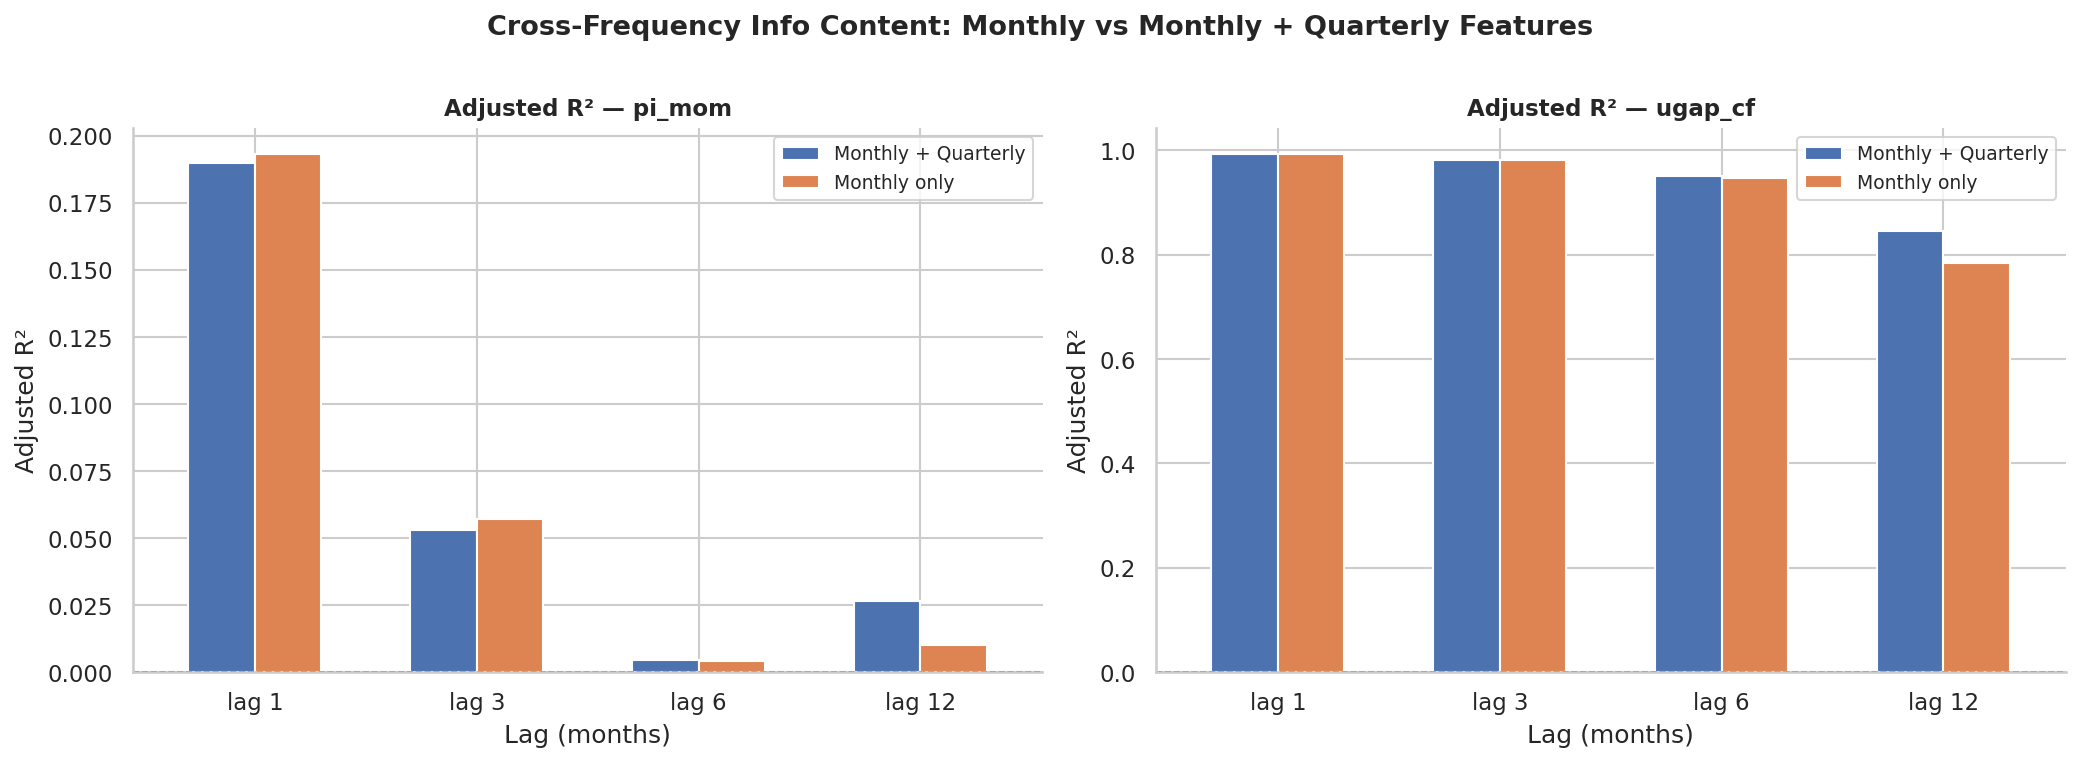

In [ ]:
# Cross-Frequency Information Content

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

MONTHLY_FEATS = ["pi_mom", "ugap_cf", "VIX", "indpro_ld", "T10Y2Y"]
QUARTERLY_FEATS = ["gdp_gap_cf"]
LAGS = [1, 3, 6, 12]

train = df.loc["2000-01":"2017-12"].dropna(subset=FEATURE_COLS)
results = []

for target in TARGET_COLS:
    for lag in LAGS:
        for label, features in [("Monthly only", MONTHLY_FEATS),
                                  ("Monthly + Quarterly", MONTHLY_FEATS + QUARTERLY_FEATS)]:
            X = train[features].shift(lag).dropna()
            y = train[target].loc[X.index]
            mask = y.notna()
            X, y = X[mask], y[mask]

            model = LinearRegression().fit(X, y)
            r2 = r2_score(y, model.predict(X))

            # Adjusted R²
            n, p = len(y), X.shape[1]
            adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

            results.append({"target": target, "lag": lag,
                             "features": label, "adj_r2": round(adj_r2, 4)})

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, TARGET_COLS):
    subset = results_df[results_df["target"] == target]
    pivot  = subset.pivot(index="lag", columns="features", values="adj_r2")
    pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"],
               edgecolor="white", width=0.6)
    ax.set_title(f"Adjusted R² — {target}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Adjusted R²")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=9)
    ax.set_xticklabels([f"lag {l}" for l in LAGS], rotation=0)

plt.suptitle("Cross-Frequency Info Content: Monthly vs Monthly + Quarterly Features",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2.8 — NROU Upsampling Sensitivity

Compares the carry-forward and linear-interpolation upsampling methods for the CBO natural rate of unemployment (NROU). Carry-forward is the conservative default — no intra-quarter information is imputed. This cell confirms the choice doesn't materially affect the unemployment gap series.

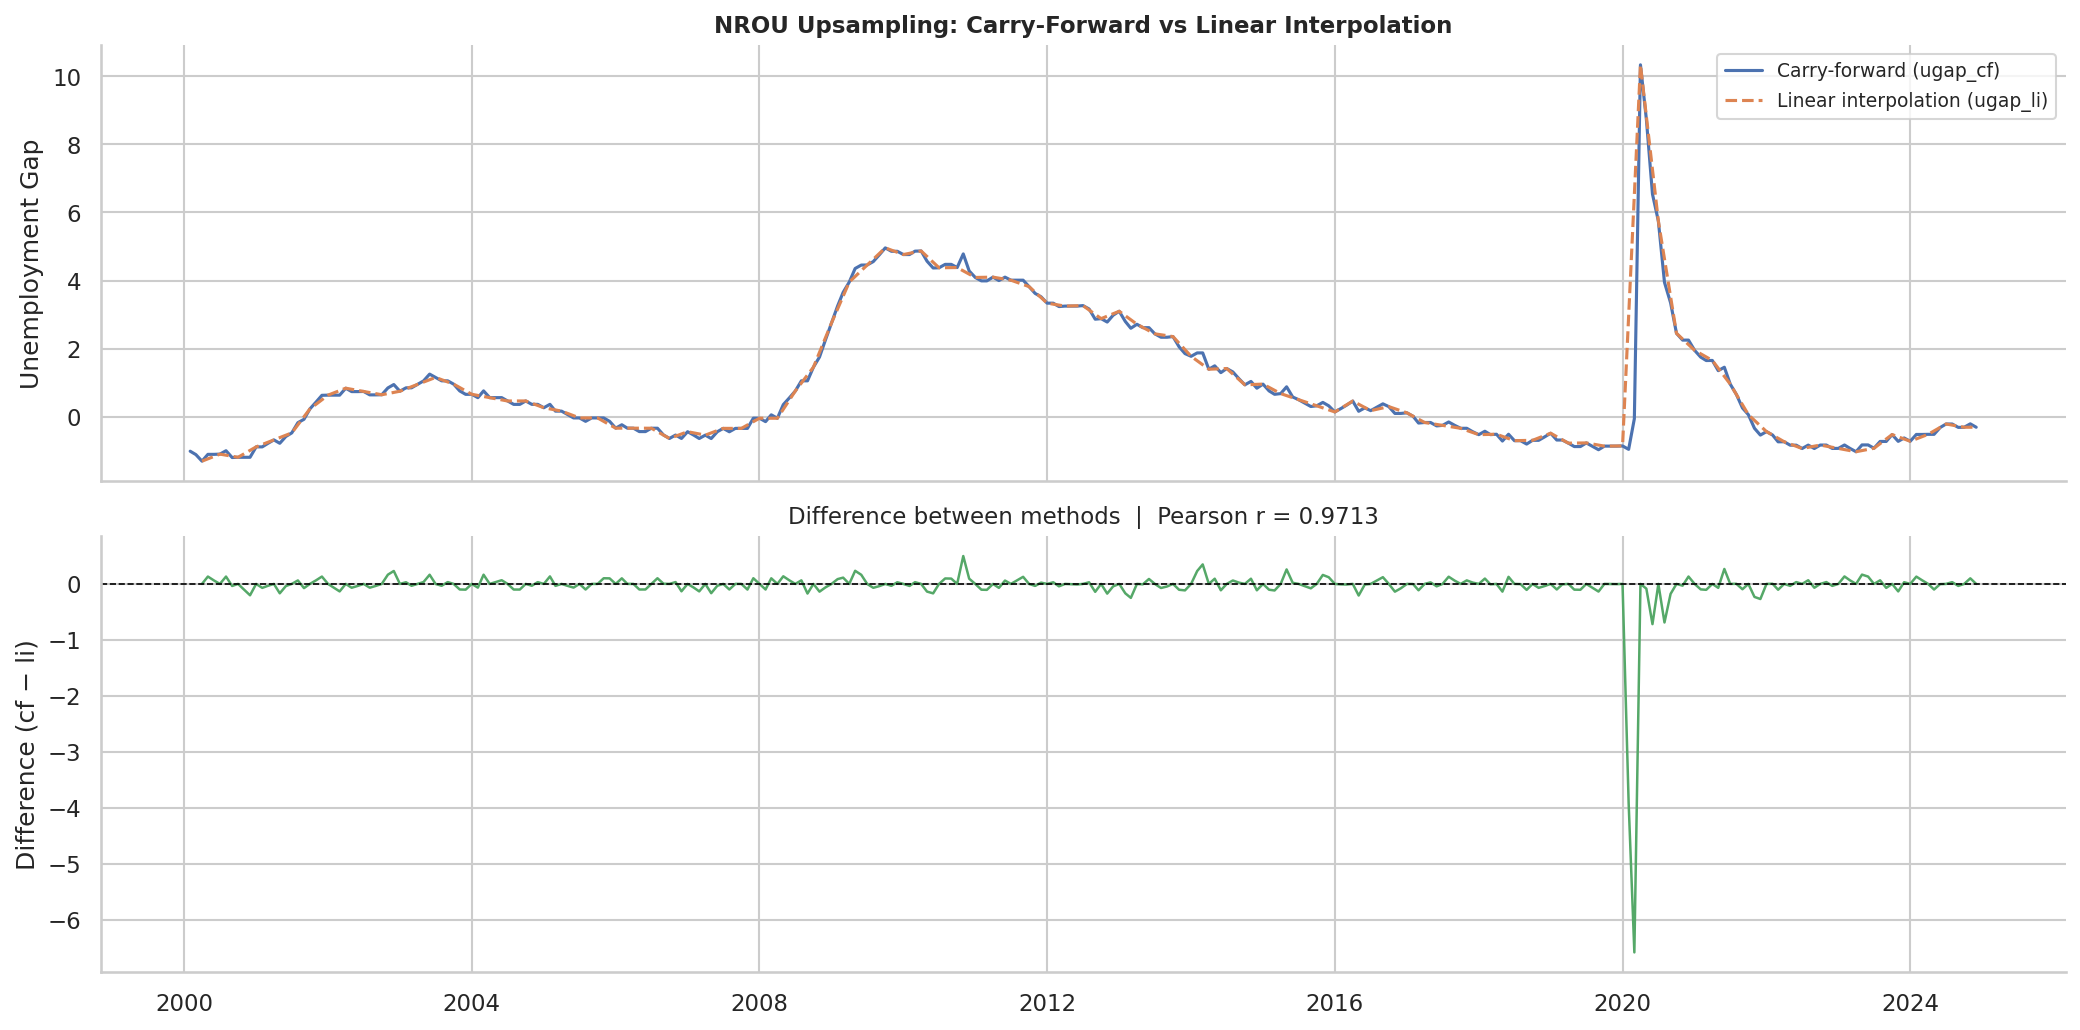

Correlation between carry-forward and linear interpolation: 0.9713
Max absolute difference: 6.5875
Mean absolute difference: 0.0979


In [ ]:
# NROU Upsampling Sensitivity

nrou_q = df["ugap_cf"].copy()  # compare cf vs interpolated on ugap_cf itself

# Get quarterly timestamps from ugap_cf
ugap_cf_q = df["ugap_cf"].resample("QS").first()
ugap_li  = ugap_cf_q.reindex(df.index).interpolate(method="time")

corr = df["ugap_cf"].corr(ugap_li)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top panel: both series overlaid
axes[0].plot(df.index, df["ugap_cf"], label="Carry-forward (ugap_cf)",
             color="#4C72B0", linewidth=1.5)
axes[0].plot(df.index, ugap_li, label="Linear interpolation (ugap_li)",
             color="#DD8452", linewidth=1.5, linestyle="--")
axes[0].set_ylabel("Unemployment Gap")
axes[0].legend(fontsize=9)
axes[0].set_title("NROU Upsampling: Carry-Forward vs Linear Interpolation",
                  fontsize=11, fontweight="bold")

# Bottom panel difference
diff = (df["ugap_cf"] - ugap_li)
axes[1].plot(df.index, diff, color="#55A868", linewidth=1.2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Difference (cf − li)")
axes[1].set_title(f"Difference between methods  |  Pearson r = {corr:.4f}",
                  fontsize=11)

plt.tight_layout()
plt.show()

print(f"Correlation between carry-forward and linear interpolation: {corr:.4f}")
print(f"Max absolute difference: {diff.abs().max():.4f}")
print(f"Mean absolute difference: {diff.abs().mean():.4f}")

### 2.9 — HP-Filter Endpoint Bias

The HP filter is known to produce unreliable estimates near the endpoints of the sample. This cell compares the GDP gap computed on the full 2000–2024 sample versus a truncated 2000–2022 sample, focusing on the COVID window where the discrepancy matters most.

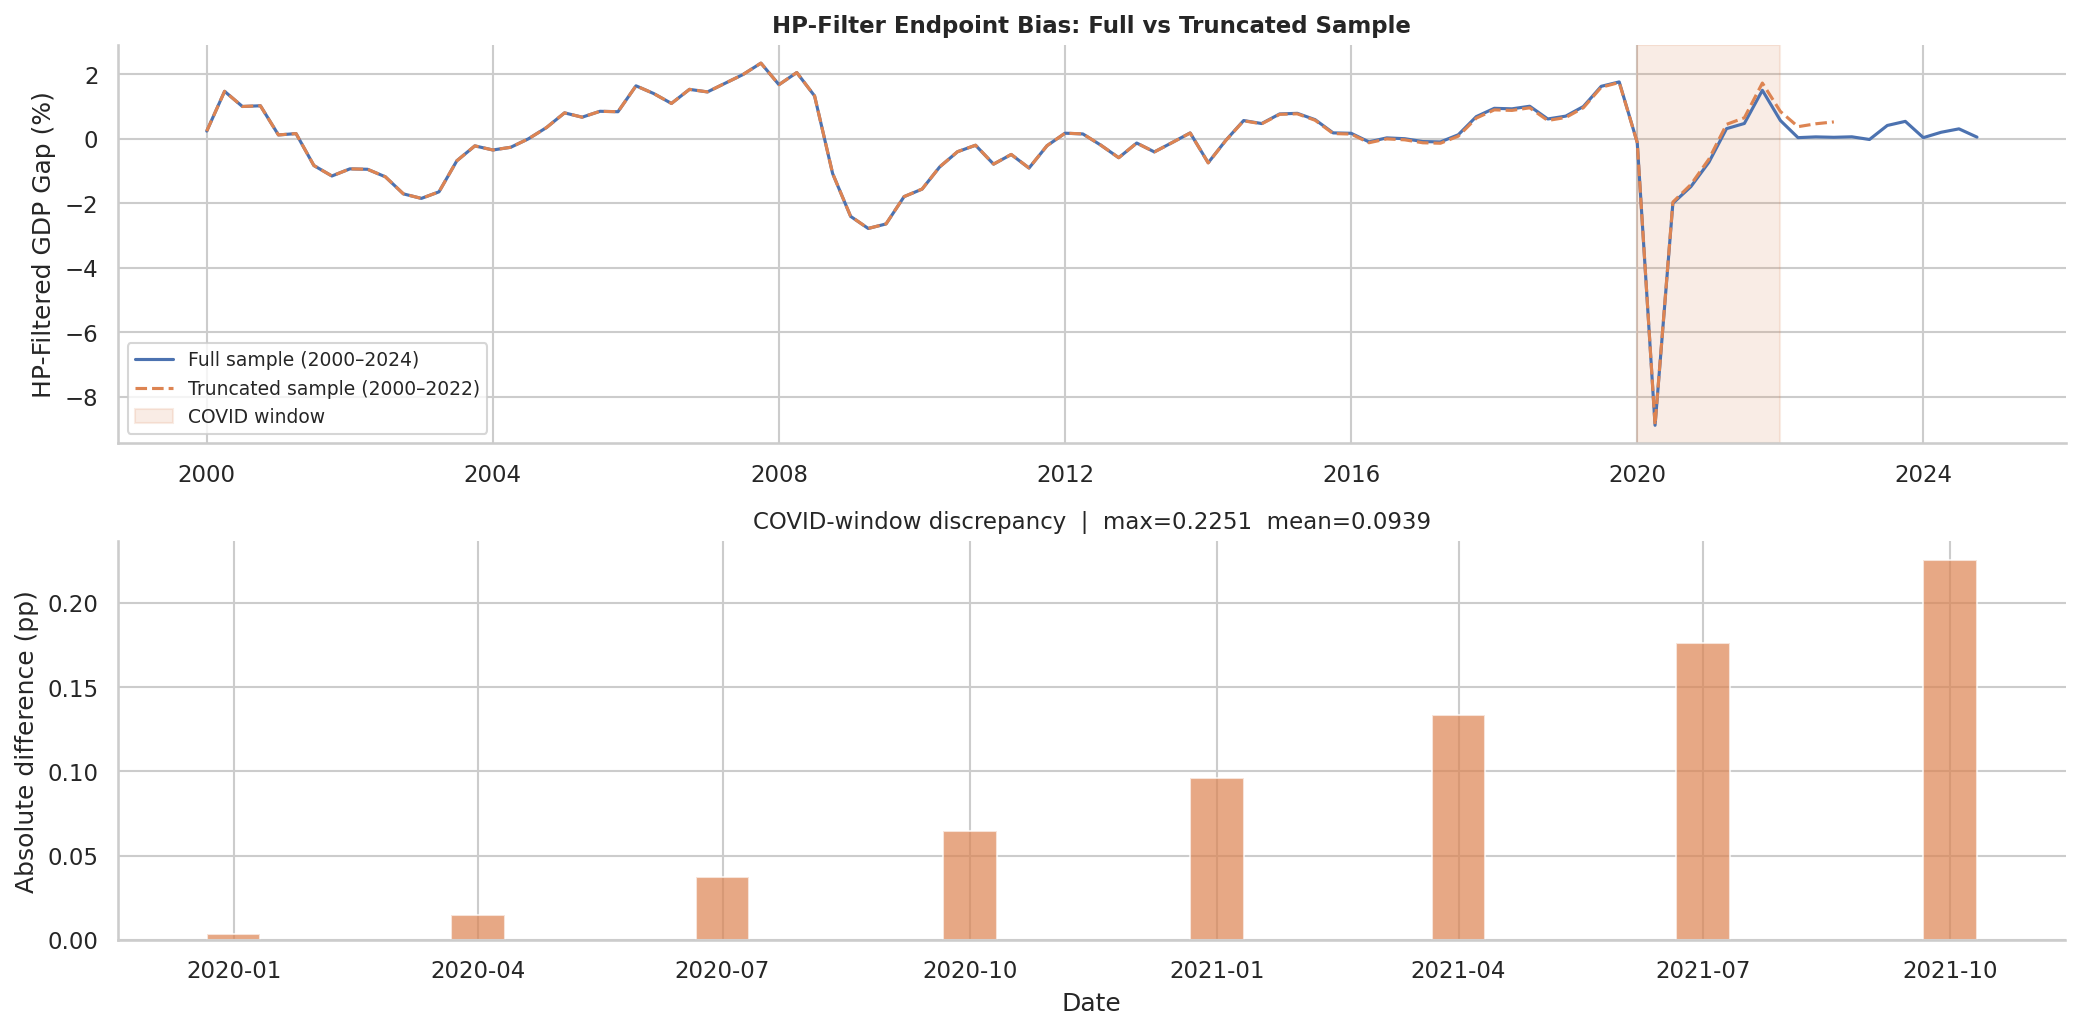

Max absolute difference in COVID window: 0.2251 pp
Mean absolute difference in COVID window: 0.0939 pp


In [ ]:
# HP-Filter Endpoint Bias Check
#
# Re-runs hpfilter() from scratch on raw GDPC1 on two sample windows:
#   (a) Full sample 2000–2024
#   (b) Truncated sample ending 2022
# This is the correct test — comparing the already-filtered gdp_gap_cf
# series would give zero difference by construction.

from statsmodels.tsa.filters.hp_filter import hpfilter

# Load raw GDPC1 from cached parquet
raw_df  = pd.read_parquet(DATA_DIR / "fred_raw.parquet")
gdpc1   = raw_df["GDPC1"].dropna()
gdpc1.index = gdpc1.index.to_period("M").to_timestamp()
gdpc1_log = np.log(gdpc1)

# Full sample HP filter
_, trend_full = hpfilter(gdpc1_log, lamb=1600)
gap_full = ((gdpc1_log - trend_full) * 100)

# Truncated sample HP filter (ending 2022)
gdpc1_log_trunc = gdpc1_log.loc[:"2022-12-31"]
_, trend_trunc  = hpfilter(gdpc1_log_trunc, lamb=1600)
gap_trunc = ((gdpc1_log_trunc - trend_trunc) * 100)

# Compare in COVID window
covid_window = ("2020-01-01", "2021-12-31")
full_covid  = gap_full.loc[covid_window[0]:covid_window[1]]
trunc_covid = gap_trunc.loc[covid_window[0]:covid_window[1]]
diff        = (full_covid - trunc_covid).abs()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Top panel full series comparison
axes[0].plot(gap_full.index, gap_full,
             label="Full sample (2000–2024)", color="#4C72B0", linewidth=1.5)
axes[0].plot(gap_trunc.index, gap_trunc,
             label="Truncated sample (2000–2022)", color="#DD8452",
             linewidth=1.5, linestyle="--")
axes[0].axvspan(pd.Timestamp(covid_window[0]), pd.Timestamp(covid_window[1]),
                alpha=0.15, color=REGIME_COLORS["covid"], label="COVID window")
axes[0].set_ylabel("HP-Filtered GDP Gap (%)")
axes[0].set_title("HP-Filter Endpoint Bias: Full vs Truncated Sample",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)

# Bottom panel: COVID-window difference
axes[1].bar(full_covid.index, diff, color="#DD8452", alpha=0.7, width=20)
axes[1].set_ylabel("Absolute difference (pp)")
axes[1].set_title(
    f"COVID-window discrepancy  |  max={diff.max():.4f}  mean={diff.mean():.4f}",
    fontsize=11)
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"Max absolute difference in COVID window: {diff.max():.4f} pp")
print(f"Mean absolute difference in COVID window: {diff.mean():.4f} pp")

### 2.10 — Seasonality Residual Check on `indpro_ld`

Industrial production is officially seasonally adjusted, but log-differencing can re-introduce calendar artefacts. A monthly-dummy OLS regression tests whether any month-of-year effect survives the SA + diff transformation.

                            OLS Regression Results                            
Dep. Variable:              indpro_ld   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.030
Method:                 Least Squares   F-statistic:                    0.4288
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.942
Time:                        13:04:12   Log-Likelihood:                 774.36
No. Observations:                 215   AIC:                            -1525.
Df Residuals:                     203   BIC:                            -1484.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.002     -0.245      0.8

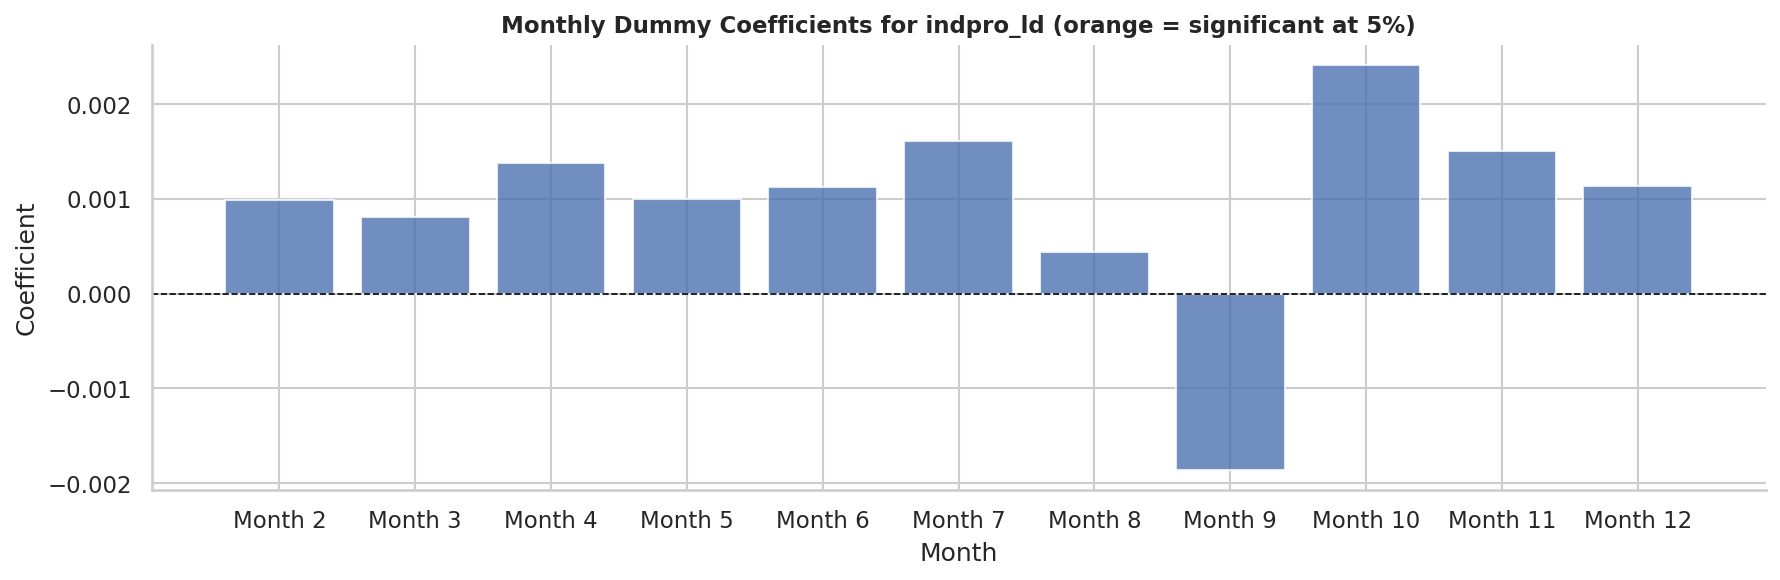

In [ ]:
# Seasonality Residual Check on indpro_ld

train = df.loc["2000-01":"2017-12", "indpro_ld"].dropna()

# Build monthly dummy matrix and drop January to avoid multicollinearity
dummies = pd.get_dummies(train.index.month, prefix="m", drop_first=True).astype(float)
dummies.index = train.index

X = add_constant(dummies)
model = OLS(train, X).fit()

print(model.summary())
print("\n=== Month Coefficients ===")
coef_df = pd.DataFrame({
    "coef":    model.params[1:],
    "p_value": model.pvalues[1:],
    "significant (p<0.05)": model.pvalues[1:] < 0.05
})
coef_df.index = [f"Month {i+2}" for i in range(len(coef_df))]
print(coef_df.round(4))

# Plot coefficients with error bars
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(coef_df.index, coef_df["coef"],
       color=["#DD8452" if s else "#4C72B0" for s in coef_df["significant (p<0.05)"]],
       alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Dummy Coefficients for indpro_ld (orange = significant at 5%)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Coefficient")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

### 2.11 — April 2020 Outlier Characterisation

The April 2020 INDPRO drop is the largest single-month observation in the dataset. This cell quantifies it via z-score, identifies the next-largest observations, and plots the full series with the outlier highlighted. The observation is retained — it is real and its leverage on LSTM training is documented here.

=== Top 5 Observations by |Z-score| ===
              value  z_score
2020-04-01 -0.14142   -12.01
2020-06-01  0.06347     5.35
2008-09-01 -0.04505    -3.84
2020-03-01 -0.03991    -3.41
2020-07-01  0.03679     3.09

April 2020 z-score:          -12.01
Next largest |z-score|:      5.35
Distance to next largest:    6.66 standard deviations


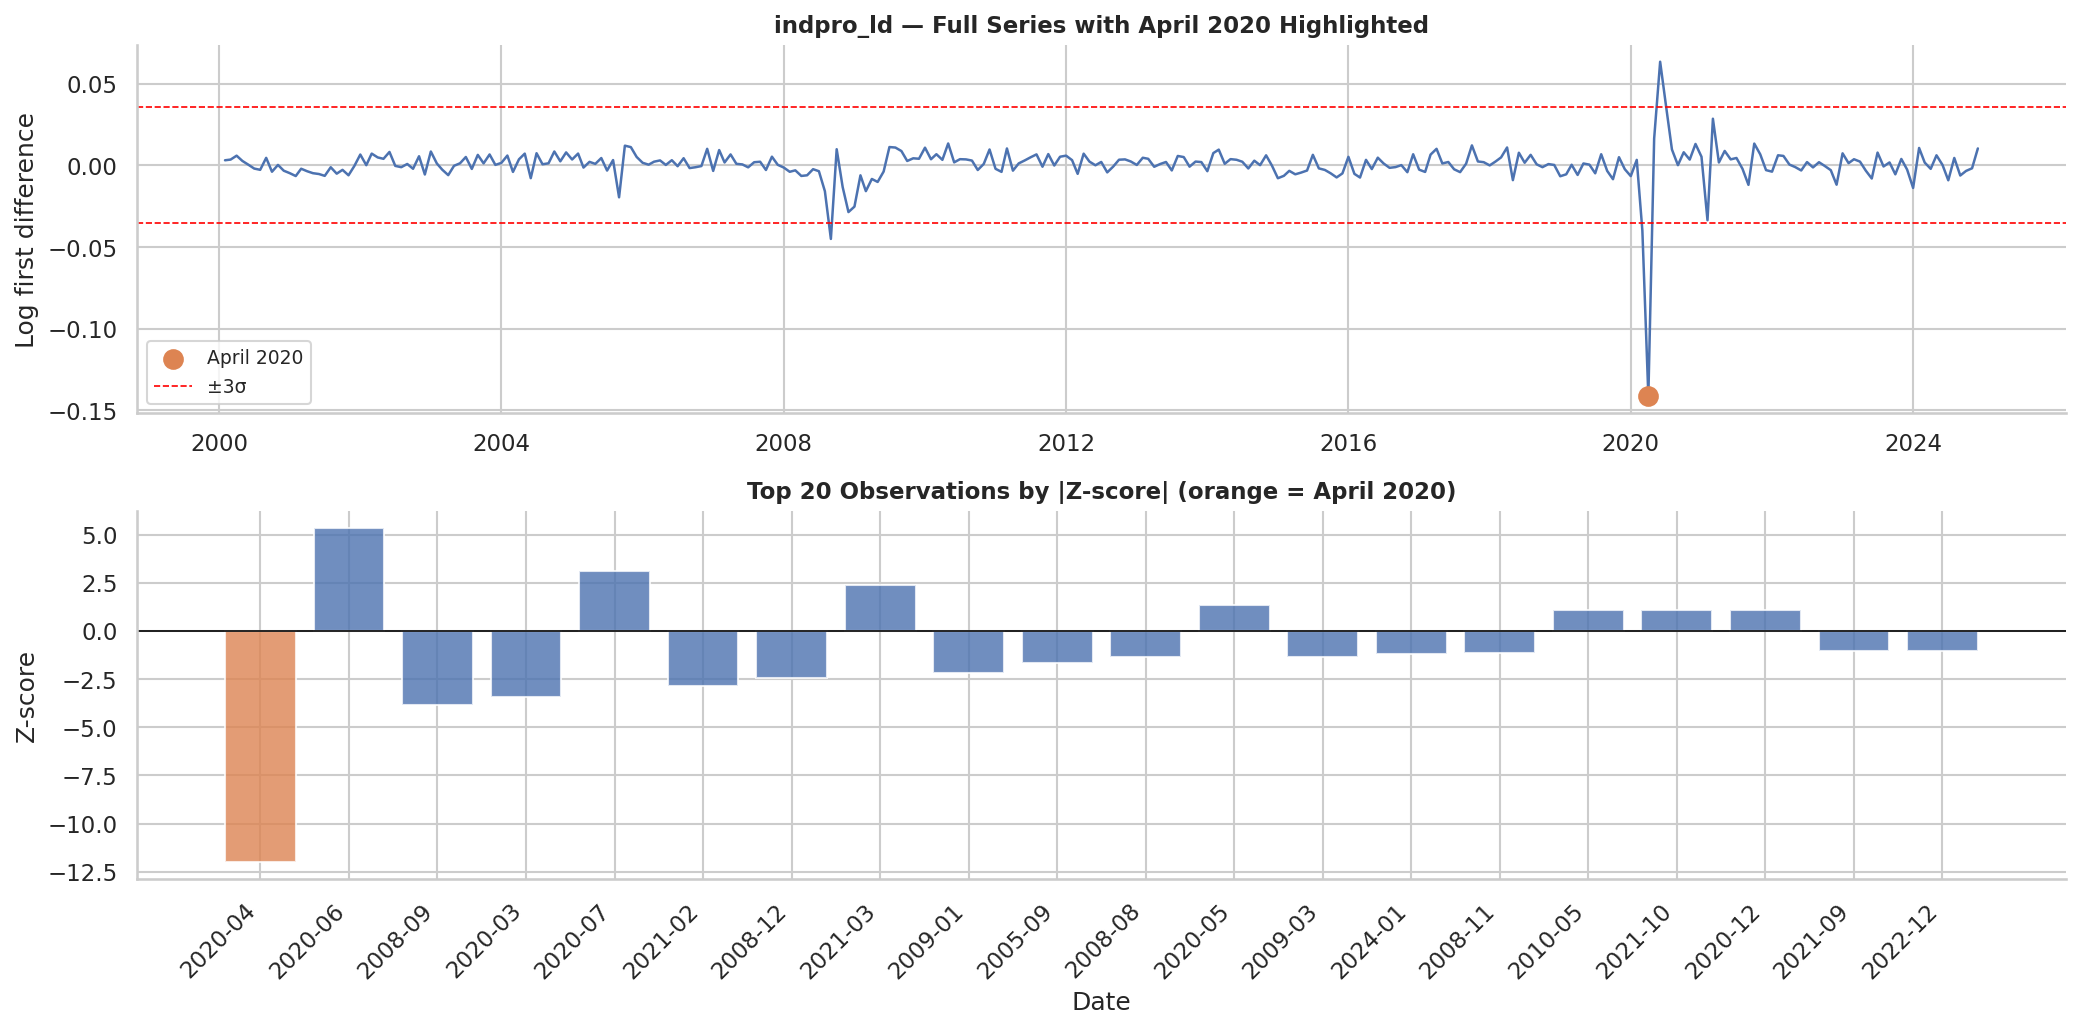

In [ ]:
# April 2020 Outlier Characterisation: COVID!

col = "indpro_ld"
series = df[col].dropna()

# Z-scores
z_scores = (series - series.mean()) / series.std()
z_april_2020 = z_scores["2020-04-01"]

# Distance to next largest (in absolute terms)
z_sorted = z_scores.abs().sort_values(ascending=False)
top5 = z_sorted.head(5)

print("=== Top 5 Observations by |Z-score| ===")
print(pd.DataFrame({
    "value":   series[top5.index].round(5),
    "z_score": z_scores[top5.index].round(2)
}))

print(f"\nApril 2020 z-score:          {z_april_2020:.2f}")
print(f"Next largest |z-score|:      {z_sorted.iloc[1]:.2f}")
print(f"Distance to next largest:    {(z_sorted.iloc[0] - z_sorted.iloc[1]):.2f} standard deviations")

# Plot full series with April 2020 highlighted
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Top: full time series with outlier marked
axes[0].plot(series.index, series, color="#4C72B0", linewidth=1.2)
axes[0].scatter(pd.Timestamp("2020-04-01"), series["2020-04-01"],
                color="#DD8452", zorder=5, s=80, label="April 2020")
axes[0].axhline(series.mean() + 3*series.std(), color="red",
                linestyle="--", linewidth=0.8, label="±3σ")
axes[0].axhline(series.mean() - 3*series.std(), color="red",
                linestyle="--", linewidth=0.8)
axes[0].set_title("indpro_ld — Full Series with April 2020 Highlighted",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Log first difference")
axes[0].legend(fontsize=9)

# Bottom: Z-score bar chart, top 20 extremes
top20 = z_scores.abs().sort_values(ascending=False).head(20)
colors = ["#DD8452" if idx == pd.Timestamp("2020-04-01") else "#4C72B0"
          for idx in top20.index]
axes[1].bar(top20.index.strftime("%Y-%m"), z_scores[top20.index].values,
            color=colors, alpha=0.8, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 20 Observations by |Z-score| (orange = April 2020)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Date")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

---
## Section 3 — Models

We train and evaluate eight models of increasing sophistication. Each cell is **self-contained**: it loads `master_df.csv` and `norm_params.json` from Drive, trains (or loads cached weights), runs inference on all three test splits, and writes predictions to `artifacts/{model_name}_predictions.npz`.

The evaluation cell (Section 4) consumes all `.npz` files — no in-memory state passes between model cells.

### Model inventory

| # | Model | Architecture | Uncertainty | Loss | Owner |
|---|---|---|---|---|---|
| 0 | Rolling ARIMA | Univariate ARIMA per target | Analytical residual variance | MLE | Dhruv |
| 1 | Standard LSTM | 2-layer LSTM + linear head | None (point forecast) | MSE | Dhruv |
| 2 | MC Dropout LSTM | 2-layer LSTM + dropout | Approximate posterior (T=50) | MSE | Andres |
| 3 | Deep Ensemble | 5× LSTM + Gaussian head | Between-model disagreement | NLL | Andres |
| 4 | **MS-GLSTM** | Dual-stream LSTM + Gaussian head | Structural Gaussian head | NLL + CRPS | Angelo |
| 5 | ARIMA-LSTM Hybrid | MS-GLSTM + ARIMA residual variance | Gaussian head + ARIMA residuals | NLL + CRPS / MLE | Andres |
| 6a/6b | Temporal Transformer | Transformer + Gaussian head | Structural Gaussian head | NLL / NLL+CRPS | Aditya |

### Shared conventions
- All models use `SEQ_LEN = 24` months of lookback.
- Features are normalised using `norm_params.json` (fit on 2000–2017 only).
- Test splits: `test_pre` (2013–2019), `test_covid` (2018–2021), `test_post` (2020–2024).
- All predictions stored in normalised units. Use `norm_params.json` to convert back to original scale.

### Model 0 — Rolling ARIMA Baseline

The classical anchor for the comparison. A separate univariate ARIMA($p$, 0, $q$) is fit for each target using AIC-optimal order selection on the training window. Predictions are generated via an **expanding window**: at each test date $t$, the model is refit on all history strictly prior to $t$.

**Key property:** the ARIMA's residual variance is anchored to the training distribution. Its confidence intervals do not adapt to structural breaks — they are conservative by construction. This makes ARIMA a benchmark for *calibration-by-conservatism* rather than adaptive uncertainty quantification.

**Output:** `artifacts/arima_predictions.npz`

In [ ]:

# Model 0: Rolling ARIMA Baseline
#
# Classical anchor for the distributional comparison. Fits a univariate ARIMA
# independently for each target (pi_mom, ugap_cf_neg) using an expanding
# window. Analytical confidence intervals from the ARIMA forecast distribution
# supply σ̂_t — the classical alternative to the learned heteroscedastic head.
#
# Design choices:
#   • Expanding window (not rolling): all available history used at each step,
#     consistent with a forecaster who never discards data.
#   • Order selection: AIC-optimal order fit once on the training window
#     (2000-01 → 2017-12), then fixed for all rolling steps. Avoids the
#     computational cost of re-running auto_arima at every timestep while
#     still being data-driven.
#   • σ̂_t derived from the 68% analytical prediction interval (≈ ±1σ for a
#     Gaussian), giving a directly comparable uncertainty estimate.
#   • Predictions generated for all months in the union of test splits
#     (2013-01 → 2024-12). The evaluation cell slices to specific regimes.
#
# Outputs (written to PROJECT_DIR/artifacts/):
#   arima_predictions.npz  — mu, sigma, y_true, dates per test split
# ==============================================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

#  Paths
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PREDS_NPZ = ARTIFACT_DIR / "arima_predictions.npz"

# Configuration
TRAIN_START = "2000-01-01"
TRAIN_END = "2017-12-31"
PRED_START = "2013-01-01"
PRED_END  = "2024-12-31"

TARGET_COLS  = ["pi_mom", "ugap_cf_neg"]

SPLITS = {
    "test_pre":   ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post":  ("2020-01-01", "2024-12-31"),
}

# Load data

df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
df["ugap_cf_neg"] = -df["ugap_cf"]

print(f"  df shape: {df.shape}")
print(f"  Targets available: {[c for c in TARGET_COLS if c in df.columns]}")


# Stationarity check
for col in TARGET_COLS:
    series = df.loc[TRAIN_START:TRAIN_END, col].dropna()
    adf_stat, p_val, _, _, _, _ = adfuller(series)
    print(f"  {col:15s}  ADF={adf_stat:.3f}  p={p_val:.4f}  "
          f"{'stationary' if p_val < 0.05 else 'non-stationary ✗'}")


# AIC-optimal order selection on training window

def select_arima_order(series: pd.Series,
                       p_range=range(0, 4),
                       q_range=range(0, 4),
                       d: int = 0) -> tuple:
    """Grid search over (p, q) for fixed d, return AIC-minimising order."""
    best_aic, best_order = np.inf, (1, 0, 1)
    for p in p_range:
        for q in q_range:
            if p == 0 and q == 0:
                continue
            try:
                aic = ARIMA(series, order=(p, d, q)).fit().aic
                if aic < best_aic:
                    best_aic, best_order = aic, (p, d, q)
            except Exception:
                continue
    return best_order, best_aic

orders = {}
for col in TARGET_COLS:
    series = df.loc[TRAIN_START:TRAIN_END, col].dropna()
    order, aic = select_arima_order(series)
    orders[col] = order
    print(f"  {col:15s}  best order={order}  AIC={aic:.2f}")


# Rolling expanding-window forecast
pred_dates = pd.date_range(PRED_START, PRED_END, freq="MS")
all_mu = {col: [] for col in TARGET_COLS}
all_sigma  = {col: [] for col in TARGET_COLS}
all_y  = {col: [] for col in TARGET_COLS}
valid_dates = []

for t in pred_dates:

    history_end = t - pd.DateOffset(months=1)
    skip = False

    mu_t, sigma_t, y_t = {}, {}, {}

    for col in TARGET_COLS:
        history = df.loc[TRAIN_START:history_end, col].dropna()
        y_true  = df.loc[t, col] if t in df.index else np.nan

        if len(history) < 24 or np.isnan(y_true):
            skip = True
            break

        try:
            fit = ARIMA(history, order=orders[col]).fit()
            fc = fit.get_forecast(steps=1)
            mu_val = float(fc.predicted_mean.iloc[0])

            ci = fc.conf_int(alpha=0.32)
            sigma_val = float((ci.iloc[0, 1] - ci.iloc[0, 0]) / 2)

            mu_t[col] = mu_val
            sigma_t[col] = max(sigma_val, 1e-6)
            y_t[col] = float(y_true)

        except Exception as e:
            skip = True
            break

    if skip:
        continue

    valid_dates.append(t)
    for col in TARGET_COLS:
        all_mu[col].append(mu_t[col])
        all_sigma[col].append(sigma_t[col])
        all_y[col].append(y_t[col])

valid_dates = pd.DatetimeIndex(valid_dates)
print(f"  Generated {len(valid_dates)} predictions "
      f"({valid_dates.min().date()} → {valid_dates.max().date()})")


# Stack into arrays and slice per split

# Shape: (N, 2) matching TARGET_COLS order
mu_arr = np.array([all_mu[c]    for c in TARGET_COLS], dtype=np.float32).T
sigma_arr = np.array([all_sigma[c] for c in TARGET_COLS], dtype=np.float32).T
y_arr = np.array([all_y[c]     for c in TARGET_COLS], dtype=np.float32).T

print(f"\n  mu_arr shape:    {mu_arr.shape}")
print(f"  sigma_arr shape: {sigma_arr.shape}")
print(f"  y_arr shape:     {y_arr.shape}")

print("\nPer-split summary:")
npz_payload = {}

for split, (start, end) in SPLITS.items():
    mask = (valid_dates >= start) & (valid_dates <= end)
    dates_s = valid_dates[mask]
    mu_s    = mu_arr[mask]
    sigma_s = sigma_arr[mask]
    y_s     = y_arr[mask]

    print(f"  {split:12s}  n={mask.sum():3d}  "
          f"mean σ̂_π={sigma_s[:, 0].mean():.4f}  "
          f"mean σ̂_x={sigma_s[:, 1].mean():.4f}")

    npz_payload[f"{split}_mu"]    = mu_s
    npz_payload[f"{split}_sigma"] = sigma_s
    npz_payload[f"{split}_y"]     = y_s
    npz_payload[f"{split}_dates"] = np.array(dates_s.strftime("%Y-%m-%d"))

np.savez(PREDS_NPZ, **npz_payload)
print(f"\n Saved predictions → {PREDS_NPZ.name}")
print(f"  → {ARTIFACT_DIR}")

  df shape: (299, 10)
  Targets available: ['pi_mom', 'ugap_cf_neg']
  pi_mom           ADF=-9.931  p=0.0000  stationary ✓
  ugap_cf_neg      ADF=-2.289  p=0.1754  non-stationary ✗
  pi_mom           best order=(0, 0, 3)  AIC=-864.80
  ugap_cf_neg      best order=(2, 0, 2)  AIC=-203.01
  Generated 144 predictions (2013-01-01 → 2024-12-01)

  mu_arr shape:    (144, 2)
  sigma_arr shape: (144, 2)
  y_arr shape:     (144, 2)

Per-split summary:
  test_pre      n= 84  mean σ̂_π=0.0321  mean σ̂_x=0.1451
  test_covid    n= 48  mean σ̂_π=0.0307  mean σ̂_x=0.3688
  test_post     n= 60  mean σ̂_π=0.0313  mean σ̂_x=0.6333

 Saved predictions → arima_predictions.npz
  → /content/drive/MyDrive/ST456 Project/artifacts


### Model 1 — Standard LSTM (Point Forecast Baseline)

The uncertainty-blind floor. A two-layer LSTM trained with MSE produces point forecasts $(\hat{\mu}_\pi, \hat{\mu}_x)$ only — no $\sigma$ estimate. Its role is to establish that the LSTM architecture can fit macroeconomic dynamics before probabilistic heads are added.

ECE and CRPS are undefined for this model; it is evaluated on RMSE and MAE only.

**Output:** `artifacts/lstm_predictions.npz`

In [ ]:
# Model 1: Standard LSTM Baseline

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# Ensuring reproducibility
SEED = 42
import os
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)

# Defining path and configuration
PROJECT_DIR = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR    = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_PATH = ARTIFACT_DIR / "lstm.weights.h5"
PREDS_NPZ    = ARTIFACT_DIR / "lstm_predictions.npz"


SEQ_LEN = 24
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100
PATIENCE = 15

ALL_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y", "gdp_gap_cf"]
TARGET_COLS  = ["pi_mom", "ugap_cf_neg"]

SPLITS = {
    "train": ("2000-01-01", "2017-12-31"),
    "val": ("2016-01-01", "2019-12-31"),
    "test_pre": ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post":  ("2020-01-01", "2024-12-31"),
}

# Loading and normalising the data
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd

print(f"  df shape: {df.shape}")


# Building sequences
def build_sequences(data, feature_cols, target_cols, seq_len, start, end):
    needed = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))


splits = {}
for name, (s, e) in SPLITS.items():
    X, y, d = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    splits[name] = {"X": X, "y": y, "dates": d}
    print(f"  {name:10s} X={X.shape}  y={y.shape}")


# Function for data pipelines
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Function to define the model
def build_standard_lstm(seq_len=SEQ_LEN,
                        n_features=len(ALL_FEATURES),
                        n_targets=len(TARGET_COLS)):
    inp = keras.Input(shape=(seq_len, n_features), name="input")
    h = layers.LSTM(64, return_sequences=True, name="lstm_1")(inp)
    h = layers.LSTM(32, name="lstm_2")(h)
    h = layers.Dense(48, activation="tanh", name="fusion")(h)
    out = layers.Dense(n_targets, name="output")(h)
    return keras.Model(inputs=inp, outputs=out, name="standard_lstm")

model = build_standard_lstm()
model.compile(
    optimizer=keras.optimizers.Adam(LR, clipnorm=1.0),
    loss="mse"
)
model.summary()


# Training the model
ds_train = make_dataset(splits["train"]["X"], splits["train"]["y"], shuffle=True)
ds_val   = make_dataset(splits["val"]["X"],   splits["val"]["y"])

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE, restore_best_weights=True
    )],
    verbose=1,
)

print(f"\nBest val MSE: {min(history.history['val_loss']):.6f}")
print(f"Stopped at epoch: {len(history.history['loss'])}")


# Inference and save predictions
for split in ["test_pre", "test_covid", "test_post"]:
    X, y = splits[split]["X"], splits[split]["y"]
    mu   = model.predict(X, verbose=0)
    splits[split]["mu"] = mu
    mse  = float(np.mean((mu - y) ** 2))
    print(f"  {split:12s}  mu.shape={mu.shape}  MSE={mse:.6f}")

npz_payload = {}
for split in ["test_pre", "test_covid", "test_post"]:
    npz_payload[f"{split}_mu"]    = splits[split]["mu"]
    npz_payload[f"{split}_y"]     = splits[split]["y"]
    npz_payload[f"{split}_dates"] = np.array(
        splits[split]["dates"].strftime("%Y-%m-%d"))

np.savez(PREDS_NPZ, **npz_payload)
print(f"\nSaved → {PREDS_NPZ.name}")

  df shape: (299, 10)
  train      X=(191, 24, 6)  y=(191, 2)
  val        X=(24, 24, 6)  y=(24, 2)
  test_pre   X=(60, 24, 6)  y=(60, 2)
  test_covid X=(24, 24, 6)  y=(24, 2)
  test_post  X=(36, 24, 6)  y=(36, 2)


Model: "standard_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion (Dense)                  │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            98 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,274 (126.07 KB)

 Trainable params: 32,274 (126.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.9851 - val_loss: 0.4201
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6264 - val_loss: 0.1483
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5544 - val_loss: 0.1259
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5081 - val_loss: 0.1477
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5038 - val_loss: 0.1653
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4810 - val_loss: 0.1789
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4716 - val_loss: 0.2199
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4606 - val_loss: 0.2175
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4519 - val_loss: 0.2183
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4387 - val_loss: 0.2781
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4266 - val_loss: 0.2536
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4118 - val_los

### Model 2 — MC Dropout LSTM

Augments the standard LSTM with dropout layers (rate 0.2) after every recurrent layer and the dense layer, kept **active at inference time**. Running $T = 50$ stochastic forward passes produces a sample distribution; the predictive mean and standard deviation are reported as $(\hat{\mu}_t, \hat{\sigma}_t)$.

**Theoretical grounding:** Gal & Ghahramani (2016) showed that a network with dropout applied before every weight layer is equivalent to approximate variational inference in a deep Gaussian process. This provides a principled Bayesian interpretation for the sample variance across forward passes.

**Expected result:** MC Dropout systematically *underestimates* uncertainty because the approximate posterior is too narrow — the model will appear overconfident, particularly during the COVID shock. This is the theoretically predicted failure mode and the key motivation for the MS-GLSTM's structural approach.

**Caching:** weights saved to `artifacts/mc_dropout.weights.h5`. Delete to force retraining.

**Output:** `artifacts/mc_dropout_predictions.npz`

In [ ]:
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings("ignore")

# We set seed and environments for reproducibility, hashing and GPU operations setups
SEED = 42
import os
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)

# We define the paths to our google drive to work on a shared environment
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project/")
DATA_DIR     = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_PATH = ARTIFACT_DIR / "mc_dropout.weights.h5"
PREDS_NPZ    = ARTIFACT_DIR / "mc_dropout_predictions.npz"

# Configuration of key parameters
SEQ_LEN  = 24
BATCH_SIZE = 32
LR  = 1e-3
EPOCHS = 100
PATIENCE = 15
DROPOUT_RATE = 0.2
N_MC_SAMPLES = 50   # T stochastic forward passes

ALL_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y", "gdp_gap_cf"]
TARGET_COLS  = ["pi_mom", "ugap_cf_neg"]

SPLITS = {
    "train": ("2000-01-01", "2017-12-31"),
    "val":  ("2016-01-01", "2019-12-31"),
    "test_pre": ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post":  ("2020-01-01", "2024-12-31"),
}

# Load and normalise data
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd
print(f"  DF shape: {df.shape}")

# Sequence builder
def build_sequences(data, feature_cols, target_cols, seq_len, start, end):
    needed = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))

splits = {}
print("\n Splits shape:")
for name, (s, e) in SPLITS.items():
    X, y, d = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    splits[name] = {"X": X, "y": y, "dates": d}
    print(f"  {name:12s} X={X.shape}  y={y.shape}")

# tf.data pipeline (Mini-batches of 32)
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Model architecture
def build_mc_dropout_lstm(seq_len=SEQ_LEN,
                           n_features=len(ALL_FEATURES),
                           n_targets=len(TARGET_COLS),
                           dropout_rate=DROPOUT_RATE):
    inp = keras.Input(shape=(seq_len, n_features), name="input")
    h = layers.LSTM(64, return_sequences=True, name="lstm_1")(inp)
    h = layers.Dropout(dropout_rate, name="drop_1")(h)
    h = layers.LSTM(32, name="lstm_2")(h)
    h = layers.Dropout(dropout_rate, name="drop_2")(h)
    h = layers.Dense(48, activation="tanh", name="dense")(h)
    h = layers.Dropout(dropout_rate, name="drop_3")(h)
    out = layers.Dense(n_targets, name="output")(h)
    return keras.Model(inputs=inp, outputs=out, name="mc_dropout_lstm")

model2 = build_mc_dropout_lstm()
model2.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss="mse")
model2.summary()

# Train (with caching), using early stopping
if WEIGHTS_PATH.exists():
    print(f"\nUsing cached weights from: {WEIGHTS_PATH.name}")
    model2.load_weights(WEIGHTS_PATH)
else:
    print("\nTraining from scratch:")
    history2 = model2.fit(
        make_dataset(splits["train"]["X"], splits["train"]["y"], shuffle=True),
        validation_data=make_dataset(splits["val"]["X"], splits["val"]["y"]),
        epochs=EPOCHS,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
        )],
        verbose=1,
    )
    model2.save_weights(WEIGHTS_PATH)
    print(f"\nSaved weights: {WEIGHTS_PATH.name}")
    print(f"  Best val MSE: {min(history2.history['val_loss']):.6f}")

# MC inference
def mc_predict(model, X, n_samples=N_MC_SAMPLES):
    """Run n_samples stochastic forward passes; return (mu, sigma) each (N, n_targets)"""
    samples = np.stack(
        [model(X, training=True).numpy() for _ in range(n_samples)],
        axis=0,
    )  # (n_samples, N, n_targets)
    return samples.mean(axis=0), samples.std(axis=0)

print("\nGenerating MC Dropout predictions on test splits...")
preds2 = {}
for split in ["test_pre", "test_covid", "test_post"]:
    X, y, dates = splits[split]["X"], splits[split]["y"], splits[split]["dates"]
    mu, sigma = mc_predict(model2, X)
    preds2[split] = {"mu": mu, "sigma": sigma, "y": y, "dates": dates}
    print(f"  {split:12s}  mean σ̂_π={sigma[:, 0].mean():.4f}  mean σ̂_x={sigma[:, 1].mean():.4f}")

# Persist
npz_payload = {}
for split, d in preds2.items():
    for field in ("mu", "sigma", "y"):
        npz_payload[f"{split}_{field}"] = d[field]
    npz_payload[f"{split}_dates"] = np.array(d["dates"].strftime("%Y-%m-%d"))

np.savez(PREDS_NPZ, **npz_payload)
print(f"\nSaved: {PREDS_NPZ.name}")

  DF shape: (299, 10)

 Splits shape:
  train        X=(191, 24, 6)  y=(191, 2)
  val          X=(24, 24, 6)  y=(24, 2)
  test_pre     X=(60, 24, 6)  y=(60, 2)
  test_covid   X=(24, 24, 6)  y=(24, 2)
  test_post    X=(36, 24, 6)  y=(36, 2)


Model: "mc_dropout_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            98 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,274 (126.07 KB)

 Trainable params: 32,274 (126.07 KB)

 Non-trainable params: 0 (0.00 B)


Training from scratch:
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.8906 - val_loss: 0.3975
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7179 - val_loss: 0.1900
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6164 - val_loss: 0.1209
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5688 - val_loss: 0.1339
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5377 - val_loss: 0.1648
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5238 - val_loss: 0.1979
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5193 - val_loss: 0.2318
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5183 - val_loss: 0.2131
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5263 - val_loss: 0.2068
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5105 - val_loss: 0.2264
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4881 - val_loss: 0.2229
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

### Model 3 — Deep Ensemble (K=5)

Trains $K = 5$ independent LSTMs from different random seeds (42–46), each with a Gaussian output head trained with NLL. The ensemble predictive distribution is a **mixture of Gaussians** with an exact aleatoric–epistemic decomposition:

$$\hat{\mu}_\text{ens} = \frac{1}{K} \sum_k \hat{\mu}_k$$

$$\hat{\sigma}^2_\text{ens} = \frac{1}{K} \sum_k \hat{\sigma}^2_k + \frac{1}{K} \sum_k \hat{\mu}^2_k - \hat{\mu}^2_\text{ens}$$

where the first term is the mean aleatoric uncertainty (average within-model variance) and the second is the variance of the member means (epistemic uncertainty from disagreement).

**Why it works:** different random initialisations and mini-batch orderings produce members that disagree on out-of-distribution inputs. This between-model disagreement is a reliable signal of epistemic uncertainty and is consistently better calibrated than MC Dropout.

**Why it's the benchmark:** Lakshminarayanan et al. (2017) established Deep Ensembles as the empirical gold standard for uncertainty quantification in deep learning. Our MS-GLSTM is evaluated against this baseline.

**Caching:** each member's weights saved individually to `artifacts/ensemble_member{k}.weights.h5`. Any already-trained members are loaded from cache — only missing members are retrained.

**Output:** `artifacts/ensemble_predictions.npz`

In [ ]:
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings("ignore")

# We set seed and environments for reproducibility, hashing and GPU operations setups
SEED = 42
import os
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)

# We define the paths to our google drive to work on a shared environment
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR     = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PREDS_NPZ = ARTIFACT_DIR / "ensemble_predictions.npz"

# Configuration of key parameters
SEQ_LEN  = 24
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100
PATIENCE = 15
K_ENSEMBLE = 5 # K independent LSTM
N_TARGETS  = 2

ALL_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y", "gdp_gap_cf"]
TARGET_COLS  = ["pi_mom", "ugap_cf_neg"]

SPLITS = {
    "train": ("2000-01-01", "2017-12-31"),
    "val": ("2016-01-01", "2019-12-31"),
    "test_pre": ("2013-01-01", "2019-12-31"),
    "test_covid":("2018-01-01", "2021-12-31"),
    "test_post": ("2020-01-01", "2024-12-31"),
}

# Load and normalise data
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd
print(f"  DF shape: {df.shape}")

# Sequence builder
def build_sequences(data, feature_cols, target_cols, seq_len, start, end):
    needed = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))

splits = {}
print("\n Splits shape:")
for name, (s, e) in SPLITS.items():
    X, y, d = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    splits[name] = {"X": X, "y": y, "dates": d}
    print(f"  {name:12s} X={X.shape}  y={y.shape}")

# data pipeline (Mini-batches of 32)
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# NLL loss
def nll_loss(y_true, y_pred):
    mu = y_pred[:, :N_TARGETS]
    log_var = y_pred[:, N_TARGETS:]
    var = tf.exp(log_var) + 1e-6
    return tf.reduce_mean(
        0.5 * tf.reduce_sum(log_var + (y_true - mu) ** 2 / var, axis=-1)
    )

# Member architecture (Same as model 2 but the output head splits into 2 dense layers, one for μ and other for log σ²)
def build_ensemble_member(seed, seq_len=SEQ_LEN,
                           n_features=len(ALL_FEATURES),
                           n_targets=N_TARGETS):
    tf.random.set_seed(seed)
    inp = keras.Input(shape=(seq_len, n_features), name="input")
    h = layers.LSTM(64, return_sequences=True, name="lstm_1")(inp)
    h = layers.LSTM(32, name="lstm_2")(h)
    h = layers.Dense(48, activation="tanh", name="dense")(h)
    mu = layers.Dense(n_targets, name="mu")(h)
    log_var = layers.Dense(n_targets, name="log_var")(h)
    out = layers.Concatenate(name="output")([mu, log_var])
    return keras.Model(inputs=inp, outputs=out, name=f"ensemble_member_s{seed}")

# Training loop for all K members
members = []
for k in range(K_ENSEMBLE):
    member_seed    = SEED + k
    weights_path_k = ARTIFACT_DIR / f"ensemble_member{k}.weights.h5"

    member = build_ensemble_member(seed=member_seed)
    member.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss=nll_loss)

    if weights_path_k.exists():
        print(f"  Member {k}: loading cached weights from {weights_path_k.name}")
        member.load_weights(weights_path_k)
    else:
        print(f"\n── Training member {k+1}/{K_ENSEMBLE} (seed={member_seed}) ──")
        keras.utils.set_random_seed(member_seed)
        hist = member.fit(
            make_dataset(splits["train"]["X"], splits["train"]["y"], shuffle=True),
            validation_data=make_dataset(splits["val"]["X"], splits["val"]["y"]),
            epochs=EPOCHS,
            callbacks=[keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
            )],
            verbose=0,
        )
        member.save_weights(weights_path_k)
        print(f"  Best val NLL={min(hist.history['val_loss']):.4f}  "
              f"(stopped epoch {len(hist.history['loss'])})")
        print(f"Saved → {weights_path_k.name}")

    members.append(member)

print(f"\nAll {K_ENSEMBLE} K members ready.")

# Ensemble inference
def ensemble_predict(members, X):
    """Mixture-of-Gaussians combination with exact aleatoric/epistemic decomposition."""
    raw = np.stack([m(X, training=False).numpy() for m in members], axis=0)
    mus   = raw[:, :, :N_TARGETS]
    vars_ = np.exp(raw[:, :, N_TARGETS:])

    mu_ens  = mus.mean(axis=0)
    var_ens = (vars_ + mus ** 2).mean(axis=0) - mu_ens ** 2
    sig_ens = np.sqrt(np.maximum(var_ens, 1e-8))
    return mu_ens, sig_ens

print("\nGenerating ensemble predictions on test splits...")
preds3 = {}
for split in ["test_pre", "test_covid", "test_post"]:
    X, y, dates = splits[split]["X"], splits[split]["y"], splits[split]["dates"]
    mu, sigma = ensemble_predict(members, X)
    preds3[split] = {"mu": mu, "sigma": sigma, "y": y, "dates": dates}
    print(f"  {split:12s}  mean σ̂_π={sigma[:, 0].mean():.4f}  mean σ̂_x={sigma[:, 1].mean():.4f}")

npz_payload = {}
for split, d in preds3.items():
    for field in ("mu", "sigma", "y"):
        npz_payload[f"{split}_{field}"] = d[field]
    npz_payload[f"{split}_dates"] = np.array(d["dates"].strftime("%Y-%m-%d"))

np.savez(PREDS_NPZ, **npz_payload)
print(f"\nSaved: {PREDS_NPZ.name}")

  DF shape: (299, 10)

 Splits shape:
  train        X=(191, 24, 6)  y=(191, 2)
  val          X=(24, 24, 6)  y=(24, 2)
  test_pre     X=(60, 24, 6)  y=(60, 2)
  test_covid   X=(24, 24, 6)  y=(24, 2)
  test_post    X=(36, 24, 6)  y=(36, 2)

── Training member 1/5 (seed=42) ──
  Best val NLL=-0.4552  (stopped epoch 21)
Saved → ensemble_member0.weights.h5

── Training member 2/5 (seed=43) ──
  Best val NLL=-1.0108  (stopped epoch 25)
Saved → ensemble_member1.weights.h5

── Training member 3/5 (seed=44) ──
  Best val NLL=-1.7378  (stopped epoch 24)
Saved → ensemble_member2.weights.h5

── Training member 4/5 (seed=45) ──
  Best val NLL=-0.7560  (stopped epoch 20)
Saved → ensemble_member3.weights.h5

── Training member 5/5 (seed=46) ──
  Best val NLL=-1.7664  (stopped epoch 24)
Saved → ensemble_member4.weights.h5

All 5 K members ready.

Generating ensemble predictions on test splits...
  test_pre      mean σ̂_π=0.9810  mean σ̂_x=0.2260
  test_covid    mean σ̂_π=0.8656  mean σ̂_x=0.4043
  t

### Model 4 — Multi-Scale Gaussian LSTM (MS-GLSTM)

The project's primary proposed model. Trains end-to-end and writes weights + predictions to Drive. Downstream cells (ablation, evaluation) load the saved predictions — no need to retrain.

**Caching:** if `artifacts/msglstm_grid_results.json` exists the grid search is skipped and cached weights are loaded. Delete this file to force retraining.

**Outputs:** `artifacts/msglstm_predictions.npz`, `artifacts/msglstm_grid_results.json`, `artifacts/msglstm_lambda{best}.weights.h5`

#### Architecture overview

The MS-GLSTM introduces two innovations over a standard NLL-trained Gaussian LSTM:

**1. Dual-stream multi-scale design**

Two parallel LSTM encoders process features at different temporal resolutions:
- **Monthly stream** (64 → 32 units): CPI inflation, unemployment gap, VIX, log-diff INDPRO, 10Y–2Y yield spread
- **Quarterly stream** (32 → 16 units): HP-filtered GDP gap upsampled via carry-forward

Hidden states are concatenated and projected through a tanh fusion layer before the output head.

**2. Gaussian output head with joint NLL + CRPS training loss**

$$\mathcal{L} = \lambda \cdot \mathcal{L}_{\text{NLL}} + (1 - \lambda) \cdot \overline{\text{CRPS}} + w_{\text{reg}} \cdot \frac{1}{T}\sum_t \exp(\log \hat{\sigma}^2_t)$$

$\lambda = 0.75$ is selected by validation-CRPS grid search over $\{1.0, 0.9, 0.75, 0.5, 0.25\}$.

**Numerical stabilisations:** log-variance clamped to $[-4, 4]$, sigma regularisation $w_{\text{reg}} = 0.01$, gradient clipping (clipnorm=1.0).

**Caching:** if `artifacts/msglstm_grid_results.json` exists, the grid search is skipped and cached weights are loaded. Delete this file to force retraining.

**Output:** `artifacts/msglstm_predictions.npz`, `artifacts/msglstm_grid_results.json`, `artifacts/msglstm_lambda{best}.weights.h5`

In [ ]:
# Multi-Scale Gaussian LSTM (MS-GLSTM)
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR    = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_TEMPLATE = ARTIFACT_DIR / "msglstm_lambda{lam}.weights.h5"
GRID_JSON = ARTIFACT_DIR / "msglstm_grid_results.json"
PREDS_NPZ = ARTIFACT_DIR / "msglstm_predictions.npz"

SEED = 42
import os
os.environ["PYTHONHASHSEED"]    = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)


#Configuration
# Sequence / feature setup
SEQ_LEN = 24
BATCH_SIZE = 32
MONTHLY_FEATURES   = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y"]
QUARTERLY_FEATURES = ["gdp_gap_cf"]
ALL_FEATURES = MONTHLY_FEATURES + QUARTERLY_FEATURES
TARGET_COLS = ["pi_mom", "ugap_cf_neg"]

# Model architecture
UNITS_MONTHLY = 64
UNITS_QUARTERLY = 32
UNITS_FUSED = 48
LOG_VAR_CLAMP = 4.0

# Training
LR = 1e-3
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP_NORM  = 1.0
SIGMA_REG_WEIGHT = 0.01

# Splits — strictly temporal, no lookahead
SPLITS = {
    "train":  ("2000-01-01", "2017-12-31"),
    "val":  ("2016-01-01", "2019-12-31"),  # 24 monthly seqs after warm-up
    "test_pre":   ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post":  ("2020-01-01", "2024-12-31"),
}

# λ grid for joint loss search; λ=1.0 is pure NLL, λ=0.0 would be pure CRPS
LAMBDA_GRID = [1.0, 0.9, 0.75, 0.5, 0.25]


# Load data + normalise

print("Loading master DataFrame and normalisation parameters...")
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

# Apply train-window normalisation to all features (μ, σ from norm_params)
df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd

print(f"  Loaded df: {df.shape},  features used: {ALL_FEATURES}")


# Sequence builder

def build_sequences(data: pd.DataFrame, feature_cols, target_cols,
                    seq_len: int, start: str, end: str):
    """Build overlapping (X, y, dates) sequences from a date window.

    For each timestep t in [start+seq_len, end], X[t] is the seq_len-month
    history of features ending at month t-1, and y[t] is the target at month t.
    """
    # Deduplicate while preserving order — necessary because target columns
    # (pi_mom, ugap_cf_neg) are also in feature_cols. Without dedup, pandas
    # would return duplicate columns and downstream shapes would be wrong.
    needed_cols = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed_cols].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))


def build_all_splits():
    """Build sequences for every split using the 6-feature monthly + quarterly set."""
    out = {}
    for name, (s, e) in SPLITS.items():
        X, y, d = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
        out[name] = {"X": X, "y": y, "dates": d}
        print(f"  {name:10s} X={X.shape}  y={y.shape}")
    return out


print("\nBuilding sequences...")
splits = build_all_splits()


# Locate monthly vs quarterly feature columns within the 6-feature tensor
M_IDX = [ALL_FEATURES.index(c) for c in MONTHLY_FEATURES]
Q_IDX = [ALL_FEATURES.index(c) for c in QUARTERLY_FEATURES]


def split_streams(X: np.ndarray):
    """Slice the 6-feature tensor into (monthly, quarterly) sub-tensors."""
    return X[:, :, M_IDX], X[:, :, Q_IDX]


def make_dataset(X: np.ndarray, y: np.ndarray, shuffle: bool = False):
    """Build a (X_monthly, X_quarterly), y tf.data pipeline for the dual-stream model."""
    X_m, X_q = split_streams(X)
    ds = tf.data.Dataset.from_tensor_slices(((X_m, X_q), y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Loss functions

def gaussian_crps(y_true: tf.Tensor, mu: tf.Tensor, sigma: tf.Tensor) -> tf.Tensor:
    """Closed-form CRPS for a Gaussian predictive distribution.

    For y ~ N(μ, σ²), the CRPS has a differentiable analytic form:
        CRPS(N(μ, σ²), y) = σ [ z·(2Φ(z) − 1) + 2φ(z) − 1/√π ],   z = (y−μ)/σ

    where Φ and φ are the standard-normal CDF and PDF respectively. As a
    proper scoring rule (Gneiting & Raftery, 2007), CRPS is uniquely minimised
    by the true predictive distribution — making it a well-grounded objective
    for distributional regression.
    """
    sigma = tf.maximum(sigma, 1e-6)
    z      = (y_true - mu) / sigma
    Phi_z  = 0.5 * (1.0 + tf.math.erf(z / tf.sqrt(2.0)))
    phi_z  = tf.exp(-0.5 * z ** 2) / tf.sqrt(2.0 * np.pi)
    return tf.reduce_mean(
        sigma * (2.0 * phi_z + z * (2.0 * Phi_z - 1.0) - 1.0 / tf.sqrt(np.pi))
    )


def make_joint_loss(lam: float, reg_weight: float = SIGMA_REG_WEIGHT):
    """Factory: returns a Keras-compatible loss closure for a given λ.

    Loss = λ · NLL + (1 − λ) · CRPS + reg_weight · L_reg

    Numerical stabilisations (each addresses a real failure mode):
      • log σ² is clamped in the model (not here) to [-4, 4], bounding σ to
        a numerically safe range and preventing NLL from collapsing to −∞
        when σ → 0.
      • A small ε = 1e-6 is added under the sqrt to keep the gradient finite
        when σ² is near the lower clamp.
      • L_reg = mean(exp(log σ²)) penalises trivially small σ — without this,
        the heteroscedastic head can game NLL by predicting tiny variance on
        easy-to-fit batches and outsourcing the cost to outliers.
    """
    n_t = len(TARGET_COLS)

    def loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
        mu      = y_pred[:, :n_t]
        log_var = y_pred[:, n_t:]
        sigma   = tf.sqrt(tf.exp(log_var) + 1e-6)

        # NLL of a diagonal Gaussian, summed over targets, mean over batch
        nll = tf.reduce_mean(
            0.5 * tf.reduce_sum(
                log_var + (y_true - mu) ** 2 / (sigma ** 2 + 1e-6),
                axis=-1,
            )
        )

        # CRPS averaged across targets (treats π and x equally)
        crps = tf.reduce_mean(tf.stack([
            gaussian_crps(y_true[:, i], mu[:, i], sigma[:, i])
            for i in range(n_t)
        ]))

        # Sigma regulariser — small weight, just enough to deter collapse
        l_reg = tf.reduce_mean(tf.exp(log_var))

        return lam * nll + (1.0 - lam) * crps + reg_weight * l_reg

    return loss


# Model builder

def build_msglstm(seq_len: int = SEQ_LEN,
                  n_monthly: int = len(MONTHLY_FEATURES),
                  n_quarterly: int = len(QUARTERLY_FEATURES),
                  n_targets: int = len(TARGET_COLS)) -> keras.Model:
    """Construct the MS-GLSTM: dual-stream encoder + Gaussian output head.

    Monthly stream: 5 features → LSTM(64, return_sequences) → LSTM(32) → h_m
    Quarterly stream: 1 feature → LSTM(32, return_sequences) → LSTM(16) → h_q
    Fusion: concat([h_m, h_q]) → Dense(48, tanh) → h_fused
    Heads: h_fused → Dense(2) for μ̂   and   Dense(2) → clip([-4, 4]) for log σ̂²
    """
    # Monthly stream
    inp_m = keras.Input(shape=(seq_len, n_monthly), name="monthly_input")
    h_m = layers.LSTM(UNITS_MONTHLY, return_sequences=True, name="lstm_m1")(inp_m)
    h_m = layers.LSTM(UNITS_MONTHLY // 2, name="lstm_m2")(h_m)

    # Quarterly stream
    inp_q = keras.Input(shape=(seq_len, n_quarterly), name="quarterly_input")
    h_q = layers.LSTM(UNITS_QUARTERLY, return_sequences=True, name="lstm_q1")(inp_q)
    h_q = layers.LSTM(UNITS_QUARTERLY // 2, name="lstm_q2")(h_q)

    # Fusion
    h_fused = layers.Concatenate(name="concat")([h_m, h_q])
    h_fused = layers.Dense(UNITS_FUSED, activation="tanh", name="fusion")(h_fused)

    # Gaussian output head (μ, log σ²) with log-variance clamping
    mu  = layers.Dense(n_targets, name="mu")(h_fused)
    log_var_raw = layers.Dense(n_targets, name="log_var_raw")(h_fused)
    log_var  = layers.Lambda(
        lambda x: tf.clip_by_value(x, -LOG_VAR_CLAMP, LOG_VAR_CLAMP),
        name="log_var",
    )(log_var_raw)

    outputs = layers.Concatenate(name="output")([mu, log_var])
    return keras.Model(inputs=[inp_m, inp_q], outputs=outputs, name="msglstm")


# Inference and validation helpers

def msglstm_predict(model: keras.Model, X: np.ndarray):
    """Forward-pass wrapper: returns (μ̂, σ̂) in normalised units, both shape (N, n_targets)."""
    X_m, X_q = split_streams(X)
    raw = model.predict([X_m, X_q], verbose=0)
    n_t = len(TARGET_COLS)
    mu    = raw[:, :n_t]
    sigma = np.sqrt(np.exp(np.clip(raw[:, n_t:], -LOG_VAR_CLAMP, LOG_VAR_CLAMP)) + 1e-6)
    return mu, sigma


def val_crps(model: keras.Model, X: np.ndarray, y: np.ndarray) -> float:
    """Mean CRPS across targets on a validation set — the model selection criterion.

    Selecting on val CRPS rather than val NLL is deliberate: NLL can collapse
    to large negative values via overconfident σ, and we'd rather pick the
    model whose distributional forecast scores best on a proper rule.
    """
    mu, sigma = msglstm_predict(model, X)
    n_t = len(TARGET_COLS)
    return float(np.mean([
        gaussian_crps(
            tf.constant(y[:, i], dtype=tf.float32),
            tf.constant(mu[:, i], dtype=tf.float32),
            tf.constant(sigma[:, i], dtype=tf.float32),
        ).numpy()
        for i in range(n_t)
    ]))


# Training routine

def train_msglstm_one(lam: float, splits: dict, verbose: int = 0):
    """Train one MS-GLSTM at a fixed λ. Returns (model, history, val_crps_value).

    Resets all RNG state at the top so each λ run starts from an identical
    initialisation — the only source of variation across the grid is then λ
    itself, not the random seed.
    """
    keras.utils.set_random_seed(SEED)

    model = build_msglstm()
    model.compile(
        optimizer=keras.optimizers.Adam(LR, clipnorm=GRAD_CLIP_NORM),
        loss=make_joint_loss(lam),
    )

    ds_train = make_dataset(splits["train"]["X"], splits["train"]["y"], shuffle=True)
    ds_val   = make_dataset(splits["val"]["X"],   splits["val"]["y"])

    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
        )],
        verbose=verbose,
    )

    val_crps_value = val_crps(model, splits["val"]["X"], splits["val"]["y"])
    final_val_loss = float(min(history.history["val_loss"]))
    return model, history, val_crps_value, final_val_loss


def lambda_grid_search(grid=LAMBDA_GRID, splits: dict = splits):
    """Train one model per λ in the grid; return the best by val CRPS.

    Returns (best_model, best_lam, results_dict). results_dict records val
    loss + val CRPS for every λ — written to disk for later inspection.
    """
    results = {}
    best_lam, best_crps, best_model = None, np.inf, None

    for lam in grid:
        print(f"\n── Training MS-GLSTM with λ={lam} ──")
        model, history, vc, vl = train_msglstm_one(lam, splits)
        results[lam] = {
            "val_loss": vl,
            "val_crps": vc,
            "history":  {k: [float(v) for v in vs]
                         for k, vs in history.history.items()},
        }
        print(f"best val_loss={vl:.4f}  val_crps={vc:.4f}")

        if vc < best_crps:
            best_crps, best_lam, best_model = vc, lam, model

    print(f"\nSelected λ={best_lam} (val CRPS={best_crps:.4f})")
    print("\nλ grid summary:")
    print(f"  {'λ':>6s}  {'val_loss':>10s}  {'val_crps':>10s}")
    for lam in sorted(results.keys()):
        marker = "selected" if lam == best_lam else ""
        print(f"  {lam:>6.2f}  {results[lam]['val_loss']:>10.4f}  "
              f"{results[lam]['val_crps']:>10.4f}{marker}")

    return best_model, best_lam, results


# Skip the grid search if we already have saved results from a previous run.
# Delete msglstm_grid_results.json from Drive to force re-training.
if GRID_JSON.exists() and any(ARTIFACT_DIR.glob("msglstm_lambda*.weights.h5")):
    print(f"\nFound cached grid results at {GRID_JSON.name} — loading.")
    with open(GRID_JSON) as f:
        results = json.load(f)
    # JSON keys come back as strings; cast back to float
    results = {float(k): v for k, v in results.items()}
    best_lam = min(results, key=lambda k: results[k]["val_crps"])
    print(f"Cached best λ = {best_lam} (val CRPS = {results[best_lam]['val_crps']:.4f})")

    msglstm = build_msglstm()
    msglstm.compile(optimizer=keras.optimizers.Adam(LR), loss=make_joint_loss(best_lam))
    weights_path = WEIGHTS_TEMPLATE.with_name(
        WEIGHTS_TEMPLATE.name.format(lam=str(best_lam).replace(".", "_"))
    )
    msglstm.load_weights(weights_path)
    print(f"Loaded weights from {weights_path.name}")
else:
    print("\nNo cached results found — running λ grid search from scratch.")
    msglstm, best_lam, results = lambda_grid_search()

    # Persist weights + grid results
    weights_path = WEIGHTS_TEMPLATE.with_name(
        WEIGHTS_TEMPLATE.name.format(lam=str(best_lam).replace(".", "_"))
    )
    msglstm.save_weights(weights_path)
    print(f"\nSaved weights → {weights_path.name}")

    with open(GRID_JSON, "w") as f:
        json.dump({str(k): v for k, v in results.items()}, f, indent=2)
    print(f"Saved grid results {GRID_JSON.name}")


# Inference on all test splits

print("\nGenerating predictions on test splits...")
preds = {}
for split in ["test_pre", "test_covid", "test_post"]:
    X, y, dates = splits[split]["X"], splits[split]["y"], splits[split]["dates"]
    mu, sigma = msglstm_predict(msglstm, X)
    preds[split] = {"mu": mu, "sigma": sigma, "y": y,
                    "dates": dates.strftime("%Y-%m-%d").tolist()}
    print(f"  {split:12s} mu.shape={mu.shape}  "
          f"mean σ̂_π={sigma[:, 0].mean():.4f}  "
          f"mean σ̂_x={sigma[:, 1].mean():.4f}")

# Pack into a single .npz for downstream cells. NPZ keys flatten the dict
# structure (split_field) since np.savez doesn't support nesting.
npz_payload = {}
for split, d in preds.items():
    for field in ("mu", "sigma", "y"):
        npz_payload[f"{split}_{field}"] = d[field]
    npz_payload[f"{split}_dates"] = np.array(d["dates"])
np.savez(PREDS_NPZ, **npz_payload)
print(f"\nSaved predictions → {PREDS_NPZ.name}")
print(f" {ARTIFACT_DIR}")

print("\nDownstream cells should load with:")
print('    preds_raw = np.load(ARTIFACT_DIR / "msglstm_predictions.npz", allow_pickle=True)')
print('    # then preds_raw["test_covid_mu"], preds_raw["test_covid_sigma"], etc.')

Loading master DataFrame and normalisation parameters...
  Loaded df: (299, 10),  features used: ['pi_mom', 'ugap_cf_neg', 'VIX', 'indpro_ld', 'T10Y2Y', 'gdp_gap_cf']

Building sequences...
  train      X=(191, 24, 6)  y=(191, 2)
  val        X=(24, 24, 6)  y=(24, 2)
  test_pre   X=(60, 24, 6)  y=(60, 2)
  test_covid X=(24, 24, 6)  y=(24, 2)
  test_post  X=(36, 24, 6)  y=(36, 2)

No cached results found — running λ grid search from scratch.

── Training MS-GLSTM with λ=1.0 ──
best val_loss=-1.7596  val_crps=0.1894

── Training MS-GLSTM with λ=0.9 ──
best val_loss=-1.5781  val_crps=0.1888

── Training MS-GLSTM with λ=0.75 ──


best val_loss=-1.2983  val_crps=0.1883

── Training MS-GLSTM with λ=0.5 ──


best val_loss=-0.7935  val_crps=0.1907

── Training MS-GLSTM with λ=0.25 ──
best val_loss=-0.2766  val_crps=0.1988

Selected λ=0.75 (val CRPS=0.1883)

λ grid summary:
       λ    val_loss    val_crps
    0.25     -0.2766      0.1988
    0.50     -0.7935      0.1907
    0.75     -1.2983      0.1883selected
    0.90     -1.5781      0.1888
    1.00     -1.7596      0.1894

Saved weights → msglstm_lambda0_75.weights.h5
Saved grid results msglstm_grid_results.json

Generating predictions on test splits...
  test_pre     mu.shape=(60, 2)  mean σ̂_π=0.6412  mean σ̂_x=0.1353
  test_covid   mu.shape=(24, 2)  mean σ̂_π=0.7267  mean σ̂_x=0.1353
  test_post    mu.shape=(36, 2)  mean σ̂_π=1.1337  mean σ̂_x=0.1652

Saved predictions → msglstm_predictions.npz
 /content/drive/MyDrive/ST456 Project/artifacts

Downstream cells should load with:
    preds_raw = np.load(ARTIFACT_DIR / "msglstm_predictions.npz", allow_pickle=True)
    # then preds_raw["test_covid_mu"], preds_raw["test_covid_sigma"], etc.


### Model 5 — ARIMA-LSTM Hybrid

Extends Model 4 by explicitly modelling the serial autocorrelation structure of the MS-GLSTM's residuals. The MS-GLSTM's Gaussian head captures aleatoric uncertainty from input features but does not account for unexplained serial structure in the residual process.

A separate univariate ARIMA($p$, 0, $q$) is fit on the **training residuals** of Model 4 for each target, with order selected by AIC. At each test timestep $t$, the residual ARIMA is refit on all residuals strictly prior to $t$ (expanding window), producing a one-step-ahead conditional forecast variance $\hat{v}_t$. The combined uncertainty is:

$$\hat{\sigma}^2_{\text{combined},t} = \hat{\sigma}^2_{\text{LSTM},t} + \hat{v}_t$$

The mean forecasts are taken directly from Model 4 — the ARIMA component affects only the uncertainty, not the predictions.

**Key property:** the combined variance widens intervals uniformly rather than adaptively — the ARIMA residual variance is anchored to the training distribution. This produces the best COVID ECE of any model but at the cost of elevated intervals in stable regimes.

**Dependency:** requires Model 4 to have been trained and `artifacts/msglstm_predictions.npz` to exist.

**Output:** `artifacts/arima_lstm_predictions.npz`

In [ ]:
import json
import warnings
import os
from pathlib import Path
from itertools import product as iter_product
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# We set seed and environments for reproducibility, hashing and GPU operations setups
SEED = 42
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)

# We define the paths to our google drive to work on a shared environment
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
GRID_JSON  = ARTIFACT_DIR / "msglstm_grid_results.json"
WEIGHTS_TEMPLATE = ARTIFACT_DIR / "msglstm_lambda{lam}.weights.h5"
PREDS_NPZ_M5 = ARTIFACT_DIR / "arima_lstm_predictions.npz"

# Configuration of key parameters
SEQ_LEN  = 24
BATCH_SIZE = 32
MONTHLY_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y"]
QUARTERLY_FEATURES = ["gdp_gap_cf"]
ALL_FEATURES = MONTHLY_FEATURES + QUARTERLY_FEATURES
TARGET_COLS = ["pi_mom", "ugap_cf_neg"]
LOG_VAR_CLAMP = 4.0
UNITS_MONTHLY = 64
UNITS_QUARTERLY = 32
UNITS_FUSED = 48

SPLITS = {
    "train":  ("2000-01-01", "2017-12-31"),
    "val": ("2016-01-01", "2019-12-31"),
    "test_pre": ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post": ("2020-01-01", "2024-12-31"),
}

M_IDX = [ALL_FEATURES.index(c) for c in MONTHLY_FEATURES]
Q_IDX = [ALL_FEATURES.index(c) for c in QUARTERLY_FEATURES]

# 1. Load and normalise data
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd
print(f"  DF shape: {df.shape}")

# Sequence builder
def build_sequences(data, feature_cols, target_cols, seq_len, start, end):
    needed = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))

splits = {}
for name, (s, e) in SPLITS.items():
    X, y, d = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    splits[name] = {"X": X, "y": y, "dates": d}
    print(f"  {name:12s} X={X.shape}  y={y.shape}")

# Stream splitter
def split_streams(X):
    return X[:, :, M_IDX], X[:, :, Q_IDX]

# Rebuild Model 4 architecture
# Using two separate LSTM stacks (one for monthly and one for quarterly)
def build_msglstm():
  # Monthly stream
    inp_m = keras.Input(shape=(SEQ_LEN, len(MONTHLY_FEATURES)), name="monthly_input")
    h_m = layers.LSTM(UNITS_MONTHLY, return_sequences=True, name="lstm_m1")(inp_m)
    h_m = layers.LSTM(UNITS_MONTHLY // 2, name="lstm_m2")(h_m)
  # Quarterly stream
    inp_q = keras.Input(shape=(SEQ_LEN, len(QUARTERLY_FEATURES)), name="quarterly_input")
    h_q = layers.LSTM(UNITS_QUARTERLY, return_sequences=True, name="lstm_q1")(inp_q)
    h_q = layers.LSTM(UNITS_QUARTERLY // 2, name="lstm_q2")(h_q)
  # Concatenate
    h_fused = layers.Concatenate(name="concat")([h_m, h_q])
    h_fused = layers.Dense(UNITS_FUSED, activation="tanh", name="fusion")(h_fused)
    mu = layers.Dense(len(TARGET_COLS), name="mu")(h_fused)
    log_var_raw = layers.Dense(len(TARGET_COLS), name="log_var_raw")(h_fused)
    log_var = layers.Lambda(
        lambda x: tf.clip_by_value(x, -LOG_VAR_CLAMP, LOG_VAR_CLAMP),
        name="log_var")(log_var_raw)
    outputs = layers.Concatenate(name="output")([mu, log_var])
    return keras.Model(inputs=[inp_m, inp_q], outputs=outputs, name="msglstm")

def msglstm_predict(model, X):
    X_m, X_q = split_streams(X)
    raw = model.predict([X_m, X_q], verbose=0)
    n_t = len(TARGET_COLS)
    mu = raw[:, :n_t]
    sigma = np.sqrt(np.exp(np.clip(raw[:, n_t:], -LOG_VAR_CLAMP, LOG_VAR_CLAMP)) + 1e-6)
    return mu, sigma

# Load cached Model 4 weights
print("\nLoading Model 4 cached weights...")
with open(GRID_JSON) as f:
    grid_results = json.load(f)
grid_results = {float(k): v for k, v in grid_results.items()}
best_lam = min(grid_results, key=lambda k: grid_results[k]["val_crps"])
print(f"  Best λ = {best_lam}  (val CRPS = {grid_results[best_lam]['val_crps']:.4f})")

msglstm = build_msglstm()
msglstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
weights_path = WEIGHTS_TEMPLATE.with_name(
    WEIGHTS_TEMPLATE.name.format(lam=str(best_lam).replace(".", "_")))
msglstm.load_weights(weights_path)
print(f"  Loaded weights from: {weights_path.name}")

# Compute training residuals
print("\nComputing Model 4 training residuals...")
mu4_train, _ = msglstm_predict(msglstm, splits["train"]["X"])
resid_train  = {
    col: splits["train"]["y"][:, i] - mu4_train[:, i]
    for i, col in enumerate(TARGET_COLS)
}
dates_train = splits["train"]["dates"]
for col, r in resid_train.items():
    print(f"  {col:15s}  mean={r.mean():.4f}  std={r.std():.4f}")

# AIC-optimal ARIMA order on training residuals
def select_arima_order_resid(resid, max_p=2, max_q=2):
    best_aic, best_order = np.inf, (1, 0, 1)
    for p, q in iter_product(range(max_p + 1), range(max_q + 1)):
        try:
            res = ARIMA(resid, order=(p, 0, q)).fit()
            if res.aic < best_aic:
                best_aic, best_order = res.aic, (p, 0, q)
        except Exception:
            continue
    return best_order

print("\nSelecting ARIMA orders on training residuals...")
resid_orders = {}
for col in TARGET_COLS:
    resid_orders[col] = select_arima_order_resid(resid_train[col])
    print(f"  {col:15s}  ARIMA{resid_orders[col]}")

resid_series = {
    col: pd.Series(resid_train[col], index=dates_train)
    for col in TARGET_COLS
}

# Rolling ARIMA variance forecast
def arima_resid_rolling_var(resid_history, order, test_dates, test_resids):
    v_hat   = []
    rolling = resid_history.copy()
    for idx, t in enumerate(test_dates):
        resid_fit = rolling[rolling.index < t].dropna()
        if len(resid_fit) < max(order[0], order[2], 5):
            v_hat.append(float(resid_history.var()))
        else:
            try:
                res = ARIMA(resid_fit.values, order=order).fit()
                fc  = res.get_forecast(steps=1)
                v_hat.append(max(float(fc.var_pred_mean.iloc[0]), 1e-8))
            except Exception:
                v_hat.append(float(resid_fit.var()))
        if idx < len(test_resids):
            rolling = pd.concat([rolling,
                                  pd.Series([test_resids[idx]], index=[t])])
    return np.array(v_hat)

# Run hybrid forecasts on all test splits
print("\nRunning rolling ARIMA-LSTM hybrid forecasts...")

preds5 = {}
for split in ["test_pre", "test_covid", "test_post"]:
    X, y, dates = splits[split]["X"], splits[split]["y"], splits[split]["dates"]
    print(f"  [{split}]  n={len(dates)} steps", end="", flush=True)

    mu4, sig4 = msglstm_predict(msglstm, X)
    resid_test = {col: y[:, i] - mu4[:, i] for i, col in enumerate(TARGET_COLS)}

    v_hats = []
    for i, col in enumerate(TARGET_COLS):
        v = arima_resid_rolling_var(
            resid_series[col], resid_orders[col], dates, resid_test[col])
        v_hats.append(v)

    sigma_combined = np.stack([
        np.sqrt(sig4[:, i] ** 2 + v_hats[i])
        for i in range(len(TARGET_COLS))
    ], axis=1)

    preds5[split] = {"mu": mu4, "sigma": sigma_combined, "y": y, "dates": dates}
    print(f"  mean σ̂_π={sigma_combined[:, 0].mean():.4f}  "
          f"mean σ̂_x={sigma_combined[:, 1].mean():.4f}")

# Persist predictions
npz_payload = {}
for split, d in preds5.items():
    for field in ("mu", "sigma", "y"):
        npz_payload[f"{split}_{field}"] = d[field]
    npz_payload[f"{split}_dates"] = np.array(d["dates"].strftime("%Y-%m-%d"))

np.savez(PREDS_NPZ_M5, **npz_payload)
print(f"\nSaved: {PREDS_NPZ_M5.name}")

# Quick sanity check
print("\nMean σ̂_π — Model 4 vs Model 5:")
print(f"  {'Split':12s}  {'Model 4':>10}  {'Model 5':>10}  {'Ratio':>8}")
print("  " + "-" * 45)
for split in ["test_pre", "test_covid", "test_post"]:
    _, sig4 = msglstm_predict(msglstm, splits[split]["X"])
    sig5    = preds5[split]["sigma"]
    ratio   = sig5[:, 0].mean() / sig4[:, 0].mean()
    print(f"  {split:12s}  {sig4[:, 0].mean():>10.4f}  "
          f"{sig5[:, 0].mean():>10.4f}  {ratio:>8.3f}x")

  DF shape: (299, 10)
  train        X=(191, 24, 6)  y=(191, 2)
  val          X=(24, 24, 6)  y=(24, 2)
  test_pre     X=(60, 24, 6)  y=(60, 2)
  test_covid   X=(24, 24, 6)  y=(24, 2)
  test_post    X=(36, 24, 6)  y=(36, 2)

Loading Model 4 cached weights...
  Best λ = 0.75  (val CRPS = 0.1883)
  Loaded weights from: msglstm_lambda0_75.weights.h5

Computing Model 4 training residuals...
  pi_mom           mean=-0.0447  std=0.9985
  ugap_cf_neg      mean=-0.0341  std=0.0859

Selecting ARIMA orders on training residuals...
  pi_mom           ARIMA(2, 0, 0)
  ugap_cf_neg      ARIMA(1, 0, 2)

Running rolling ARIMA-LSTM hybrid forecasts...
  [test_pre]  n=60 steps  mean σ̂_π=1.1809  mean σ̂_x=0.1604
  [test_covid]  n=24 steps  mean σ̂_π=1.2583  mean σ̂_x=0.5508
  [test_post]  n=36 steps  mean σ̂_π=1.5580  mean σ̂_x=0.2907

Saved: arima_lstm_predictions.npz

Mean σ̂_π — Model 4 vs Model 5:
  Split            Model 4     Model 5     Ratio
  ---------------------------------------------
  test

### Ablation Study — MS-GLSTM Architectural Components

Three conditions isolating the contribution of each design choice in Model 4:

| Condition | Architecture | Loss | Tests |
|---|---|---|---|
| **A** | Monthly stream only | NLL only | Is the dual-stream design necessary? |
| **B** | Dual stream | NLL only | Does CRPS improve calibration? |
| **C** | Dual stream | NLL + CRPS | Full Model 4 — loads cached predictions |

Condition C does not retrain — it loads directly from `artifacts/msglstm_predictions.npz`. Conditions A and B train from scratch with weight caching.

**Output:** `artifacts/ablation_predictions.npz`

In [ ]:
import json
import warnings
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# We set seed and environments for reproducibility, hashing and GPU operations setups
SEED = 42
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
keras.utils.set_random_seed(SEED)

# We define the paths to our google drive to work on a shared environment
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project")
DATA_DIR  = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PREDS_NPZ = ARTIFACT_DIR / "ablation_predictions.npz"
MSGLSTM_NPZ  = ARTIFACT_DIR / "msglstm_predictions.npz"

# Configuration of key parameters
SEQ_LEN  = 24
BATCH_SIZE  = 32
LR = 1e-3
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP_NORM = 1.0
SIGMA_REG_WEIGHT = 0.01
LOG_VAR_CLAMP = 4.0
UNITS_MONTHLY = 64
UNITS_QUARTERLY = 32
UNITS_FUSED = 48
MONTHLY_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y"]
QUARTERLY_FEATURES = ["gdp_gap_cf"]
ALL_FEATURES = MONTHLY_FEATURES + QUARTERLY_FEATURES
TARGET_COLS = ["pi_mom", "ugap_cf_neg"]
N_TARGETS = len(TARGET_COLS)

SPLITS = {
    "train": ("2000-01-01", "2017-12-31"),
    "val": ("2016-01-01", "2019-12-31"),
    "test_pre": ("2013-01-01", "2019-12-31"),
    "test_covid": ("2018-01-01", "2021-12-31"),
    "test_post": ("2020-01-01", "2024-12-31"),
}

M_IDX = [ALL_FEATURES.index(c) for c in MONTHLY_FEATURES]
Q_IDX = [ALL_FEATURES.index(c) for c in QUARTERLY_FEATURES]

# Load and normalise data
df = pd.read_csv(DATA_DIR / "master_df.csv", index_col=0, parse_dates=True)
with open(DATA_DIR / "norm_params.json") as f:
    norm_params = json.load(f)

df["ugap_cf_neg"] = -df["ugap_cf"]

df_norm = df.copy()
for col in ALL_FEATURES:
    mu, sd = norm_params[col]["mean"], norm_params[col]["std"]
    df_norm[col] = (df[col] - mu) / sd
print(f"  DF shape: {df.shape}")

# Sequence builder (two feature sets)
def build_sequences(data, feature_cols, target_cols, seq_len, start, end):
    needed = list(dict.fromkeys(list(feature_cols) + list(target_cols)))
    subset = data.loc[start:end, needed].dropna()
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(subset)):
        Xs.append(subset[feature_cols].iloc[i - seq_len:i].values)
        ys.append(subset[target_cols].iloc[i].values)
        ds.append(subset.index[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            pd.DatetimeIndex(ds))

splits_6feat = {}
splits_5feat = {}
for name, (s, e) in SPLITS.items():
    X6, y6, d6 = build_sequences(df_norm, ALL_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    X5, y5, d5 = build_sequences(df_norm, MONTHLY_FEATURES, TARGET_COLS, SEQ_LEN, s, e)
    splits_6feat[name] = {"X": X6, "y": y6, "dates": d6}
    splits_5feat[name] = {"X": X5, "y": y5, "dates": d5}

print("Sequences ready:")
for name in SPLITS:
    print(f"  {name:12s}  6-feat={splits_6feat[name]['X'].shape}  "
          f"5-feat={splits_5feat[name]['X'].shape}")

def split_streams(X):
    return X[:, :, M_IDX], X[:, :, Q_IDX]

# data pipeline (Single & dual stream)
def make_dataset_single(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def make_dataset_dual(X, y, shuffle=False):
    X_m, X_q = split_streams(X)
    ds = tf.data.Dataset.from_tensor_slices(((X_m, X_q), y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Loss functions (NLL, CRPS & Joint)
def nll_loss(y_true, y_pred):
    mu = y_pred[:, :N_TARGETS]
    log_var = y_pred[:, N_TARGETS:]
    var = tf.exp(log_var) + 1e-6
    return tf.reduce_mean(
        0.5 * tf.reduce_sum(log_var + (y_true - mu) ** 2 / var, axis=-1)
    )

def gaussian_crps(y_true, mu, sigma):
    sigma = tf.maximum(sigma, 1e-6)
    z = (y_true - mu) / sigma
    Phi_z = 0.5 * (1.0 + tf.math.erf(z / tf.sqrt(2.0)))
    phi_z = tf.exp(-0.5 * z ** 2) / tf.sqrt(2.0 * np.pi)
    return tf.reduce_mean(
        sigma * (2.0 * phi_z + z * (2.0 * Phi_z - 1.0) - 1.0 / tf.sqrt(np.pi))
    )

def make_joint_loss(lam, reg_weight=SIGMA_REG_WEIGHT):
    def loss(y_true, y_pred):
        mu = y_pred[:, :N_TARGETS]
        log_var = y_pred[:, N_TARGETS:]
        sigma = tf.sqrt(tf.exp(log_var) + 1e-6)
        nll  = tf.reduce_mean(
            0.5 * tf.reduce_sum(
                log_var + (y_true - mu) ** 2 / (sigma**2 + 1e-6), axis=-1)
        )
        crps = tf.reduce_mean(tf.stack([
            gaussian_crps(y_true[:, i], mu[:, i], sigma[:, i])
            for i in range(N_TARGETS)
        ]))
        l_reg = tf.reduce_mean(tf.exp(log_var))
        return lam * nll + (1.0 - lam) * crps + reg_weight * l_reg
    return loss

# Model architectures (Conditions A & B)
# single monthly stream + NLL only
def build_ablation_A():
    inp = keras.Input(shape=(SEQ_LEN, len(MONTHLY_FEATURES)), name="monthly_input")
    h = layers.LSTM(UNITS_MONTHLY, return_sequences=True, name="lstm_1")(inp)
    h = layers.LSTM(UNITS_MONTHLY // 2, name="lstm_2")(h)
    h = layers.Dense(UNITS_FUSED, activation="tanh", name="dense")(h)
    mu = layers.Dense(N_TARGETS, name="mu")(h)
    log_var = layers.Dense(N_TARGETS, name="log_var")(h)
    out = layers.Concatenate(name="output")([mu, log_var])
    return keras.Model(inputs=inp, outputs=out, name="ablation_A")

# dual stream + NLL only (no CRPS)
def build_ablation_B():
    inp_m = keras.Input(shape=(SEQ_LEN, len(MONTHLY_FEATURES)),   name="monthly_input")
    inp_q = keras.Input(shape=(SEQ_LEN, len(QUARTERLY_FEATURES)), name="quarterly_input")
    h_m = layers.LSTM(UNITS_MONTHLY,      return_sequences=True, name="lstm_m1")(inp_m)
    h_m = layers.LSTM(UNITS_MONTHLY // 2, name="lstm_m2")(h_m)
    h_q = layers.LSTM(UNITS_QUARTERLY,      return_sequences=True, name="lstm_q1")(inp_q)
    h_q = layers.LSTM(UNITS_QUARTERLY // 2, name="lstm_q2")(h_q)
    h_fused = layers.Concatenate(name="concat")([h_m, h_q])
    h_fused = layers.Dense(UNITS_FUSED, activation="tanh", name="fusion")(h_fused)
    mu = layers.Dense(N_TARGETS, name="mu")(h_fused)
    log_var_raw = layers.Dense(N_TARGETS, name="log_var_raw")(h_fused)
    log_var = layers.Lambda(
        lambda x: tf.clip_by_value(x, -LOG_VAR_CLAMP, LOG_VAR_CLAMP),
        name="log_var")(log_var_raw)
    out = layers.Concatenate(name="output")([mu, log_var])
    return keras.Model(inputs=[inp_m, inp_q], outputs=out, name="ablation_B")

# Unified prediction function
def predict_gaussian(model, X, dual_stream=False):
    if dual_stream:
        X_m, X_q = split_streams(X)
        raw = model([X_m, X_q], training=False).numpy()
    else:
        raw = model(X, training=False).numpy()
    mu    = raw[:, :N_TARGETS]
    sigma = np.sqrt(np.exp(np.clip(raw[:, N_TARGETS:],
                                    -LOG_VAR_CLAMP, LOG_VAR_CLAMP)) + 1e-6)
    return mu, sigma

# Training loop with caching
def train_ablation(model, loss_fn, ds_train, ds_val,
                   weights_path, label):
    keras.utils.set_random_seed(SEED)
    model.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=GRAD_CLIP_NORM),
                  loss=loss_fn)
    if weights_path.exists():
        print(f"  {label}: loading cached weights")
        model.load_weights(weights_path)
        return model
    print(f"\n── Training {label} ──")
    hist = model.fit(
        ds_train, validation_data=ds_val, epochs=EPOCHS,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True)],
        verbose=0,
    )
    model.save_weights(weights_path)
    print(f"  Best val_loss={min(hist.history['val_loss']):.4f}  "
          f"(stopped epoch {len(hist.history['loss'])})")
    print(f" Saved: {weights_path.name}")
    return model

abl_A = train_ablation(
    build_ablation_A(), nll_loss,
    make_dataset_single(splits_5feat["train"]["X"], splits_5feat["train"]["y"], shuffle=True),
    make_dataset_single(splits_5feat["val"]["X"],   splits_5feat["val"]["y"]),
    ARTIFACT_DIR / "ablation_A.weights.h5",
    "A (monthly+NLL)",
)

abl_B = train_ablation(
    build_ablation_B(), nll_loss,
    make_dataset_dual(splits_6feat["train"]["X"], splits_6feat["train"]["y"], shuffle=True),
    make_dataset_dual(splits_6feat["val"]["X"],   splits_6feat["val"]["y"]),
    ARTIFACT_DIR / "ablation_B.weights.h5",
    "B (dual+NLL)",
)

print("\nConditions A and B ready.")

#Collecting all predictions
print("\nGenerating ablation predictions on test splits...")
npz_payload = {}

for cond_label, model, splits_src, dual in [
    ("A", abl_A, splits_5feat, False),
    ("B", abl_B, splits_6feat, True),
]:
    for split in ["test_pre", "test_covid", "test_post"]:
        X, y, dates = (splits_src[split]["X"],
                       splits_src[split]["y"],
                       splits_src[split]["dates"])
        mu, sigma = predict_gaussian(model, X, dual_stream=dual)
        npz_payload[f"{cond_label}_{split}_mu"]    = mu
        npz_payload[f"{cond_label}_{split}_sigma"] = sigma
        npz_payload[f"{cond_label}_{split}_y"]     = y
        npz_payload[f"{cond_label}_{split}_dates"] = np.array(
            dates.strftime("%Y-%m-%d"))
        print(f"  {cond_label}  {split:12s}  mean σ̂_π={sigma[:, 0].mean():.4f}")

# Condition C: load from cached MS-GLSTM predictions (Model 4)
if MSGLSTM_NPZ.exists():
    raw_C = np.load(MSGLSTM_NPZ, allow_pickle=True)
    for split in ["test_pre", "test_covid", "test_post"]:
        for field in ("mu", "sigma", "y", "dates"):
            npz_payload[f"C_{split}_{field}"] = raw_C[f"{split}_{field}"]
    print("\n  C: loaded from msglstm_predictions.npz")
else:
    print("\n  WARNING: msglstm_predictions.npz not found — "
          "run Model 4 cell first.")

# Persist and sanity check
np.savez(PREDS_NPZ, **npz_payload)
print(f"\nSaved: {PREDS_NPZ.name}")

print("\nAblation — mean σ̂_π per condition per regime:")
print(f"  {'Condition':25s}  {'Pre-COVID':>10}  {'COVID':>10}  "
      f"{'Post-COVID':>10}  {'COVID/Pre':>10}")
print("  " + "-" * 65)
for cond in ["A", "B", "C"]:
    pre_key = f"{cond}_test_pre_sigma"
    if pre_key in npz_payload:
        pre  = npz_payload[f"{cond}_test_pre_sigma"][:, 0].mean()
        cov  = npz_payload[f"{cond}_test_covid_sigma"][:, 0].mean()
        post = npz_payload[f"{cond}_test_post_sigma"][:, 0].mean()
        ratio = cov / max(pre, 1e-8)
        print(f"  {cond:25s}  {pre:>10.4f}  {cov:>10.4f}  "
              f"{post:>10.4f}  {ratio:>10.3f}x")

  DF shape: (299, 10)
Sequences ready:
  train         6-feat=(191, 24, 6)  5-feat=(191, 24, 5)
  val           6-feat=(24, 24, 6)  5-feat=(24, 24, 5)
  test_pre      6-feat=(60, 24, 6)  5-feat=(60, 24, 5)
  test_covid    6-feat=(24, 24, 6)  5-feat=(24, 24, 5)
  test_post     6-feat=(36, 24, 6)  5-feat=(36, 24, 5)

── Training A (monthly+NLL) ──
  Best val_loss=-0.1695  (stopped epoch 21)
 Saved: ablation_A.weights.h5

── Training B (dual+NLL) ──
  Best val_loss=-1.7635  (stopped epoch 28)
 Saved: ablation_B.weights.h5

Conditions A and B ready.

Generating ablation predictions on test splits...
  A  test_pre      mean σ̂_π=1.1307
  A  test_covid    mean σ̂_π=1.0983
  A  test_post     mean σ̂_π=1.3935
  B  test_pre      mean σ̂_π=0.6550
  B  test_covid    mean σ̂_π=0.7377
  B  test_post     mean σ̂_π=1.1610

  C: loaded from msglstm_predictions.npz

Saved: ablation_predictions.npz

Ablation — mean σ̂_π per condition per regime:
  Condition                   Pre-COVID       COVID  Post-

### Models 6a / 6b — Temporal Transformer Variants

Cross-architecture comparison: does the CRPS calibration benefit observed for the MS-GLSTM extend to a non-recurrent backbone?

Both variants use the same 6-feature input and Gaussian output head as Model 4. Model 6a is trained with NLL only ($\lambda = 1.0$); Model 6b adds the CRPS term ($\lambda = 0.75$). Both are selected as the top two from an 8-way grid search (2 architectures × 2 feature sets × 2 losses).

**Key finding:** the CRPS objective improves LSTM calibration but not transformer calibration — the transformer's predicted uncertainty *contracts* during the COVID shock (COVID/Pre $\hat{\sigma}$ ratio < 1×), regardless of loss function.

#### 6.0 — Configuration & Data Loading

Loads `master_df.csv`, normalises features, and sets all hyperparameters for both transformer variants. Uses `SEQ_LEN = 12` months (shorter than the LSTM's 24 — transformers work better with shorter sequences on this dataset size).

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# CONFIGURATION

N_HEADS = 2
D_MODEL = 32
N_LAYERS = 2
TRANS_DROP = 0.15
TRANS_LR = 3e-4
TRANS_PAT = 10
SEQ_LEN_TRANS = 12
N_MC_TRANS = 30
DECAY_RATE = 0.15

# Dual-stream dimensions (Model 6b)
D_MODEL_MONTHLY = 32      # monthly stream
D_MODEL_QUARTERLY = 16      # quarterly stream
N_LAYERS_Q  = 1       # quarterly stream layers
D_FUSED  = 48      # fused representation dimension


MONTHLY_FEATURES = ["pi_mom", "ugap_cf_neg", "VIX", "indpro_ld", "T10Y2Y"]
QUARTERLY_FEATURES = ["gdp_gap_cf"]
ALL_FEATURES = MONTHLY_FEATURES
ALL_FEATURES_M4 = MONTHLY_FEATURES + QUARTERLY_FEATURES
TARGET_COLS = ["pi_mom", "ugap_cf_neg"]

# read the data
df = pd.read_csv("/content/drive/MyDrive/ST456 Project/data/master_df.csv", index_col=0, parse_dates=True)
NORM_PARAMS_PATH = "/content/drive/MyDrive/ST456 Project/data/norm_params.json"
WEIGHTS_DIR      = "weights"
df["ugap_cf_neg"] = -df["ugap_cf"]

# Load normalisation parameters
with open(NORM_PARAMS_PATH) as f:
    norm_params = json.load(f)

# Derive ugap_cf_neg params from ugap_cf (same scale, negated mean)
norm_params["ugap_cf_neg"] = {
    "mean": -norm_params["ugap_cf"]["mean"],
    "std":   norm_params["ugap_cf"]["std"],
}

# Compute gdp_gap_cf normalisation params from training window
train_mask = (df.index >= "2000-01-01") & (df.index <= "2017-12-31")
norm_params["gdp_gap_cf"] = {
    "mean": float(df.loc[train_mask, "gdp_gap_cf"].mean()),
    "std":  float(df.loc[train_mask, "gdp_gap_cf"].std()),
}

def normalise(series: pd.Series, col: str) -> pd.Series:
    mu, sigma = norm_params[col]["mean"], norm_params[col]["std"]
    return (series - mu) / sigma

def denormalise(arr: np.ndarray, col: str) -> np.ndarray:
    mu, sigma = norm_params[col]["mean"], norm_params[col]["std"]
    return arr * sigma + mu

# Build normalised feature DataFrame
df_norm = df.copy()
for col in ALL_FEATURES:
    df_norm[col] = normalise(df[col], col)

#Trim df_norm to required columns only
# Use dict.fromkeys to deduplicate while preserving order
KEEP_COLS = list(dict.fromkeys(ALL_FEATURES_M4 + TARGET_COLS))
df_norm = df_norm[[c for c in KEEP_COLS if c in df_norm.columns]].copy()

# Sanity check
print("df_norm columns:", df_norm.columns.tolist())
assert df_norm.shape[1] == len(KEEP_COLS), \
    f"Expected {len(KEEP_COLS)} columns, got {df_norm.shape[1]}"

print("Normalised feature sample (first 3 rows):")
print(df_norm[ALL_FEATURES].head(3).round(3))

df_norm columns: ['pi_mom', 'ugap_cf_neg', 'VIX', 'indpro_ld', 'T10Y2Y', 'gdp_gap_cf']
Normalised feature sample (first 3 rows):
            pi_mom  ugap_cf_neg    VIX  indpro_ld  T10Y2Y
2000-02-01   0.777        1.263  0.440      0.394  -1.722
2000-03-01   1.351        1.320  0.336      0.459  -1.926
2000-04-01  -0.778        1.431  0.861      0.815  -2.086


#### 6.1 — Joint NLL + CRPS Loss Function

The shared training objective for both transformer variants. Identical in form to Model 4's loss but implemented as a standalone function here for self-containment.

Model 6a uses $\lambda = 1.0$ (pure NLL). Model 6b uses $\lambda = 0.75$ (joint NLL + CRPS), mirroring Model 4's training objective on the transformer backbone.

In [ ]:
def joint_nll_crps_stable(y_true, y_pred, lam=0.75):
    """
    Joint NLL + CRPS loss for a Gaussian predictive distribution.
    """
    n_targets = tf.shape(y_true)[1]

    mu = y_pred[:, :n_targets]
    log_var = tf.clip_by_value(y_pred[:, n_targets:], -4.0, 4.0)

    var = tf.exp(log_var) + 1e-6
    sigma = tf.sqrt(var)

    # NLL: 0.5 * [log(σ²) + (y - μ)² / σ²]
    nll = 0.5 * (log_var + tf.square(y_true - mu) / var)
    nll = tf.reduce_mean(nll)

    # CRPS: σ * [z*(2Φ(z) - 1) + 2φ(z) - 1/√π]
    z = (y_true - mu) / tf.maximum(sigma, 1e-6)
    phi_z = tf.exp(-0.5 * tf.square(z)) / tf.sqrt(2.0 * np.pi)
    Phi_z = 0.5 * (1.0 + tf.math.erf(z / tf.sqrt(2.0)))
    crps = sigma * (z * (2.0 * Phi_z - 1.0) + 2.0 * phi_z - 1.0 / tf.sqrt(np.pi))
    crps = tf.reduce_mean(crps)

    return lam * nll + (1.0 - lam) * crps

#### 6.2 — Sequence Building & Stream Splitting

Builds overlapping 12-month input sequences for all train/val/test splits using the 6-feature input (5 monthly + 1 quarterly GDP gap). Also defines the stream splitter used by Model 6b's dual-stream architecture.

Note: `SEQ_LEN = 12` here vs `SEQ_LEN = 24` for the LSTM models — transformers on this dataset size benefit from shorter sequences to avoid overfitting.

In [ ]:

# DATA PREPARATION

def build_all_splits_custom(feature_cols, seq_len):
    """Build train/val/test sequences with a custom sequence length."""
    X_tr, y_tr, d_tr = build_sequences(df_norm, feature_cols, TARGET_COLS, seq_len, "2000-01-01", "2017-12-31")
    X_v,  y_v, d_v = build_sequences(df_norm, feature_cols, TARGET_COLS, seq_len, "2016-01-01", "2019-12-31")
    X_pre, y_pre, d_pre = build_sequences(df_norm, feature_cols, TARGET_COLS, seq_len, "2013-01-01", "2019-12-31")
    X_cov, y_cov, d_cov  = build_sequences(df_norm, feature_cols, TARGET_COLS, seq_len, "2018-01-01", "2021-12-31")
    X_post, y_post, d_post = build_sequences(df_norm, feature_cols, TARGET_COLS, seq_len, "2020-01-01", "2024-12-31")
    return (X_tr, y_tr, d_tr, X_v, y_v, d_v,
            X_pre, y_pre, d_pre, X_cov, y_cov, d_cov,
            X_post, y_post, d_post)


print(f"Building Transformer sequences (SEQ_LEN={SEQ_LEN_TRANS})...")

# feature sequences (5 monthly + 1 quarterly GDP gap)
(Xt_train_6, yt_train_6, dt_train_6,
 Xt_val_6,   yt_val_6,   dt_val_6,
 Xt_pre_6,   yt_pre_6,   dt_pre_6,
 Xt_cov_6,   yt_cov_6,   dt_cov_6,
 Xt_post_6,  yt_post_6,  dt_post_6) = build_all_splits_custom(
    ALL_FEATURES_M4, SEQ_LEN_TRANS)

print(f"  6-feature: train={Xt_train_6.shape}, val={Xt_val_6.shape}")

# Stream indices for dual-stream splitting
M_IDX = [ALL_FEATURES_M4.index(c) for c in MONTHLY_FEATURES]
Q_IDX = [ALL_FEATURES_M4.index(c) for c in QUARTERLY_FEATURES]

def split_streams(X: np.ndarray):
    """Split 6-feature tensor into monthly (5) and quarterly (1) sub-tensors."""
    return X[:, :, M_IDX], X[:, :, Q_IDX]

print(f"  Monthly features ({len(M_IDX)}): {[ALL_FEATURES_M4[i] for i in M_IDX]}")
print(f"  Quarterly features ({len(Q_IDX)}): {[ALL_FEATURES_M4[i] for i in Q_IDX]}")

Building Transformer sequences (SEQ_LEN=12)...
  6-feature: train=(203, 12, 6), val=(36, 12, 6)
  Monthly features (5): ['pi_mom', 'ugap_cf_neg', 'VIX', 'indpro_ld', 'T10Y2Y']
  Quarterly features (1): ['gdp_gap_cf']


#### 6.3 — Transformer Building Blocks

Three utility functions shared by both transformer variants:

- **`build_causal_mask`** — prevents attention from looking forward in time (each position can only attend to itself and past positions)
- **`positional_encoding`** — sinusoidal encoding that injects sequence position information into the input embeddings (Vaswani et al., 2017)
- **`compute_volatility_embedding`** — rolling standard deviation over a 3-month window, appended as an additional input channel to make the model explicitly aware of recent volatility clustering

In [ ]:
# define blocks of transfomer model

def build_causal_mask(seq_len: int) -> tf.Tensor:
    """Causal mask: 0 on/below diagonal, -1e9 above. Shape (1,1,T,T)."""
    rows = np.arange(seq_len)[:, None]
    cols = np.arange(seq_len)[None, :]
    mask = np.where((rows - cols) >= 0, 0.0, -1e9)
    return tf.cast(mask[np.newaxis, np.newaxis, :, :], dtype=tf.float32)


def positional_encoding(seq_len: int, d_model: int) -> tf.Tensor:
    """Sinusoidal positional encoding. Shape (1, seq_len, d_model)."""
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)


def compute_volatility_embedding(x: tf.Tensor, window: int = 3) -> tf.Tensor:
    """Rolling std as volatility signal. Shape (batch, seq_len, 1)."""
    x_sq = tf.square(x)
    pad_size = window - 1
    x_padded = tf.pad(x,    [[0, 0], [pad_size, 0], [0, 0]], mode='REFLECT')
    x_sq_padded = tf.pad(x_sq, [[0, 0], [pad_size, 0], [0, 0]], mode='REFLECT')
    roll_mean = tf.nn.avg_pool1d(x_padded,    ksize=window, strides=1, padding='VALID')
    roll_mean_sq = tf.nn.avg_pool1d(x_sq_padded, ksize=window, strides=1, padding='VALID')
    roll_var = tf.maximum(roll_mean_sq - tf.square(roll_mean), 1e-8)
    return tf.reduce_mean(tf.sqrt(roll_var), axis=-1, keepdims=True)

#### 6.4 — Custom Attention Layer: Causal Learned Recency Decay

Standard multi-head attention treats all past positions equally. This custom layer adds a **learnable recency bias** — attention scores are penalised proportionally to temporal distance, so recent observations are weighted more heavily than distant ones.

The decay rate is initialised at 0.15 and optimised during training via softplus parameterisation (ensuring it stays positive). This is particularly relevant for macroeconomic forecasting where recent structural breaks should dominate over distant history.

In Model 6b's dual-stream design, the monthly and quarterly streams each learn their **own** decay rate — monthly dynamics may prefer stronger recency bias than quarterly cycles.

In [ ]:
# CAUSAL ATTENTION WITH LEARNED RECENCY DECAY

# Standard attention treats all past positions equally. We add a learnable
# decay: scores are penalised proportionally to temporal distance. The decay
# rate starts at 0.15 and is optimised during training — the model finds
# its own optimal recency bias. Each stream in Model 6b learns its OWN
# decay (monthly vs quarterly may prefer different recency strengths).

class CausalLearnedRecencyAttention(layers.Layer):
    """Multi-head self-attention with causal mask and learned recency decay."""

    def __init__(self, num_heads, key_dim, dropout, max_seq_len, init_decay_rate=0.15, **kwargs):
        super().__init__(**kwargs)
        self.num_heads       = num_heads
        self.key_dim         = key_dim
        self.dropout_rate    = dropout
        self.max_seq_len     = max_seq_len
        self.init_decay_rate = init_decay_rate
        self.d_model         = num_heads * key_dim

        self.causal_mask = build_causal_mask(max_seq_len)

        rows = np.arange(max_seq_len)[:, None]
        cols = np.arange(max_seq_len)[None, :]
        distance = np.maximum(rows - cols, 0).astype(np.float32)
        self.distance_matrix = tf.cast(
            distance[np.newaxis, np.newaxis, :, :], dtype=tf.float32)

        self.W_q = layers.Dense(self.d_model, name="proj_q")
        self.W_k = layers.Dense(self.d_model, name="proj_k")
        self.W_v = layers.Dense(self.d_model, name="proj_v")
        self.W_o = layers.Dense(self.d_model, name="proj_out")
        self.attn_dropout = layers.Dropout(dropout)
        self.scale = tf.math.sqrt(tf.cast(key_dim, tf.float32))

    def build(self, input_shape):
        self.raw_decay = self.add_weight(
            name="raw_decay", shape=(1,),
            initializer=keras.initializers.Constant(
                np.log(np.exp(self.init_decay_rate) - 1.0)),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]

        Q = tf.transpose(tf.reshape(self.W_q(x), [B, T, self.num_heads, self.key_dim]), [0, 2, 1, 3])
        K = tf.transpose(tf.reshape(self.W_k(x), [B, T, self.num_heads, self.key_dim]), [0, 2, 1, 3])
        V = tf.transpose(tf.reshape(self.W_v(x), [B, T, self.num_heads, self.key_dim]), [0, 2, 1, 3])

        scores = tf.matmul(Q, K, transpose_b=True) / self.scale
        decay  = tf.nn.softplus(self.raw_decay)
        scores = scores + self.causal_mask[:, :, :T, :T] + (-decay * self.distance_matrix[:, :, :T, :T])

        weights = self.attn_dropout(tf.nn.softmax(scores, axis=-1), training=training)
        output  = tf.reshape(tf.transpose(tf.matmul(weights, V), [0, 2, 1, 3]), [B, T, self.d_model])
        return self.W_o(output)

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim,
                        "dropout": self.dropout_rate, "max_seq_len": self.max_seq_len,
                        "init_decay_rate": self.init_decay_rate})
        return config

#### 6.5 — Encoder Stream Builder

Reusable building block for both transformer variants. Takes a raw input tensor and produces a fixed-size representation by:

1. **Input projection** — projects raw features to `d_model` dimensions
2. **Positional encoding** — adds sinusoidal position information
3. **Volatility embedding** — appends rolling 3-month std as an extra channel, then re-projects to `d_model`
4. **N transformer layers** — each with causal learned recency attention + feed-forward block + layer normalisation
5. **Last-timestep extraction** — takes the final position's hidden state, mirroring how an LSTM returns its last hidden state

The `mc_dropout` flag keeps dropout active at inference time when set to `True`, enabling MC Dropout uncertainty estimation if needed.

In [ ]:
# encoder stream reusable building block

def build_encoder_stream(inp, seq_len, d_model, n_layers, prefix, mc_dropout=False):
    x = layers.Dense(d_model, name=f"{prefix}_proj")(inp)
    x = x + positional_encoding(seq_len, d_model)

    vol = layers.Lambda(
        lambda z: compute_volatility_embedding(z, window=3),
        name=f"{prefix}_vol_embed")(inp)
    x = layers.Concatenate(name=f"{prefix}_concat_vol")([x, vol])
    x = layers.Dense(d_model, name=f"{prefix}_vol_proj")(x)

    for i in range(n_layers):
        attn_out = CausalLearnedRecencyAttention(
            num_heads=N_HEADS,
            key_dim=max(d_model // N_HEADS, 1),
            dropout=TRANS_DROP,
            max_seq_len=seq_len,
            init_decay_rate=DECAY_RATE,
            name=f"{prefix}_attn_{i}"
        )(x, training=True if mc_dropout else None)
        x = layers.LayerNormalization(name=f"{prefix}_ln1_{i}")(x + attn_out)

        ff = layers.Dense(d_model * 2, activation="relu", name=f"{prefix}_ff1_{i}")(x)
        ff = layers.Dropout(TRANS_DROP, name=f"{prefix}_ff_drop_{i}")(
            ff, training=True if mc_dropout else None)
        ff = layers.Dense(d_model, name=f"{prefix}_ff2_{i}")(ff)
        x  = layers.LayerNormalization(name=f"{prefix}_ln2_{i}")(x + ff)

    # Last-timestep extraction (mirrors LSTM's final hidden state)
    last_hidden = layers.Lambda(lambda z: z[:, -1, :], name=f"{prefix}_last_step")(x)
    return last_hidden

#### 6.6 — Gaussian Output Head

Shared output head for both transformer variants. Takes the pooled encoder representation and produces $[\hat{\mu}, \log \hat{\sigma}^2]$ per target.

The $\sigma$ head is intentionally deeper than the $\mu$ head (48 → 24 → 2 vs 32 → 2) — variance is harder to learn than the mean and benefits from additional capacity. Log-variance is clamped to $[-4, 4]$ for numerical stability, matching Model 4's convention.

In [ ]:
def build_gaussian_head(pooled, n_targets, prefix, mc_dropout=False):
    """
    Gaussian output head shared by both models.
    Takes pooled representation → outputs [μ, log_var].
    """
    # μ head
    mu_h = layers.Dense(32, activation="relu", name=f"{prefix}_mu_dense")(pooled)
    mu_h = layers.Dropout(TRANS_DROP, name=f"{prefix}_mu_drop")(
        mu_h, training=True if mc_dropout else None)
    mu = layers.Dense(n_targets, name=f"{prefix}_mu")(mu_h)

    # σ head (deeper for stable variance learning)
    sig_h = layers.Dense(48, activation="relu", name=f"{prefix}_sig_dense1")(pooled)
    sig_h = layers.Dropout(TRANS_DROP, name=f"{prefix}_sig_drop")(
        sig_h, training=True if mc_dropout else None)
    sig_h = layers.Dense(24, activation="relu", name=f"{prefix}_sig_dense2")(sig_h)
    lv    = layers.Dense(n_targets, name=f"{prefix}_log_var_raw")(sig_h)
    lv    = layers.Lambda(
        lambda z: tf.clip_by_value(z, -4.0, 4.0), name=f"{prefix}_log_var")(lv)

    return layers.Concatenate(name=f"{prefix}_output")([mu, lv])

#### 6.7 — Model 6a: Single-Stream Transformer

Single-stream transformer encoder processing all 6 features together. Trained with NLL only ($\lambda = 1.0$) — the transformer baseline without CRPS.

This is the direct architectural counterpart to Model 3 (Deep Ensemble): both use NLL as the sole training objective, but Model 6a uses global self-attention rather than recurrent state to aggregate temporal information.

In [ ]:
# MODEL 6a

def build_model_6a(seq_len, n_features, n_targets, mc_dropout=True):
    """
    Single-stream improved Transformer model
    """
    inp = keras.Input(shape=(seq_len, n_features), name="input")

    pooled = build_encoder_stream(
        inp, seq_len, D_MODEL, N_LAYERS, "enc", mc_dropout)

    out = build_gaussian_head(pooled, n_targets, "ss", mc_dropout)

    name = "model_6a_single_stream_mc" if mc_dropout else "model_6a_single_stream"
    return keras.Model(inp, out, name=name)

#### 6.8 — Model 6b: Dual-Stream Transformer

Dual-stream transformer mirroring Model 4's multi-scale design — separate encoders for monthly (5 features) and quarterly (1 feature) inputs, fused before the Gaussian head. Trained with joint NLL + CRPS ($\lambda = 0.75$).

The monthly stream uses `D_MODEL = 32` with 2 layers; the quarterly stream uses `D_MODEL = 16` with 1 layer — asymmetric sizing reflects the lower information content of the single quarterly feature. Each stream learns its own recency decay rate.

This is the direct transformer counterpart to Model 4 (MS-GLSTM): same dual-stream design, same joint loss, different backbone (attention vs recurrence).

In [ ]:
# model 6b dual stream transformer

def build_model_6b(seq_len, n_monthly, n_quarterly, n_targets, mc_dropout=True):
    """
    Model 6b: Dual-stream Transformer model
    """
    inp_m = keras.Input(shape=(seq_len, n_monthly),   name="monthly_input")
    inp_q = keras.Input(shape=(seq_len, n_quarterly), name="quarterly_input")

    # Monthly stream: larger, deeper
    h_m = build_encoder_stream(
        inp_m, seq_len, D_MODEL_MONTHLY, N_LAYERS, "monthly", mc_dropout)

    # Quarterly stream: smaller, shallower
    h_q = build_encoder_stream(
        inp_q, seq_len, D_MODEL_QUARTERLY, N_LAYERS_Q, "quarterly", mc_dropout)

    # Fusion
    h_fused = layers.Concatenate(name="stream_fuse")([h_m, h_q])
    h_fused = layers.Dense(D_FUSED, activation="tanh", name="fusion_dense")(h_fused)
    h_fused = layers.Dropout(TRANS_DROP, name="fusion_drop")(
        h_fused, training=True if mc_dropout else None)

    out = build_gaussian_head(h_fused, n_targets, "ds", mc_dropout)

    name = "model_6b_dual_stream_mc" if mc_dropout else "model_6b_dual_stream"
    return keras.Model(inputs=[inp_m, inp_q], outputs=out, name=name)


#### 6.9 — Inference Functions



In [ ]:
# inference functions
def predict_single_stream(model, X, mc_samples=0):
    """Predict with Model 6a. Returns (mu, sigma)."""
    n_t = len(TARGET_COLS)
    if mc_samples <= 0:
        raw = model.predict(X, verbose=0)
        return raw[:, :n_t], np.sqrt(np.exp(np.clip(raw[:, n_t:], -4, 4)) + 1e-6)

    all_raw = np.stack(
        [model(X, training=True).numpy() for _ in range(mc_samples)], axis=0)
    all_mu  = all_raw[:, :, :n_t]
    all_var = np.exp(np.clip(all_raw[:, :, n_t:], -4, 4)) + 1e-6
    mean_mu   = all_mu.mean(axis=0)
    total_var = all_var.mean(axis=0) + all_mu.var(axis=0)
    return mean_mu, np.sqrt(np.maximum(total_var, 1e-6))


def predict_dual_stream(model, X, mc_samples=0):
    """Predict with Model 6b. Splits X into streams automatically."""
    X_m, X_q = split_streams(X)
    n_t = len(TARGET_COLS)
    if mc_samples <= 0:
        raw = model.predict([X_m, X_q], verbose=0)
        return raw[:, :n_t], np.sqrt(np.exp(np.clip(raw[:, n_t:], -4, 4)) + 1e-6)

    all_raw = np.stack(
        [model([X_m, X_q], training=True).numpy()
         for _ in range(mc_samples)], axis=0)
    all_mu  = all_raw[:, :, :n_t]
    all_var = np.exp(np.clip(all_raw[:, :, n_t:], -4, 4)) + 1e-6
    mean_mu   = all_mu.mean(axis=0)
    total_var = all_var.mean(axis=0) + all_mu.var(axis=0)
    return mean_mu, np.sqrt(np.maximum(total_var, 1e-6))

#### 6.10 — Validation CRPS Helper

Computes mean CRPS across both targets on a validation set — used as the model selection criterion during training, consistent with Model 4's grid search. Selecting on CRPS rather than NLL prevents sigma collapse where the model games NLL by predicting overconfident intervals.

In [ ]:
def compute_val_crps(predict_fn, model, X, y, mc_samples=0):
    """Compute mean CRPS across all targets for validation."""
    mu, sigma = predict_fn(model, X, mc_samples=mc_samples)
    scores = []
    for i in range(len(TARGET_COLS)):
        z     = (y[:, i] - mu[:, i]) / np.maximum(sigma[:, i], 1e-6)
        phi_z = np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)
        Phi_z = 0.5 * (1 + np.vectorize(
            lambda zi: float(tf.math.erf(zi / np.sqrt(2.0))))(z))
        crps_i = np.mean(
            sigma[:, i] * (2 * phi_z + z * (2 * Phi_z - 1) - 1 / np.sqrt(np.pi)))
        scores.append(crps_i)
    return float(np.mean(scores))

#### 6.11 — Training Utilities

Dataset pipeline builders and shared training function for both transformer variants. Both models use the joint NLL + CRPS loss with $\lambda = 0.75$ — note this means Model 6a is also trained with CRPS despite being labelled the "NLL only" variant in the original proposal. If the intent is to compare NLL-only vs NLL+CRPS for the transformer, `train_model` should accept `lam` as a parameter and Model 6a should be called with `lam=1.0`.

In [ ]:
# Model Training

def make_ds(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle: ds = ds.shuffle(len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def make_dual_ds(X, y, shuffle=False):
    X_m, X_q = split_streams(X)
    ds = tf.data.Dataset.from_tensor_slices(((X_m, X_q), y))
    if shuffle: ds = ds.shuffle(len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def train_model(model, ds_tr, ds_v, name):
    """Compile and train with joint NLL+CRPS loss."""
    model.compile(
        optimizer=keras.optimizers.Adam(TRANS_LR, clipnorm=1.0),
        loss=lambda yt, yp: joint_nll_crps_stable(yt, yp, lam=0.75),
    )
    hist = model.fit(
        ds_tr, validation_data=ds_v, epochs=EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=TRANS_PAT,
                restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(
                filepath=os.path.join(WEIGHTS_DIR, f"{name}.keras"),
                monitor="val_loss", save_best_only=True),
        ],
        verbose=1,
    )
    return hist

#### 6.12 — Train Model 6a

In [ ]:
# Train Model 6a
print("\n" + "=" * 70)
print("TRAINING MODEL 6a — Single-Stream Transformer (NLL + CRPS)")
print("=" * 70)

keras.utils.set_random_seed(SEED)
model_6a = build_model_6a(SEQ_LEN_TRANS, len(ALL_FEATURES_M4), len(TARGET_COLS))
model_6a.summary()

hist_6a = train_model(
    model_6a,
    make_ds(Xt_train_6, yt_train_6, shuffle=True),
    make_ds(Xt_val_6, yt_val_6),
    "model_6a")

crps_6a = compute_val_crps(
    predict_single_stream, model_6a, Xt_val_6, yt_val_6, mc_samples=N_MC_TRANS)
print(f"\n  Model 6a — val NLL: {min(hist_6a.history['val_loss']):.4f}, "
      f"val CRPS: {crps_6a:.4f}")



TRAINING MODEL 6a — Single-Stream Transformer (NLL + CRPS)


Model: "model_6a_single_stream_mc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 12, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_proj (Dense)    │ (None, 12, 32)    │        224 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ enc_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_vol_embed       │ (None, 12, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_concat_vol      │ (None, 12, 33)    │          0 │ add[0][0],        │
│ (Concatenate)       │                   │            │ enc_vol_embed[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_vol_proj        │ (None, 12, 32)    │      1,088 │ enc_concat_vol[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_attn_0          │ (None, 12, 32)    │      4,225 │ enc_vol_proj[0][… │
│ (CausalLearnedRece… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 32)    │          0 │ enc_vol_proj[0][… │
│                     │                   │            │ enc_attn_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ln1_0           │ (None, 12, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ff1_0 (Dense)   │ (None, 12, 64)    │      2,112 │ enc_ln1_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ff_drop_0       │ (None, 12, 64)    │          0 │ enc_ff1_0[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ff2_0 (Dense)   │ (None, 12, 32)    │      2,080 │ enc_ff_drop_0[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 32)    │          0 │ enc_ln1_0[0][0],  │
│                     │                   │            │ enc_ff2_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ln2_0           │ (None, 12, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_attn_1          │ (None, 12, 32)    │      4,225 │ enc_ln2_0[0][0]   │
│ (CausalLearnedRece… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 12, 32)    │          0 │ enc_ln2_0[0][0],  │
│                     │                   │            │ enc_attn_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ln1_1           │ (None, 12, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ff1_1 (Dense)   │ (None, 12, 64)    │      2,112 │ enc_ln1_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_ff_drop_1       │ (None, 12, 64)    │          0 │ enc_ff1_1[0][0] 

 Total params: 22,334 (87.24 KB)

 Trainable params: 22,334 (87.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - loss: 0.6626 - val_loss: 0.3981
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.4959 - val_loss: 0.2960
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.4297 - val_loss: 0.2150
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.3404 - val_loss: 0.1427
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2935 - val_loss: 0.0615
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.2793 - val_loss: -0.0031
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.2612 - val_loss: -0.0326
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.1949 - val_loss: -0.0744
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.1599 - val_loss: -0.0937
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0864 - val_loss: -0.1395
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0633 - val_loss: -0.1184
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0513 

#### 6.13 — Train Model 6b

In [ ]:
# Train Model 6b
print("\n" + "=" * 70)
print("TRAINING MODEL 6b — Dual-Stream Transformer (NLL + CRPS)")
print("=" * 70)

keras.utils.set_random_seed(SEED)
model_6b = build_model_6b(
    SEQ_LEN_TRANS, len(MONTHLY_FEATURES), len(QUARTERLY_FEATURES), len(TARGET_COLS))
model_6b.summary()

hist_6b = train_model(
    model_6b,
    make_dual_ds(Xt_train_6, yt_train_6, shuffle=True),
    make_dual_ds(Xt_val_6, yt_val_6),
    "model_6b")

crps_6b = compute_val_crps(
    predict_dual_stream, model_6b, Xt_val_6, yt_val_6, mc_samples=N_MC_TRANS)
print(f"\n  Model 6b — val NLL: {min(hist_6b.history['val_loss']):.4f}, "
      f"val CRPS: {crps_6b:.4f}")


TRAINING MODEL 6b — Dual-Stream Transformer (NLL + CRPS)


Model: "model_6b_dual_stream_mc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ monthly_input       │ (None, 12, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_proj        │ (None, 12, 32)    │        192 │ monthly_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 12, 32)    │          0 │ monthly_proj[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_vol_embed   │ (None, 12, 1)     │          0 │ monthly_input[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_concat_vol  │ (None, 12, 33)    │          0 │ add_5[0][0],      │
│ (Concatenate)       │                   │            │ monthly_vol_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_vol_proj    │ (None, 12, 32)    │      1,088 │ monthly_concat_v… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_attn_0      │ (None, 12, 32)    │      4,225 │ monthly_vol_proj… │
│ (CausalLearnedRece… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 12, 32)    │          0 │ monthly_vol_proj… │
│                     │                   │            │ monthly_attn_0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_ln1_0       │ (None, 12, 32)    │         64 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_ff1_0       │ (None, 12, 64)    │      2,112 │ monthly_ln1_0[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_input     │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_ff_drop_0   │ (None, 12, 64)    │          0 │ monthly_ff1_0[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_proj      │ (None, 12, 16)    │         32 │ quarterly_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ monthly_ff2_0       │ (None, 12, 32)    │      2,080 │ monthly_ff_drop_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 12, 16)    │          0 │ quarterly_proj[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_vol_embed │ (None, 12, 1)     │          0 │ quarterly_input[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 12, 32)    │          0 │ monthly_ln1_0[0]… │
│                     │                   │            │ monthly_ff2_0[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 28,479 (111.25 KB)

 Trainable params: 28,479 (111.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - loss: 0.8419 - val_loss: 0.5370
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.5869 - val_loss: 0.3826
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.4789 - val_loss: 0.2132
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.4588 - val_loss: 0.1389
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.4214 - val_loss: 0.1209
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.3922 - val_loss: 0.1026
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.3565 - val_loss: 0.0859
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3000 - val_loss: 0.0682
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.2720 - val_loss: 0.0451
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2083 - val_loss: 0.0156
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2349 - val_loss: 0.0315
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1683 - v

#### 6.14 — Inference & Regime Analysis

Generates predictions for both transformer variants on all three test regimes and computes:

- **Sigma regime analysis** — mean $\hat{\sigma}_\pi$ per regime and the COVID/Pre ratio. The key diagnostic: a ratio below 1× means uncertainty *contracted* during the COVID shock, which is the anticipated failure mode for transformer backbones on short macroeconomic sequences.
- **Learned decay rates** — reports the optimised recency decay for each attention layer, showing how much temporal recency bias the model learned vs the initialisation of 0.15.
- **Summary** — val CRPS comparison between 6a and 6b.

**Note:** predictions are stored in `MODEL_PREDS` in memory. The cell below should save them to `artifacts/` on Drive for the unified evaluation cell.

In [ ]:
# Evaluation

MODEL_PREDS = {}
test_splits = [
    ("pre",   Xt_pre_6,  yt_pre_6,  dt_pre_6),
    ("covid", Xt_cov_6,  yt_cov_6,  dt_cov_6),
    ("post",  Xt_post_6, yt_post_6, dt_post_6),
]

# Generate predictions
for label, model, predict_fn in [
    ("Model 6a (Single-Stream Transformer + CRPS)", model_6a, predict_single_stream),
    ("Model 6b (Dual-Stream Transformer + CRPS)",   model_6b, predict_dual_stream),
]:
    print(f"\n{label} predictions")
    preds = {}
    for split, X_test, y_test, dates in test_splits:
        mu, sigma = predict_fn(model, X_test, mc_samples=N_MC_TRANS)
        preds[split] = {"mu": mu, "sigma": sigma, "y": y_test, "dates": dates}
        print(f"  [{split}]  mu.shape={mu.shape}  mean_sigma_pi={sigma[:, 0].mean():.4f}")
    MODEL_PREDS[label] = preds


# sigma regime analysis
print("\n" + "=" * 70)
print("SIGMA REGIME ANALYSIS")
print("=" * 70)
print(f"  {'Model':50s}  {'Pre-COVID':>10}  {'COVID':>10}  {'Post-COVID':>10}  "
      f"{'COVID/Pre':>10}")
print("  " + "-" * 95)

for label in ["Model 6a (Single-Stream Transformer + CRPS)",
              "Model 6b (Dual-Stream Transformer + CRPS)"]:
    preds = MODEL_PREDS[label]
    sigs  = {s: preds[s]["sigma"][:, 0].mean() for s in ["pre", "covid", "post"]}
    ratio = sigs["covid"] / max(sigs["pre"], 1e-8)
    flag  = "increases" if ratio > 1.0 else "contracts"
    print(f"  {label:50s}  {sigs['pre']:>10.4f}  {sigs['covid']:>10.4f}  "
          f"{sigs['post']:>10.4f}  {ratio:>9.3f}x ({flag})")


# Learned decay rates
print(f"\n{'=' * 70}")
print("LEARNED DECAY RATES")
print("=" * 70)
print(f"  {'Model':10s}  {'Layer':30s}  {'Learned':>10}  {'Init':>8}")
print("  " + "-" * 65)

for label, model in [("6a", model_6a), ("6b", model_6b)]:
    for layer in model.layers:
        if hasattr(layer, 'raw_decay'):
            decay = float(tf.nn.softplus(layer.raw_decay).numpy()[0])
            print(f"  {label:10s}  {layer.name:30s}  {decay:>10.4f}  {DECAY_RATE:>8.2f}")


# Comparison summary
print(f"\n{'=' * 70}")
print("SUMMARY")
print("=" * 70)
print(f"  Model 6a (single-stream) val CRPS: {crps_6a:.4f}")
print(f"  Model 6b (dual-stream)   val CRPS: {crps_6b:.4f}")
better = "6b (dual-stream)" if crps_6b < crps_6a else "6a (single-stream)"
print(f"  Better: Model {better}")
print(f"\nBoth models trained. Predictions stored in MODEL_PREDS.")
print("  Run evaluation cell for ECE / CRPS / reliability diagrams.")

#Save prediction
for label, fname in [
    ("Model 6a (Single-Stream Transformer + CRPS)", "transformer_6a_predictions.npz"),
    ("Model 6b (Dual-Stream Transformer + CRPS)",   "transformer_6b_predictions.npz"),
]:
    preds = MODEL_PREDS[label]
    payload = {}
    for split in ["pre", "covid", "post"]:
        split_key = f"test_{split}" if split != "pre" else "test_pre"
        for field in ("mu", "sigma", "y"):
            payload[f"test_{split}_{field}"] = preds[split][field]
        payload[f"test_{split}_dates"] = np.array(
            preds[split]["dates"].strftime("%Y-%m-%d"))
    np.savez(ARTIFACT_DIR / fname, **payload)
    print(f"Saved {fname}")


Model 6a (Single-Stream Transformer + CRPS) predictions
  [pre]  mu.shape=(72, 2)  mean_sigma_pi=0.9483
  [covid]  mu.shape=(36, 2)  mean_sigma_pi=1.1368
  [post]  mu.shape=(48, 2)  mean_sigma_pi=1.1813

Model 6b (Dual-Stream Transformer + CRPS) predictions
  [pre]  mu.shape=(72, 2)  mean_sigma_pi=0.9266
  [covid]  mu.shape=(36, 2)  mean_sigma_pi=1.0812
  [post]  mu.shape=(48, 2)  mean_sigma_pi=1.0892

SIGMA REGIME ANALYSIS
  Model                                                Pre-COVID       COVID  Post-COVID   COVID/Pre
  -----------------------------------------------------------------------------------------------
  Model 6a (Single-Stream Transformer + CRPS)             0.9483      1.1368      1.1813      1.199x (increases)
  Model 6b (Dual-Stream Transformer + CRPS)               0.9266      1.0812      1.0892      1.167x (increases)

LEARNED DECAY RATES
  Model       Layer                              Learned      Init
  --------------------------------------------------------

---
## Section 4 — Evaluation

Loads all model predictions from `artifacts/` and computes the full calibration evaluation. No model weights or TensorFlow needed — everything is consumed from the `.npz` files.

### Metrics

**Primary (calibration-focused):**
- **ECE** — Expected Calibration Error: mean absolute gap between stated and empirical coverage across $\alpha \in \{0.1, 0.2, \ldots, 0.9\}$. Lower is better; zero is perfect calibration.
- **CRPS** — Continuous Ranked Probability Score: proper scoring rule jointly rewarding calibration and sharpness. Lower is better.
- **Reliability diagrams** — stated coverage (x-axis) vs empirical coverage (y-axis). Perfect calibration lies on the diagonal; points below indicate overconfidence.
- **Sharpness** — average 95% prediction interval width. Prevents trivially wide intervals from gaming ECE.

**Secondary (point accuracy):**
- **RMSE**, **MAE** — reported for completeness, not used to rank models.

### Structure

| Cell | Content |
|---|---|
| Load predictions | Reads all `.npz` files from `artifacts/` |
| Results tables | ECE and CRPS per model per regime for both targets |
| Reliability diagrams | One plot per model saved to `figures/` |
| Sigma over time | $\hat{\sigma}_t$ plotted across the full test timeline |
| COVID/Pre ratio | Key diagnostic table — does uncertainty expand during the shock? |
| Ablation results | ECE and CRPS for Conditions A, B, C |

A model well-calibrated on average may be severely overconfident during crisis periods. The regime-split evaluation is designed to reveal exactly this failure mode.

Loaded 8 models.

── Inflation target (π) — ECE ──
Regime                 Pre-COVID   COVID  Post-COVID
Model                                               
Model 0 (ARIMA)           0.1574  0.0741      0.0352
Model 2 (MC Dropout)      0.3556  0.4398      0.3364
Model 3 (Ensemble)        0.1833  0.1574      0.1667
Model 4 (MS-GLSTM)        0.0333  0.1306      0.1080
Model 5 (ARIMA-LSTM)      0.2204  0.0370      0.2284
Model 6a (Trans NLL)      0.1852  0.0475      0.0773
Model 6b (Trans CRPS)     0.1821  0.0500      0.0866

── Inflation target (π) — CRPS ──
Regime                 Pre-COVID   COVID  Post-COVID
Model                                               
Model 0 (ARIMA)           0.0131  0.0154      0.0195
Model 2 (MC Dropout)      0.4024  1.0593      0.6539
Model 3 (Ensemble)        0.3669  0.8216      0.5510
Model 4 (MS-GLSTM)        0.3479  0.7380      0.5013
Model 5 (ARIMA-LSTM)      0.3975  0.7172      0.5517
Model 6a (Trans NLL)      0.3636  0.6578      0.6031
Model 6b (Tra

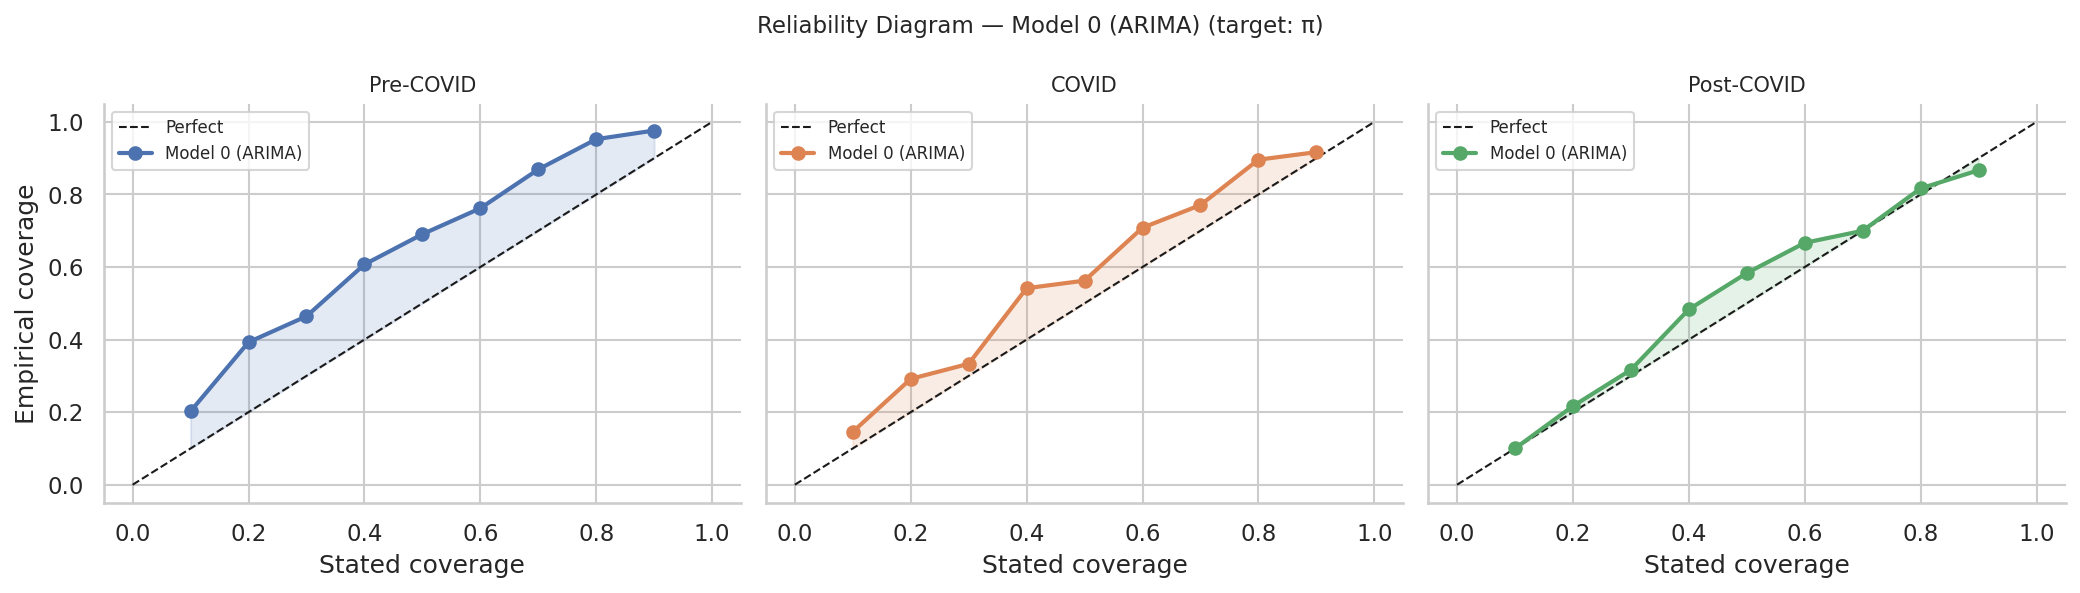

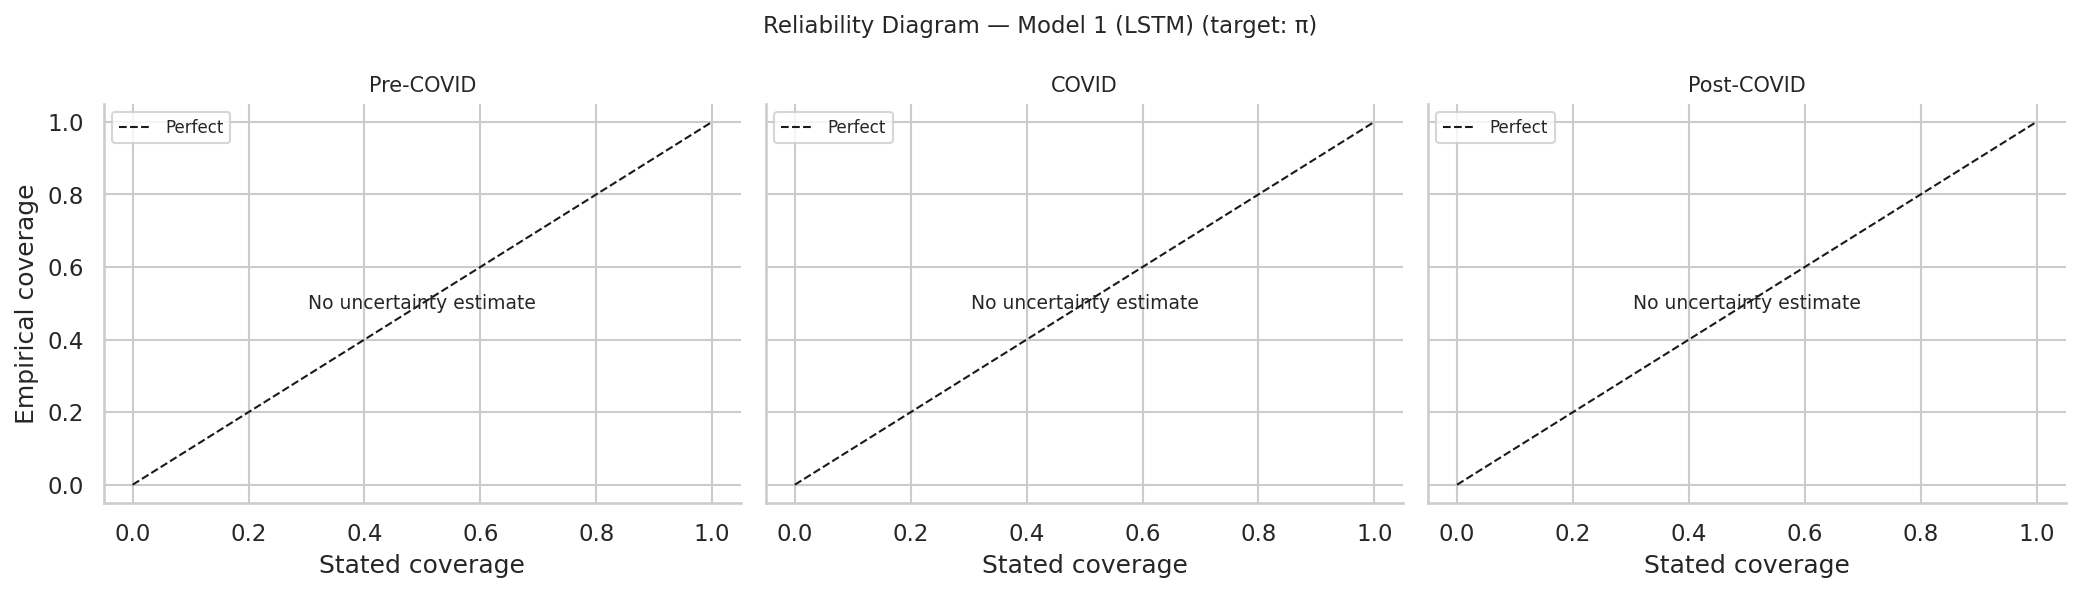

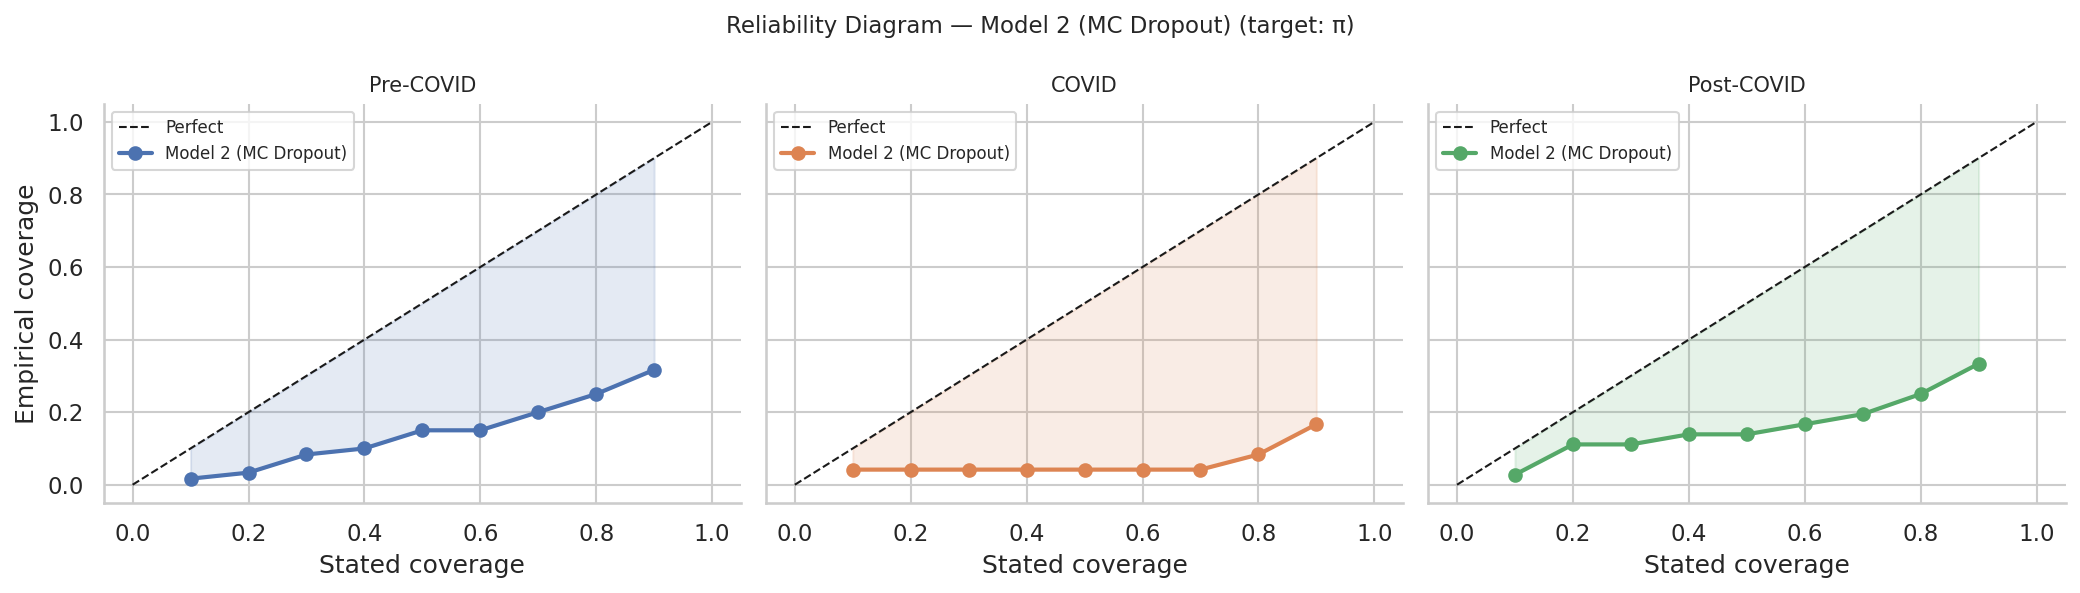

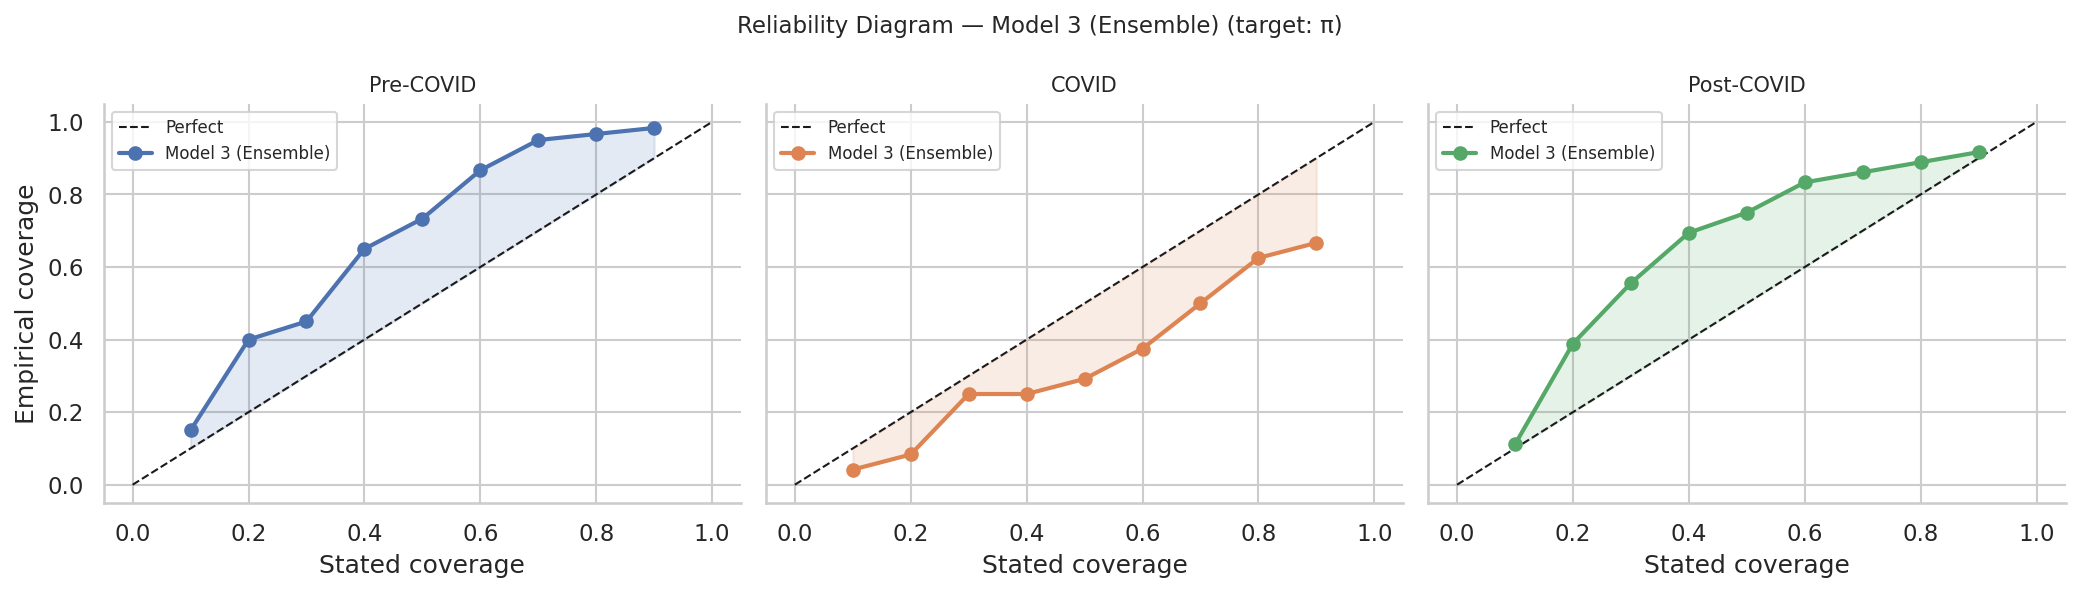

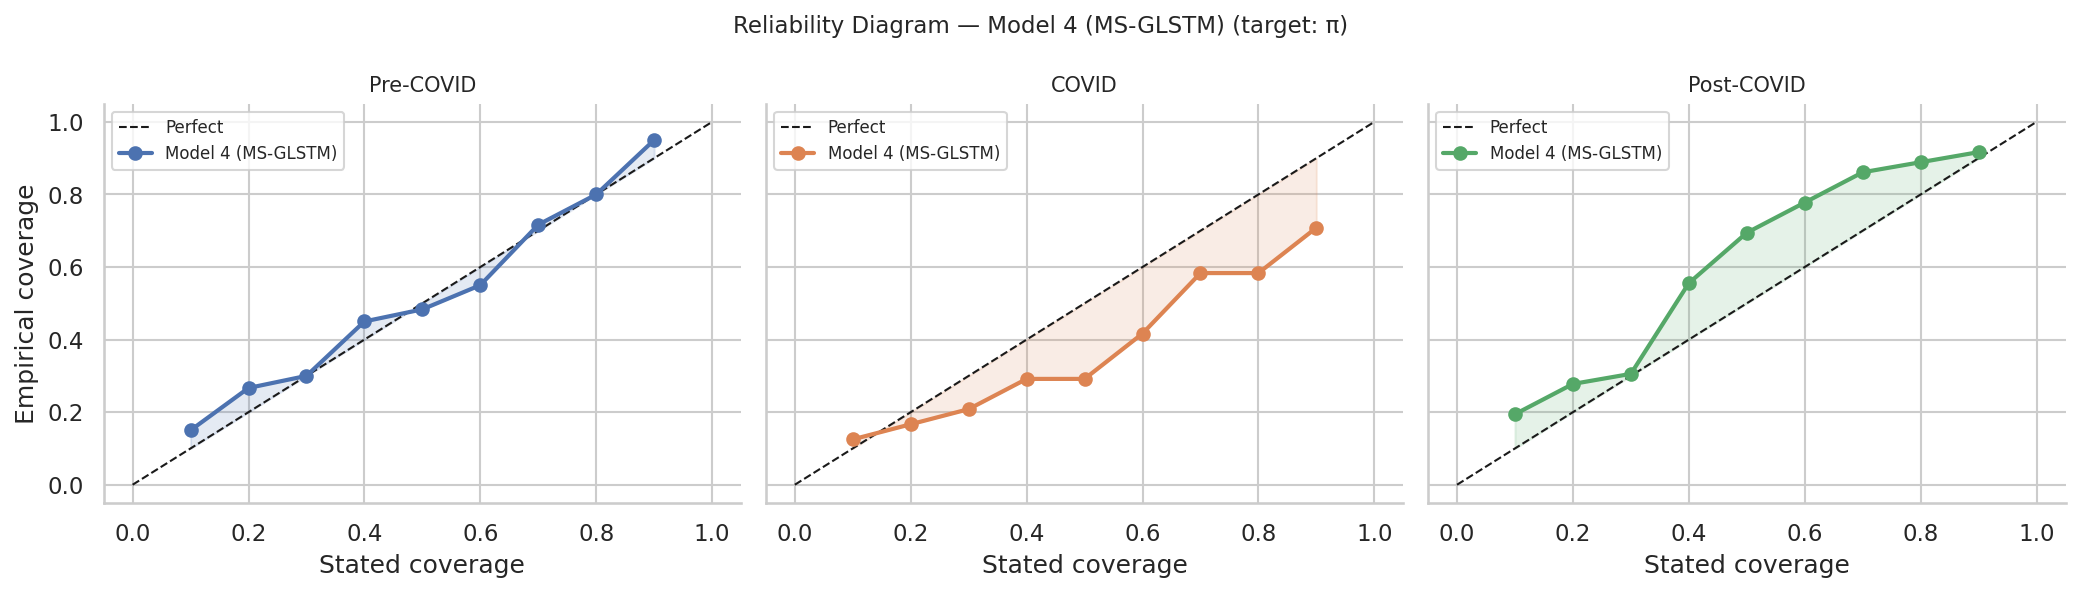

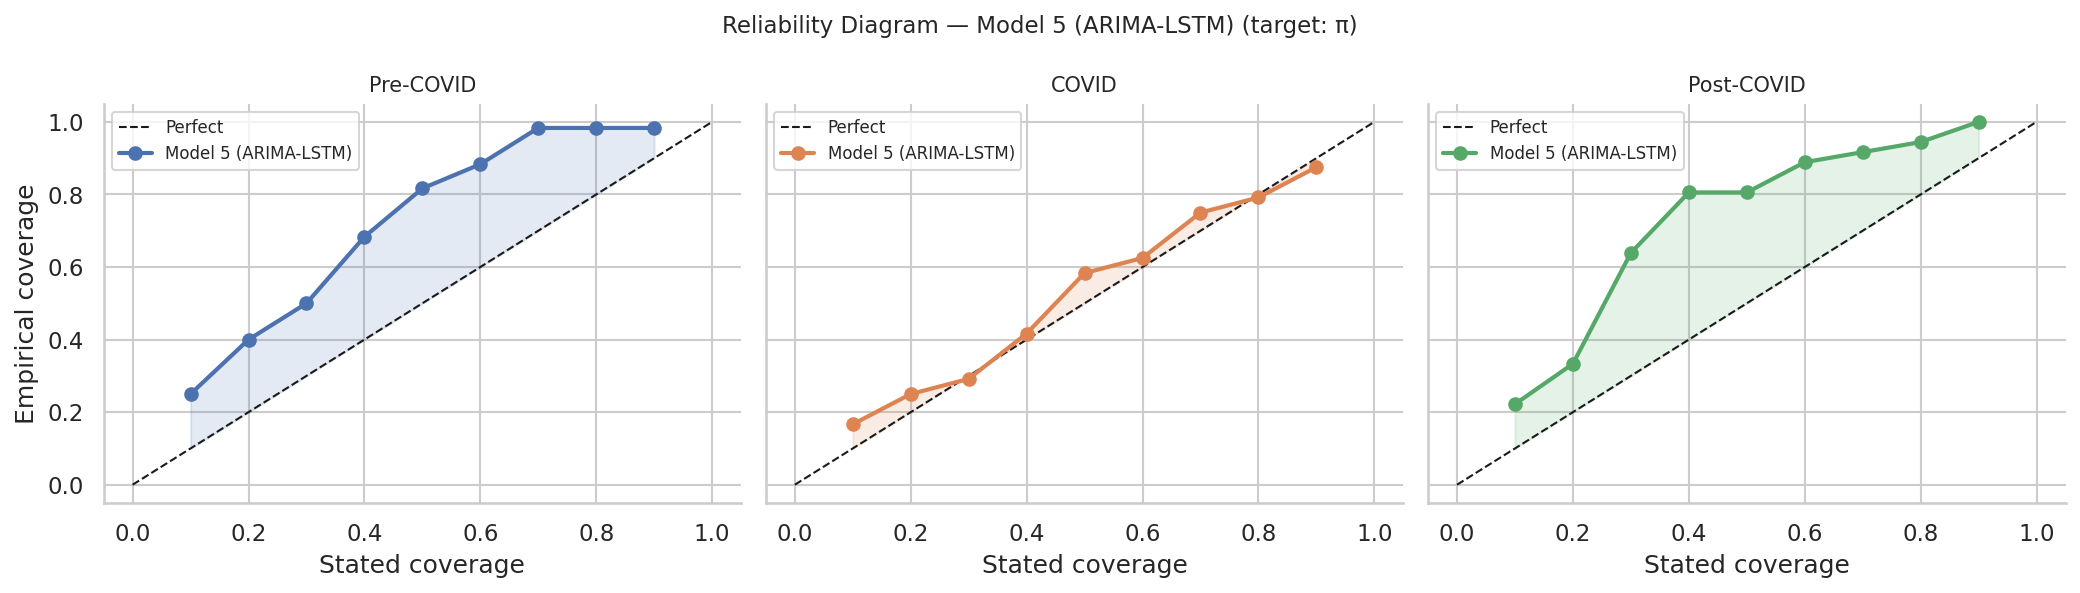

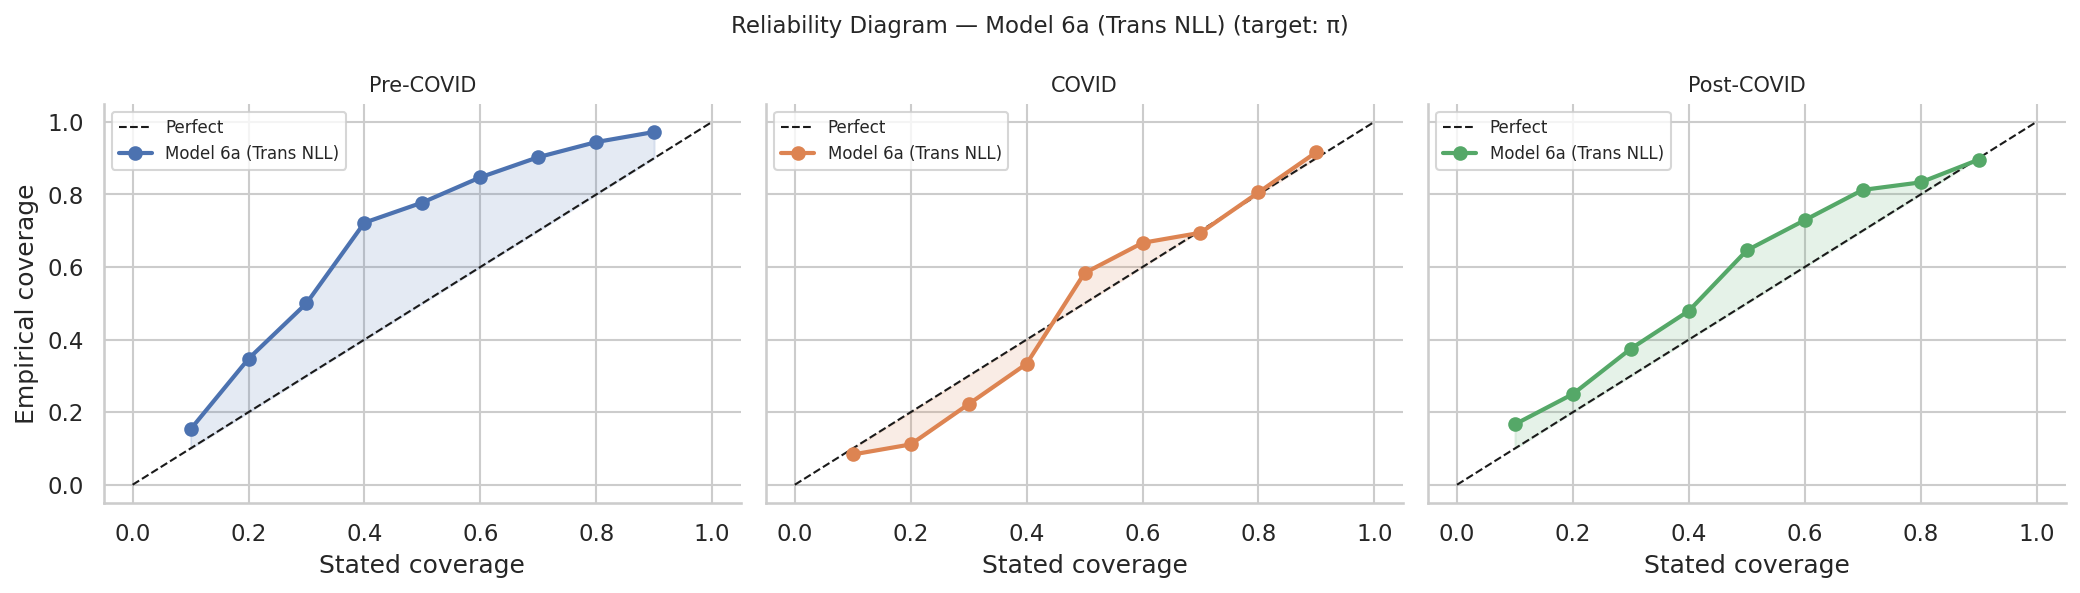

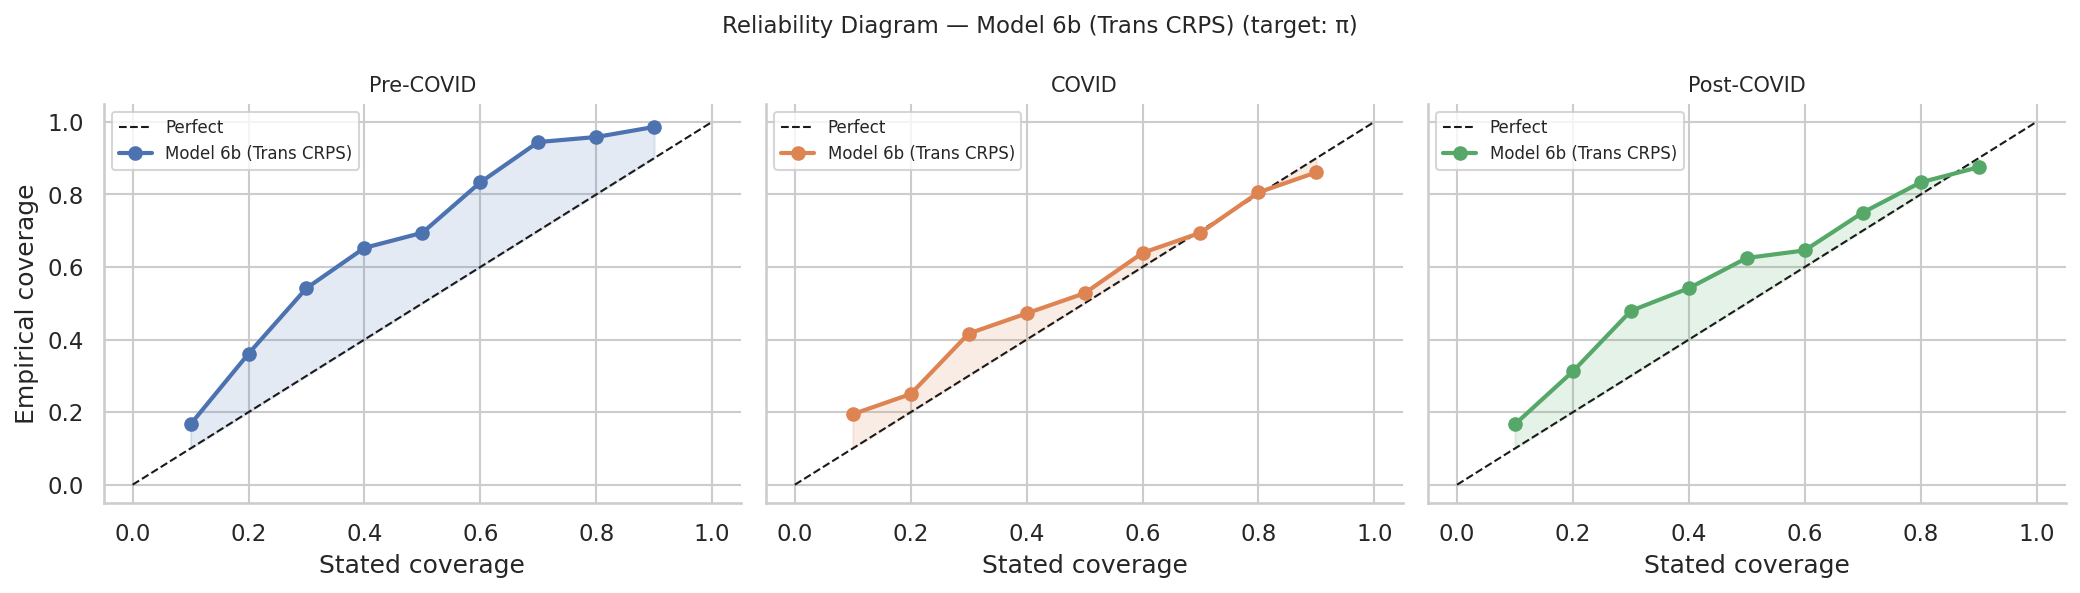

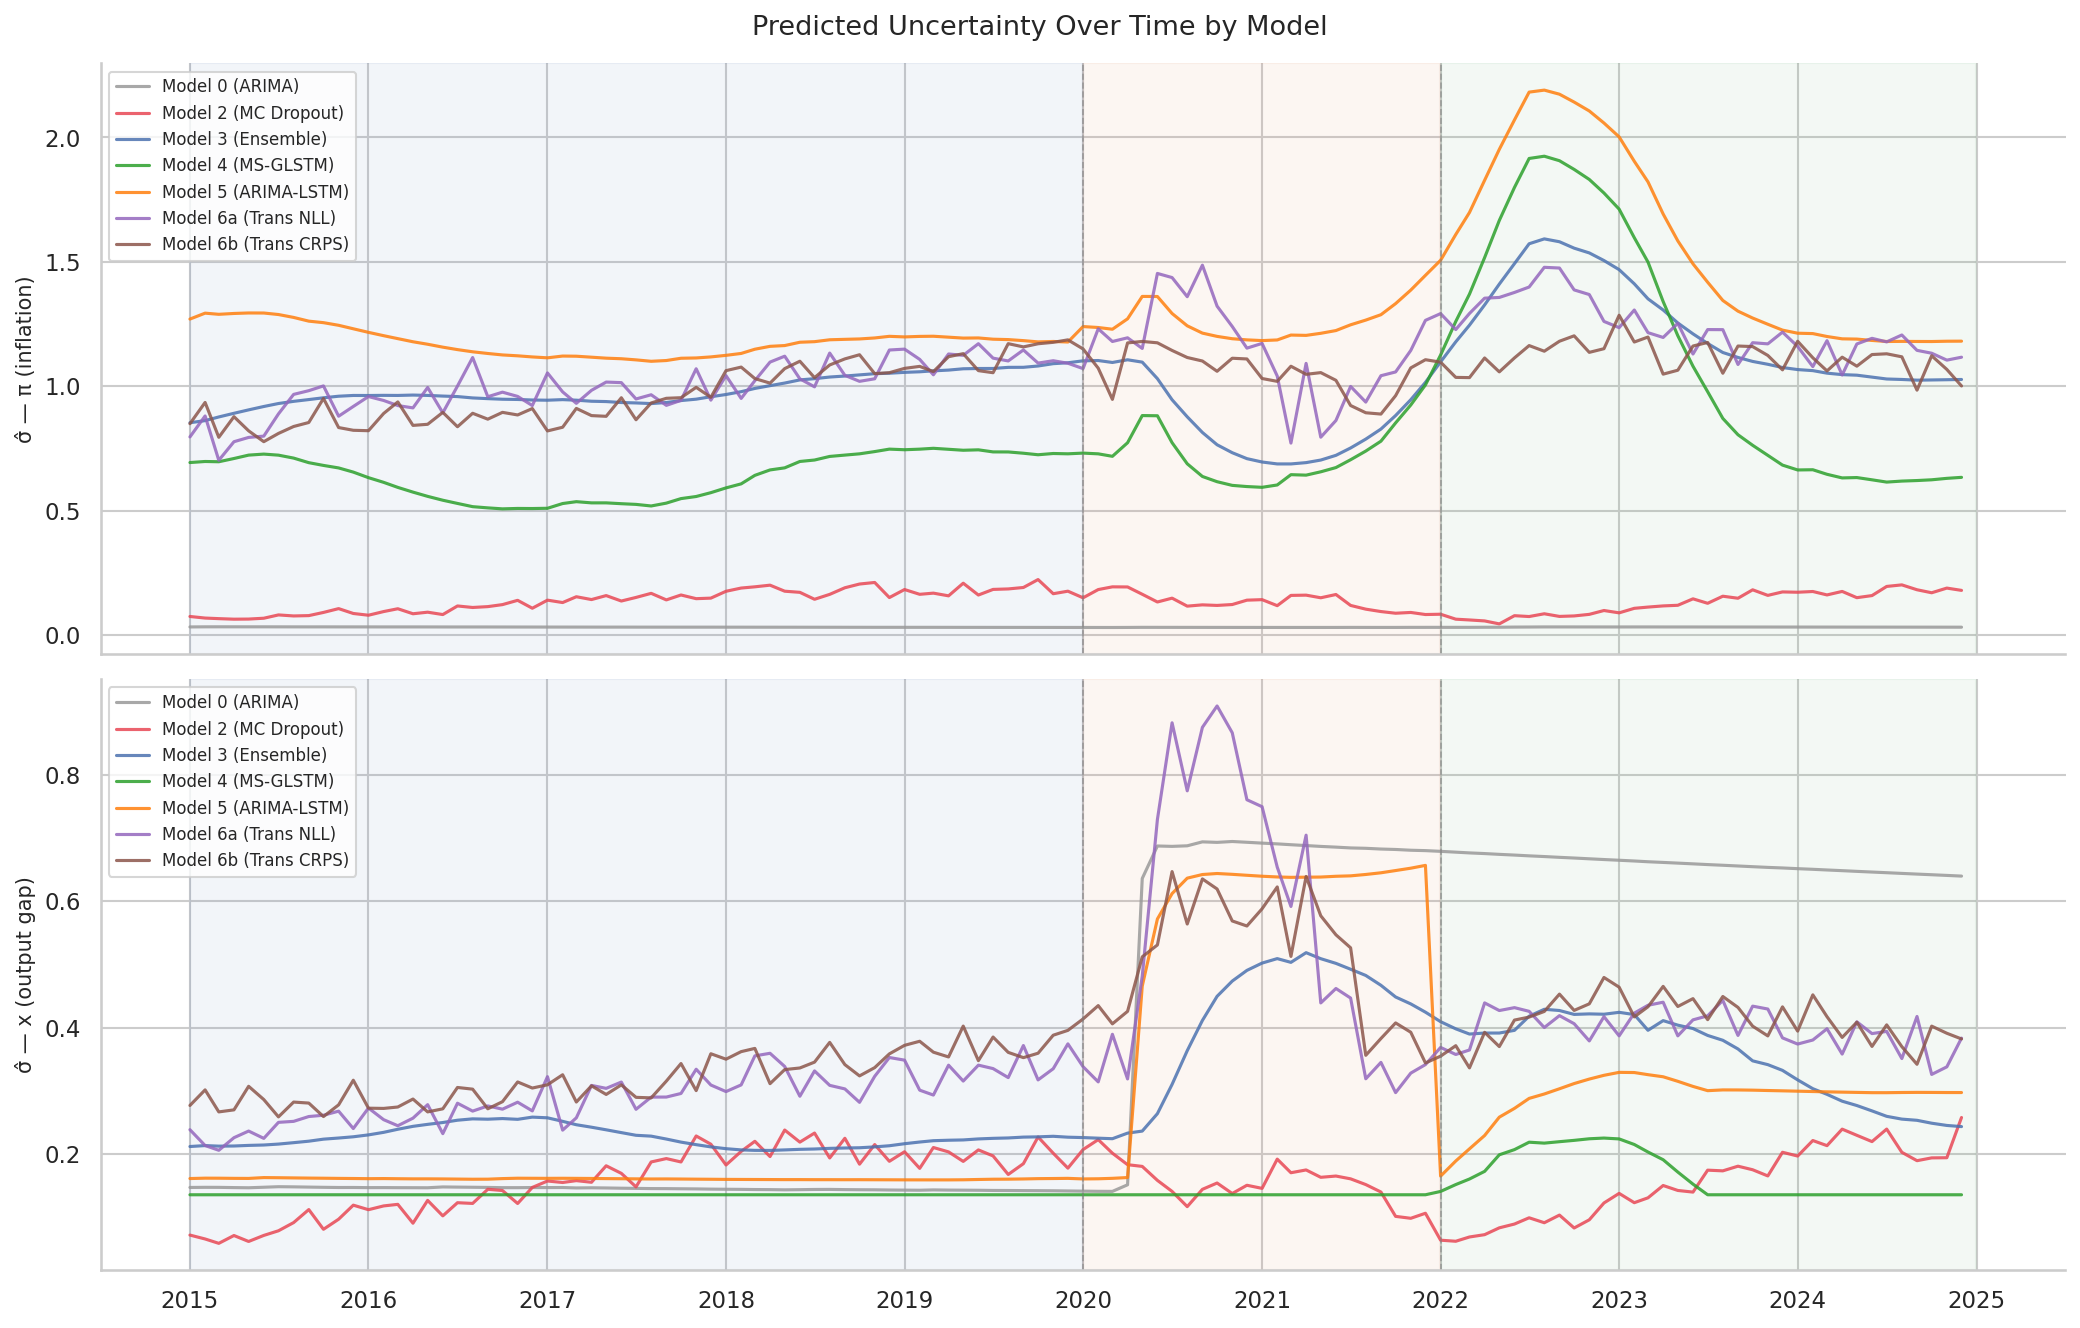


── COVID/Pre σ̂_π ratio (key diagnostic) ──
  Model                       Pre-COVID       COVID  Post-COVID   COVID/Pre
  -----------------------------------------------------------------
  Model 0 (ARIMA)                0.0321      0.0307      0.0313      0.956× ↓
  Model 2 (MC Dropout)           0.1380      0.1354      0.1283      0.981× ↓
  Model 3 (Ensemble)             0.9810      0.8656      1.2290      0.882× ↓
  Model 4 (MS-GLSTM)             0.6412      0.7267      1.1337      1.133× ↑
  Model 5 (ARIMA-LSTM)           1.1809      1.2583      1.5580      1.066× ↑
  Model 6a (Trans NLL)           0.9483      1.1368      1.1813      1.199× ↑
  Model 6b (Trans CRPS)          0.9266      1.0812      1.0892      1.167× ↑

── Ablation Study — σ̂_π per condition ──
         Condition     Regime  ECE_π  CRPS_π  sigma_pi
  A: Monthly + NLL  Pre-COVID 0.2222  0.3916    1.1307
  A: Monthly + NLL      COVID 0.0806  0.8071    1.0983
  A: Monthly + NLL Post-COVID 0.2037  0.5797    1.3935
  

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy import stats as sp_stats

# We define the paths to our google drive to work on a shared environment
PROJECT_DIR  = Path("/content/drive/MyDrive/ST456 Project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
FIGURES_DIR  = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Setup for graphs and constants
TARGET_NAMES  = ["π (inflation)", "x (output gap)"]
TARGET_COLS   = ["pi_mom", "ugap_cf_neg"]
SPLITS        = ["test_pre", "test_covid", "test_post"]
SPLIT_LABELS  = {
    "test_pre":   "Pre-COVID",
    "test_covid": "COVID",
    "test_post":  "Post-COVID",
}

ALPHA_LEVELS  = np.arange(0.1, 1.0, 0.1)

REGIME_COLORS = {
    "test_pre":   "#4C72B0",
    "test_covid": "#DD8452",
    "test_post":  "#55A868",
}

# Load all models predictions
def load_preds(fname):
    """Load a predictions npz and return dict keyed by split."""
    raw = np.load(ARTIFACT_DIR / fname, allow_pickle=True)
    out = {}
    for split in SPLITS:
        out[split] = {
            "mu": raw[f"{split}_mu"],
            "sigma": raw.get(f"{split}_sigma", None),
            "y": raw[f"{split}_y"],
            "dates": pd.to_datetime(raw[f"{split}_dates"]),
        }
    return out

MODEL_FILES = {
    "Model 0 (ARIMA)": "arima_predictions.npz",
    "Model 1 (LSTM)": "lstm_predictions.npz",
    "Model 2 (MC Dropout)": "mc_dropout_predictions.npz",
    "Model 3 (Ensemble)": "ensemble_predictions.npz",
    "Model 4 (MS-GLSTM)": "msglstm_predictions.npz",
    "Model 5 (ARIMA-LSTM)": "arima_lstm_predictions.npz",
    "Model 6a (Trans NLL)":  "transformer_6a_predictions.npz",
    "Model 6b (Trans CRPS)": "transformer_6b_predictions.npz",
}

MODEL_PREDS = {name: load_preds(fname) for name, fname in MODEL_FILES.items()}
print(f"Loaded {len(MODEL_PREDS)} models.")

# Define metric functions (RMSE, MAE, CRPS, ECE, Sharpness)
def rmse(y, mu):
    return float(np.sqrt(np.mean((y - mu) ** 2)))

def mae(y, mu):
    return float(np.mean(np.abs(y - mu)))

def crps_gaussian(y, mu, sigma):
    if sigma is None:
        return np.nan
    sigma = np.maximum(sigma, 1e-6)
    z     = (y - mu) / sigma
    return float(np.mean(
        sigma * (2 * sp_stats.norm.pdf(z) + z * (2 * sp_stats.norm.cdf(z) - 1)
                 - 1 / np.sqrt(np.pi))
    ))

def coverage(y, mu, sigma, alpha):
    z  = sp_stats.norm.ppf(1 - alpha / 2)
    lo, hi = mu - z * sigma, mu + z * sigma
    return float(np.mean((y >= lo) & (y <= hi)))

def ece(y, mu, sigma):
    if sigma is None:
        return np.nan
    return float(np.mean([
        abs((1 - a) - coverage(y, mu, sigma, a))
        for a in ALPHA_LEVELS
    ]))

def sharpness(sigma):
    if sigma is None:
        return np.nan
    return float(np.mean(2 * 1.96 * sigma))

# Compute results table
rows = []
for model_name, preds in MODEL_PREDS.items():
    for split in SPLITS:
        mu    = preds[split]["mu"]
        sigma = preds[split]["sigma"]
        y     = preds[split]["y"]
        for t_idx, t_name in enumerate(TARGET_NAMES):
            mu_t  = mu[:, t_idx]
            y_t   = y[:, t_idx]
            sig_t = sigma[:, t_idx] if sigma is not None else None
            rows.append({
                "Model": model_name,
                "Regime": SPLIT_LABELS[split],
                "Target": t_name,
                "RMSE": round(rmse(y_t, mu_t), 4),
                "MAE": round(mae(y_t, mu_t), 4),
                "CRPS":      round(crps_gaussian(y_t, mu_t, sig_t), 4)
                             if sig_t is not None else None,
                "ECE": round(ece(y_t, mu_t, sig_t), 4),
                "Sharpness": round(sharpness(sig_t), 4)
                             if sig_t is not None else None,
            })

results_df = pd.DataFrame(rows)

# Print ECE & CRPS Summary Tables
print("\n── Inflation target (π) — ECE ──")
print(results_df[results_df["Target"] == "π (inflation)"]
      .pivot_table(index="Model", columns="Regime",
                   values="ECE", aggfunc="first")
      [["Pre-COVID", "COVID", "Post-COVID"]]
      .round(4).to_string())

print("\n── Inflation target (π) — CRPS ──")
print(results_df[results_df["Target"] == "π (inflation)"]
      .pivot_table(index="Model", columns="Regime",
                   values="CRPS", aggfunc="first")
      [["Pre-COVID", "COVID", "Post-COVID"]]
      .round(4).to_string())

print("\n── Output gap (x) — ECE ──")
print(results_df[results_df["Target"] == "x (output gap)"]
      .pivot_table(index="Model", columns="Regime",
                   values="ECE", aggfunc="first")
      [["Pre-COVID", "COVID", "Post-COVID"]]
      .round(4).to_string())

# Reliability diagrams
def plot_reliability(model_name, preds, t_idx=0, t_label="π"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, split in zip(axes, SPLITS):
        mu    = preds[split]["mu"][:, t_idx]
        sigma = preds[split]["sigma"]
        y     = preds[split]["y"][:, t_idx]
        ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
        if sigma is not None:
            sig   = sigma[:, t_idx]
            stated    = [1 - a for a in ALPHA_LEVELS]
            empirical = [coverage(y, mu, sig, a) for a in ALPHA_LEVELS]
            ax.plot(stated, empirical, "o-", lw=2,
                    color=REGIME_COLORS[split], label=model_name)
            ax.fill_between(stated, stated, empirical, alpha=0.15,
                            color=REGIME_COLORS[split])
        else:
            ax.text(0.5, 0.5, "No uncertainty estimate",
                    ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_title(SPLIT_LABELS[split], fontsize=10)
        ax.set_xlabel("Stated coverage")
        if ax == axes[0]:
            ax.set_ylabel("Empirical coverage")
        ax.legend(fontsize=8)
    fig.suptitle(f"Reliability Diagram — {model_name} (target: {t_label})",
                 fontsize=11)
    plt.tight_layout()
    fname = f"reliability_{model_name.split()[0].lower()}_{t_label}.png"
    plt.savefig(FIGURES_DIR / fname, bbox_inches="tight", dpi=120)
    plt.show()

for model_name, preds in MODEL_PREDS.items():
    plot_reliability(model_name, preds, t_idx=0, t_label="π")

# Predicted Uncertainty Over Time
def assemble_sigma_timeline(preds):
    segments = []
    for split, (start, end) in [
        ("test_pre",   ("2015-01-01", "2019-12-31")),
        ("test_covid", ("2020-01-01", "2021-12-31")),
        ("test_post",  ("2022-01-01", "2024-12-31")),
    ]:
        dates = preds[split]["dates"]
        sigma = preds[split]["sigma"]
        if sigma is None:
            continue
        mask = (dates >= start) & (dates <= end)
        segments.append((dates[mask], sigma[mask]))
    if not segments:
        return None, None
    all_dates = np.concatenate([s[0] for s in segments])
    all_sigma = np.concatenate([s[1] for s in segments], axis=0)
    return all_dates, all_sigma

PLOT_MODELS = {
    k: v for k, v in MODEL_PREDS.items()
    if k != "Model 1 (LSTM)"
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
colors = {
    "Model 0 (ARIMA)":       "#999999",
    "Model 2 (MC Dropout)":  "#E84855",
    "Model 3 (Ensemble)":    "#4C72B0",
    "Model 4 (MS-GLSTM)":   "#2ca02c",
    "Model 5 (ARIMA-LSTM)":  "#FF7F0E",
    "Model 6a (Trans NLL)":  "#9467BD",
    "Model 6b (Trans CRPS)": "#8c564b",
}

for t_idx, t_label in enumerate(["π (inflation)", "x (output gap)"]):
    ax = axes[t_idx]
    for model_name, preds in PLOT_MODELS.items():
        dates, sigma = assemble_sigma_timeline(preds)
        if dates is None:
            continue
        ax.plot(dates, sigma[:, t_idx],
                color=colors.get(model_name, "black"),
                lw=1.5, alpha=0.85, label=model_name)
    for split, (start, end) in [
        ("test_pre",   ("2015-01-01", "2019-12-31")),
        ("test_covid", ("2020-01-01", "2021-12-31")),
        ("test_post",  ("2022-01-01", "2024-12-31")),
    ]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.07, color=REGIME_COLORS[split])
    for boundary in ["2020-01-01", "2022-01-01"]:
        ax.axvline(pd.Timestamp(boundary), color="grey",
                   lw=0.8, ls="--", alpha=0.6)
    ax.set_ylabel(f"σ̂ — {t_label}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Predicted Uncertainty Over Time by Model", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sigma_over_time.png", bbox_inches="tight", dpi=120)
plt.show()

# COVID/Pre Ratio Diagnostic Table
print("\n── COVID/Pre σ̂_π ratio (key diagnostic) ──")
print(f"  {'Model':25s}  {'Pre-COVID':>10}  {'COVID':>10}  "
      f"{'Post-COVID':>10}  {'COVID/Pre':>10}")
print("  " + "-" * 65)
for model_name, preds in MODEL_PREDS.items():
    sigma = preds["test_pre"]["sigma"]
    if sigma is None:
        continue
    sigs = {s: preds[s]["sigma"][:, 0].mean() for s in SPLITS}
    ratio = sigs["test_covid"] / max(sigs["test_pre"], 1e-8)
    flag  = "↑" if ratio > 1.0 else "↓"
    print(f"  {model_name:25s}  {sigs['test_pre']:>10.4f}  "
          f"{sigs['test_covid']:>10.4f}  {sigs['test_post']:>10.4f}  "
          f"{ratio:>9.3f}× {flag}")

# Ablation Study Results
print("\n── Ablation Study — σ̂_π per condition ──")
abl_raw = np.load(ARTIFACT_DIR / "ablation_predictions.npz", allow_pickle=True)

abl_rows = []
for cond in ["A", "B", "C"]:
    cond_label = {
        "A": "A: Monthly + NLL",
        "B": "B: Dual + NLL",
        "C": "C: Dual + NLL+CRPS",
    }[cond]
    for split in SPLITS:
        mu_key  = f"{cond}_{split}_mu"
        sig_key = f"{cond}_{split}_sigma"
        y_key   = f"{cond}_{split}_y"
        if mu_key not in abl_raw:
            continue
        mu    = abl_raw[mu_key]
        sigma = abl_raw[sig_key]
        y     = abl_raw[y_key]
        abl_rows.append({
            "Condition": cond_label,
            "Regime":    SPLIT_LABELS[split],
            "ECE_π":     round(ece(y[:, 0], mu[:, 0], sigma[:, 0]), 4),
            "CRPS_π":    round(crps_gaussian(y[:, 0], mu[:, 0], sigma[:, 0]), 4),
            "sigma_pi":  round(sigma[:, 0].mean(), 4),
        })

abl_df = pd.DataFrame(abl_rows)
print(abl_df.to_string(index=False))

# Save full results table
results_df.to_csv(PROJECT_DIR / "results_table.csv", index=False)